In [171]:
#install.packages('caret') # split train-test data
#install.packages('PRROC') # precision-recall curve
#install.packages('Metrics') #Fbeta score
#install.packages("randomForest")
#install.packages('mdatools') # PLS-DA
#install.packages('mixOmics') # PLS-DA
#install.packages("LiblineaR")
#install.packages('e1071') 
#install.packages('tidyverse') 
#install.packages('ROCR')
#install.packages('glmnet')
#install.packages('MASS')
#install.packages('kernlab')
#install.packages('xgboost')
#install.packages('ggplot2')
#install.packages('pROC')
#install.packages('gridExtra')
#install.packages('pdp')
#install.packages('vip')
#install.packages('keras3')
#install.packages('tensorflow')
#install.packages('reticulate')
#install.packages('adabag')
#install.packages('doParallel')
#install.packages('rpart')
#install.packages('liquidSVM')         


In [1]:
library(tidyverse)

Warning message:
"package 'ggplot2' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.0     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data <- read.csv("cardiovascular_disease_data.csv")
head(data)
summary(data)

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
2,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
3,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
4,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
5,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0
6,PID-00006,52,0,159.6,60.3,23.7,134,92,225,155,48,103,0,0,1,1,4,8,0


  Patient_ID             Age            Gender         Height_cm    
 Length:15000       Min.   :25.00   Min.   :0.0000   Min.   :138.5  
 Class :character   1st Qu.:46.00   1st Qu.:0.0000   1st Qu.:158.5  
 Mode  :character   Median :55.00   Median :0.0000   Median :164.7  
                    Mean   :54.54   Mean   :0.4919   Mean   :165.3  
                    3rd Qu.:63.00   3rd Qu.:1.0000   3rd Qu.:172.0  
                    Max.   :85.00   Max.   :1.0000   Max.   :198.1  
   Weight_kg           BMI         Systolic_BP     Diastolic_BP   
 Min.   : 33.70   Min.   :14.50   Min.   : 90.0   Min.   : 60.00  
 1st Qu.: 65.20   1st Qu.:24.50   1st Qu.:127.0   1st Qu.: 85.00  
 Median : 73.90   Median :27.20   Median :135.0   Median : 91.00  
 Mean   : 75.25   Mean   :27.45   Mean   :135.1   Mean   : 90.54  
 3rd Qu.: 83.90   3rd Qu.:30.00   3rd Qu.:143.0   3rd Qu.: 96.00  
 Max.   :150.10   Max.   :46.10   Max.   :182.0   Max.   :120.00  
 Cholesterol_Total Cholesterol_LDL Cholesterol_H

In [3]:
data$Gender = as.factor(data$Gender)
data$Smoking_Status = as.factor(data$Smoking_Status)
data$Alcohol_Consumption = as.factor(data$Alcohol_Consumption)
data$Physical_Activity_Level = as.factor(data$Physical_Activity_Level)
data$Family_History = as.factor(data$Family_History)
data$Sleep_Hours = as.factor(data$Sleep_Hours)
data$Heart_Disease_Risk = as.factor(data$Heart_Disease_Risk)

In [4]:
# change patient ID to index

data = data %>% column_to_rownames(., var="Patient_ID")

In [5]:
summary(data)

      Age        Gender     Height_cm       Weight_kg           BMI       
 Min.   :25.00   0:7622   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1:7378   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00            Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54            Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00            3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00            Max.   :198.1   Max.   :150.10   Max.   :46.10  
                                                                          
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:

# Prepare data

In [6]:
# list of quantitative variable

numeric_cols <- names(data)[sapply(data, is.numeric)]
numeric_cols

[1] "Age"                 "Height_cm"           "Weight_kg"          
 [4] "BMI"                 "Systolic_BP"         "Diastolic_BP"       
 [7] "Cholesterol_Total"   "Cholesterol_LDL"     "Cholesterol_HDL"    
[10] "Fasting_Blood_Sugar" "Stress_Level"

In [7]:
# List of qualitative variables

categorical_cols <- names(data)[sapply(data, is.factor)]
categorical_cols

[1] "Gender"                  "Smoking_Status"         
[3] "Alcohol_Consumption"     "Physical_Activity_Level"
[5] "Family_History"          "Sleep_Hours"            
[7] "Heart_Disease_Risk"

**Important!!!**

We will use the function $\textit{createDataPartition}$ in the package $\textit{caret}$ to create the train data, validation data and test data. Before doing any analysis, we need to rescale the qualitative variables, since they have different scales.

In [8]:
library(caret)

Warning message:
"package 'caret' was built under R version 4.4.3"
Loading required package: lattice


Attaching package: 'caret'


The following object is masked from 'package:purrr':

    lift




In [9]:
#help(createDataPartition)

In [10]:
set.seed(111)
### Create dataset for Heart disease risk
train_id_H <- createDataPartition(data$Heart_Disease_Risk, p = 0.7, list = FALSE)
trainH <- data[train_id_H, ]
testH  <- data[-train_id_H, ]

val_id_H <- createDataPartition(testH$Heart_Disease_Risk, p = 0.5, list = FALSE)
valH <- testH[val_id_H, ]
testH <- testH[-val_id_H, ]
# estimate scaling on training only
preproc <- preProcess(trainH[, numeric_cols], method = c("center", "scale"))

#apply the center and scale on the train and test data
train_scaledH <- predict(preproc, trainH)
test_scaledH  <- predict(preproc, testH)
val_scaledH   <- predict(preproc, valH)

In [11]:
dim(train_scaledH)
dim(test_scaledH)
dim(val_scaledH)

[1] 10500    18

[1] 2250   18

[1] 2250   18

In [12]:
summary(train_scaledH)
summary(test_scaledH)

      Age          Gender     Height_cm          Weight_kg       
 Min.   :-2.4711   0:5314   Min.   :-2.92716   Min.   :-2.58581  
 1st Qu.:-0.7108   1:5186   1st Qu.:-0.74702   1st Qu.:-0.70998  
 Median :-0.0402            Median :-0.07118   Median :-0.09425  
 Mean   : 0.0000            Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.7142            3rd Qu.: 0.73547   3rd Qu.: 0.62172  
 Max.   : 2.5584            Max.   : 3.28622   Max.   : 5.36143  
                                                                 
      BMI            Systolic_BP         Diastolic_BP      Cholesterol_Total 
 Min.   :-2.91549   Min.   :-3.993267   Min.   :-3.61255   Min.   :-3.93633  
 1st Qu.:-0.71615   1st Qu.:-0.628289   1st Qu.:-0.65579   1st Qu.:-0.67437  
 Median :-0.05634   Median :-0.008425   Median : 0.05383   Median : 0.03092  
 Mean   : 0.00000   Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.62789   3rd Qu.: 0.699991   3rd Qu.: 0.64518   3rd Qu.: 0.64804  
 Max

      Age           Gender     Height_cm           Weight_kg       
 Min.   :-2.47113   0:1177   Min.   :-2.927156   Min.   :-2.97243  
 1st Qu.:-0.62698   1:1073   1st Qu.:-0.747023   1st Qu.:-0.72430  
 Median : 0.04362            Median :-0.082082   Median :-0.06919  
 Mean   : 0.03203            Mean   :-0.008248   Mean   : 0.01880  
 3rd Qu.: 0.71422            3rd Qu.: 0.702766   3rd Qu.: 0.66468  
 Max.   : 2.55837            Max.   : 3.569641   Max.   : 4.81013  
                                                                   
      BMI            Systolic_BP        Diastolic_BP      Cholesterol_Total 
 Min.   :-3.15986   Min.   :-3.46196   Min.   :-3.37601   Min.   :-3.23104  
 1st Qu.:-0.66727   1st Qu.:-0.62829   1st Qu.:-0.65579   1st Qu.:-0.71845  
 Median :-0.05634   Median : 0.08013   Median : 0.05383   Median :-0.01316  
 Mean   : 0.02841   Mean   : 0.03849   Mean   : 0.04295   Mean   :-0.01552  
 3rd Qu.: 0.65233   3rd Qu.: 0.69999   3rd Qu.: 0.76345   3rd Qu.: 0.64

# Heart disease risk

To compare the efficiency of each method, we use the **F1-score** as the main metric, which balances precision and recall. Accuracy alone is insufficient in a medical context: classifying a at-risk patient as healthy (false negative) is far more costly than the opposite.

To maximize F1 score, there are several approaches : 
- For CV, use F1 score as the metric to evaluate the model
- Change the class weight, which is not always possible
- Choose threshold for the probability on the validation set

Those methods will be performed at the same time if possible in order to have the best model. For the choice of threshold, this step must be performed on the validation. If we do this on the training, the threshold is overly optimistic since the models are trained on the same data. On the contrary, we must not perform anything on the test set execpt the last step, when we evaluate the models. Hence, in this section the validation set is necessary for our approach.

In [13]:
# Table containing the performance of the different models

tab_mod <- data.frame(
  Name = character(),
  Precision = numeric(),
  Recall = numeric(),
  F1 = numeric(),
  Accuracy = numeric(),
  stringsAsFactors = FALSE
)

tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>


In [23]:
calculate_threshold <- function (val, val_prob){
    thresholds <- seq(0.1, 0.7, length.out = 50)
    score <- 0
    p <- 0.5
    for (t in thresholds) {
        val_pred <- val_prob >= t
        score_t <- fbeta_score(val,val_pred, beta=1)
        if (score_t > score) {
            score <- score_t
            p <- t
        }
    }
    return(p)
}

## Logistic regression

Logistic regression is our baseline model. It gives us much valuable information, such as the importance of features or odd ratios.

### Training

In [15]:
res.log = glm(Heart_Disease_Risk~., family="binomial", data=train_scaledH)

In [16]:
summary(res.log)


Call:
glm(formula = Heart_Disease_Risk ~ ., family = "binomial", data = train_scaledH)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.15739    0.12118  -1.299 0.194007    
Age                       0.24398    0.02840   8.590  < 2e-16 ***
Gender1                  -0.07469    0.06948  -1.075 0.282345    
Height_cm                -0.07209    0.15733  -0.458 0.646803    
Weight_kg                 0.17257    0.25521   0.676 0.498933    
BMI                       0.04519    0.20682   0.219 0.827030    
Systolic_BP               0.33471    0.04129   8.106 5.22e-16 ***
Diastolic_BP             -0.01541    0.03929  -0.392 0.694827    
Cholesterol_Total        -0.03610    0.04332  -0.833 0.404679    
Cholesterol_LDL           0.22535    0.04168   5.407 6.41e-08 ***
Cholesterol_HDL          -0.05691    0.02761  -2.061 0.039284 *  
Fasting_Blood_Sugar       0.31601    0.02436  12.974  < 2e-16 ***
Smoking_Status1           1.92768    0.

**Comment** : We can observe the significance of the parameters. It seems that the risk of having heart disease depends on :
- Age
- Systolic BP
- Cholesterol_LDL
- Fasting blood sugar
- Smoking status *
- Physical activity level *
- Family history *
- Stress level
- Sleep hours

This result is coherent with the exploratory analysis.

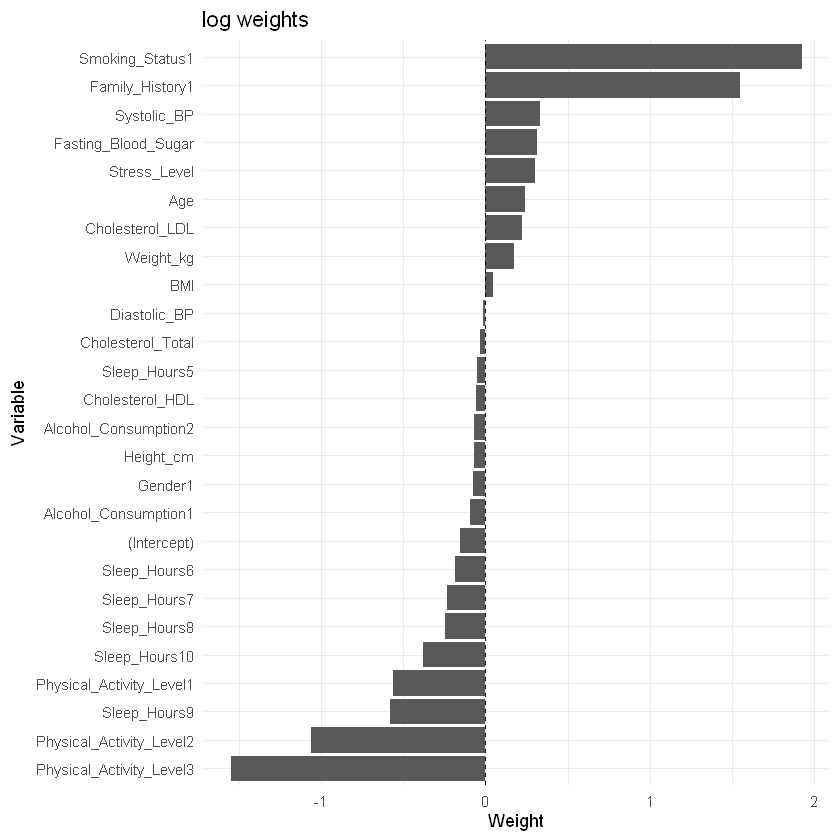

In [17]:
df = data.frame(res.log$coefficients)
colnames(df) = 'Weight'
df$Variable = rownames(df)
ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "log weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

In [18]:
library(PRROC)
library(Metrics)

Warning message:
"package 'PRROC' was built under R version 4.4.3"
Loading required package: rlang


Attaching package: 'rlang'


The following objects are masked from 'package:purrr':

    %@%, flatten, flatten_chr, flatten_dbl, flatten_int, flatten_lgl,
    flatten_raw, invoke, splice


Warning message:
"package 'Metrics' was built under R version 4.4.3"

Attaching package: 'Metrics'


The following object is masked from 'package:rlang':

    ll


The following objects are masked from 'package:caret':

    precision, recall




         actual
predicted    0    1
    FALSE 1044  349
    TRUE   225  632

Recall:  0.6442406 
Precision:  0.7374562 
F1 Score:  0.687704

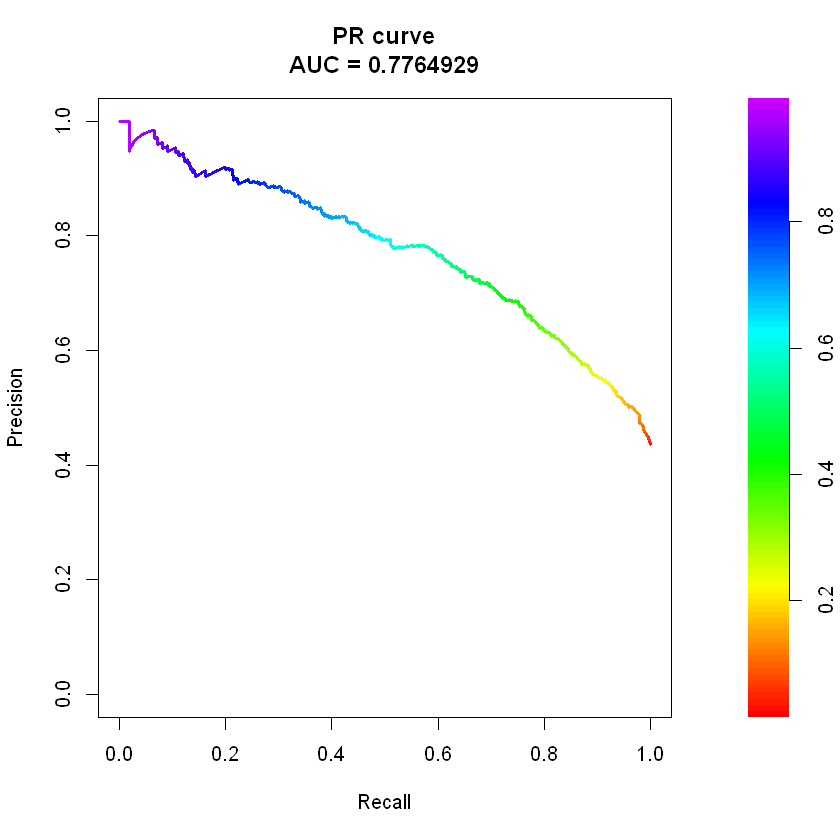

In [19]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
table(predicted = pred.log > 0.5, actual = test_scaledH[, "Heart_Disease_Risk"])
y_true <- as.numeric(as.character(test_scaledH[, "Heart_Disease_Risk"]))

#Recall
cat("Recall: ", sum(pred.log >0.5 & y_true == 1)/sum(y_true == 1), "\n")

#Precision
cat("Precision: ", sum(pred.log >0.5 & y_true == 1)/sum(pred.log >0.5), "\n")

#Fb score
cat("F1 Score: ", fbeta_score(y_true, pred.log >0.5, beta = 1) )

#Plot the precision recall curve

plot(pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
))

### Choose threshold value

The threshold value for probability is chosen to maximize F1 score

In [25]:
y_val_prob = predict(res.log, newdata = val_scaledH, type = "response")
y_val = as.numeric(as.character(val_scaledH[, "Heart_Disease_Risk"]))
p_log <- calculate_threshold(y_val, y_val_prob)
p_log

[1] 0.3326531

In [26]:
#Recall
cat('Recall : ',sum(pred.log >p_log & y_true == 1)/sum(y_true == 1))

#Precision
cat('\nPrecision : ', sum(pred.log >p_log & y_true == 1)/sum(pred.log >p_log))

#Fbeta score
cat('\nF1 score : ', fbeta_score(y_true, pred.log >p_log, beta = 1))

table(predicted = pred.log > p_log, actual = test_scaledH[, "Heart_Disease_Risk"])

Recall :  0.8124363
Precision :  0.6270653
F1 score :  0.7078153

         actual
predicted   0   1
    FALSE 795 184
    TRUE  474 797

In [27]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "Logistic regression",
    Precision = sum(pred.log >p_log & y_true)/sum(pred.log >p_log),
    Recall = sum(pred.log >p_log & y_true)/sum(y_true),
    F1 = fbeta_score(y_true, pred.log >p_log, beta = 1),
    Accuracy = (sum(pred.log >p_log & y_true) + sum(pred.log <p_log & !y_true))/length(y_true)
  )
)

In [28]:
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556


## Logistic regression - AIC

We observe that certain variables do not explain well the Heart Disease Risk, which inspire us to perform variable selection. To do so, we perform logistic regression with AIC and the method is backward.

### Training

In [29]:
res.log.aic = step(res.log, direction='backward')

Start:  AIC=11136.11
Heart_Disease_Risk ~ Age + Gender + Height_cm + Weight_kg + BMI + 
    Systolic_BP + Diastolic_BP + Cholesterol_Total + Cholesterol_LDL + 
    Cholesterol_HDL + Fasting_Blood_Sugar + Smoking_Status + 
    Alcohol_Consumption + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours

                          Df Deviance   AIC
- BMI                      1    11084 11134
- Diastolic_BP             1    11084 11134
- Height_cm                1    11084 11134
- Weight_kg                1    11085 11135
- Cholesterol_Total        1    11085 11135
- Gender                   1    11085 11135
- Alcohol_Consumption      2    11088 11136
<none>                          11084 11136
- Cholesterol_HDL          1    11088 11138
- Sleep_Hours              6    11105 11145
- Cholesterol_LDL          1    11114 11164
- Systolic_BP              1    11150 11200
- Age                      1    11159 11209
- Stress_Level             1    11253 11303
- Fasting_Blood_

**Comment:** 12 variables are used in the logistic AIC model

         actual
predicted    0    1
    FALSE 1047  353
    TRUE   222  628

Recall 0.6401631
Precision 0.7388235
F1 score 0.685964

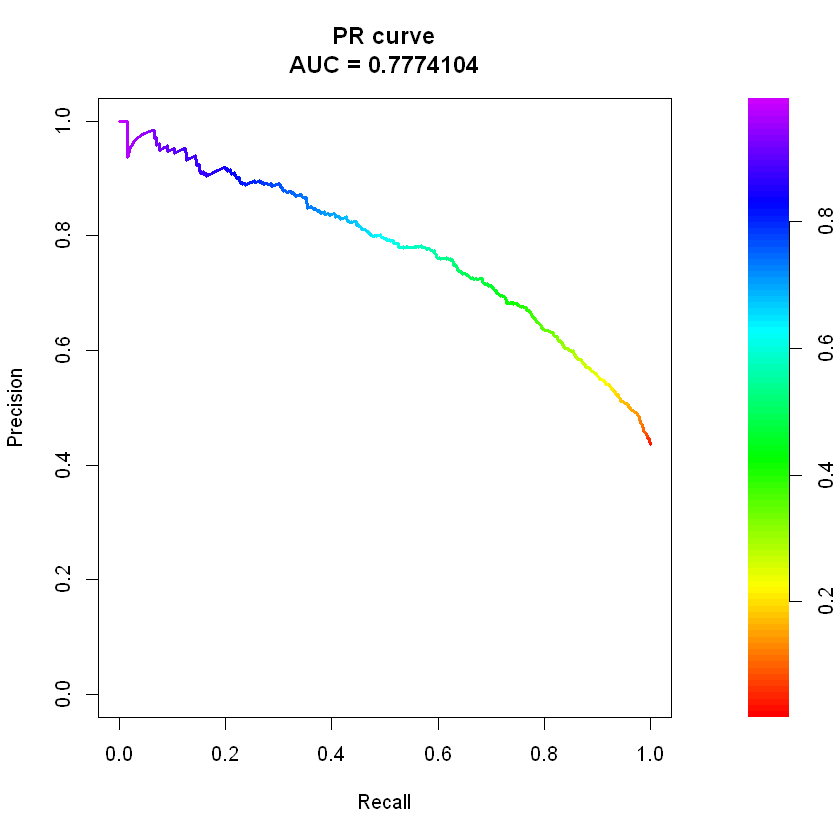

In [30]:
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
# Matrice de confusion pour la prévision du 
# dépassement de seuil
table(predicted = pred.log.aic > 0.5, actual = test_scaledH[, "Heart_Disease_Risk"])

#Recall
cat('Recall',sum(pred.log.aic >0.5 & y_true)/sum(y_true))

#Precision
cat('\nPrecision',sum(pred.log.aic >0.5 & y_true)/sum(pred.log.aic >0.5))

#F beta score
cat('\nF1 score',fbeta_score(y_true, pred.log.aic >0.5, beta = 1))

plot(pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
))

In [31]:

y_val_prob_aic = predict(res.log.aic, newdata = val_scaledH, type = "response")
p_aic <- calculate_threshold(y_val, y_val_prob_aic)
#Recall
cat('Recall',sum(pred.log.aic >p_aic & y_true)/sum(y_true))

#Precision
cat('\nPrecision',sum(pred.log.aic >p_aic & y_true)/sum(pred.log.aic >p_aic))

#F beta score
cat('\nF1 score',fbeta_score(y_true, pred.log.aic >p_aic, beta = 1))

table(predicted = pred.log.aic > p_aic, actual = test_scaledH[, "Heart_Disease_Risk"])


Recall 0.8185525


Precision 0.6258769
F1 score 0.709364

         actual
predicted   0   1
    FALSE 789 178
    TRUE  480 803

In [32]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "Logistic regression AIC",
    Precision = sum(pred.log.aic >p_aic & y_true)/sum(pred.log.aic >p_aic),
    Recall = sum(pred.log.aic >p_aic & y_true)/sum(y_true),
    F1 = fbeta_score(y_true, pred.log.aic >p_aic, beta = 1),
    Accuracy = (sum(pred.log.aic >p_aic & y_true) + sum(pred.log.aic <p_aic & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556


### Interpretation

In [33]:
summary(res.log.aic)


Call:
glm(formula = Heart_Disease_Risk ~ Age + Height_cm + Weight_kg + 
    Systolic_BP + Cholesterol_LDL + Cholesterol_HDL + Fasting_Blood_Sugar + 
    Smoking_Status + Physical_Activity_Level + Family_History + 
    Stress_Level + Sleep_Hours, family = "binomial", data = train_scaledH)

Coefficients:
                         Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -0.23266    0.11487  -2.025 0.042821 *  
Age                       0.23784    0.02756   8.629  < 2e-16 ***
Height_cm                -0.12817    0.02944  -4.354 1.34e-05 ***
Weight_kg                 0.22815    0.03221   7.084 1.41e-12 ***
Systolic_BP               0.32266    0.02649  12.181  < 2e-16 ***
Cholesterol_LDL           0.19780    0.02556   7.737 1.02e-14 ***
Cholesterol_HDL          -0.04742    0.02606  -1.820 0.068774 .  
Fasting_Blood_Sugar       0.31626    0.02435  12.989  < 2e-16 ***
Smoking_Status1           1.92851    0.05328  36.194  < 2e-16 ***
Physical_Activity_Level1 -0.56199  

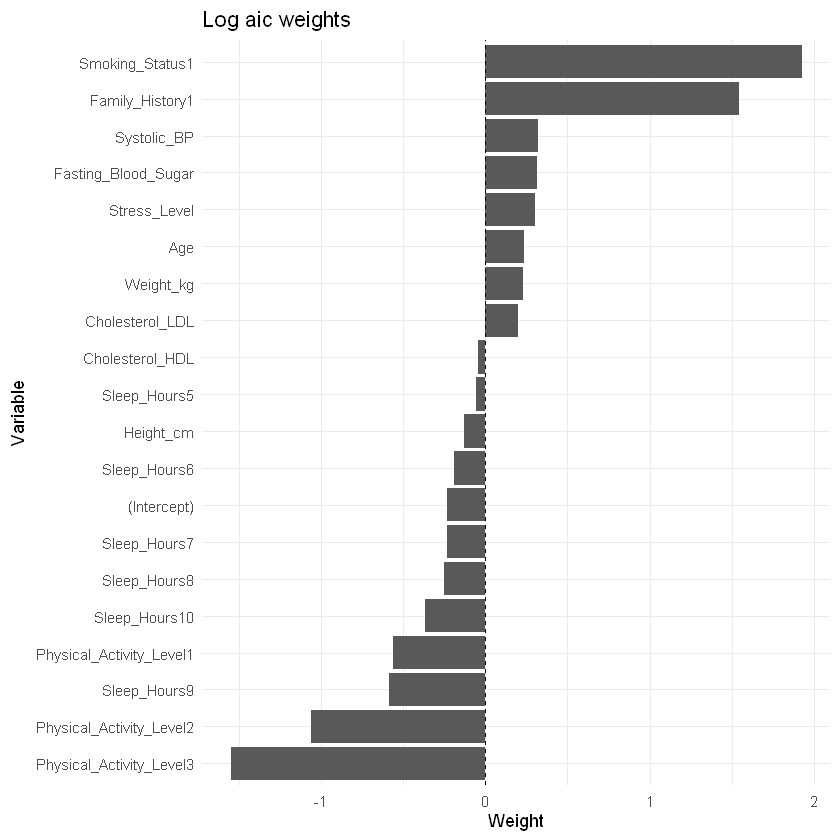

In [34]:
df = data.frame(res.log.aic$coefficients)
colnames(df) = 'Weight'
df$Variable = rownames(df)
ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Log aic weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

In [35]:
# Test of sub model : verify if the submodel is efficient enough

anova(res.log.aic, res.log, test = "Chisq")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,10480,11089.83,NA,NA,NA
2,10474,11084.11,6,5.715347,0.4558202


**Comment:** According to the submodel test, we conclude that we can replace the complete model by submodel.

In [36]:
# Odd ratio

as.table(exp(res.log.aic$coefficients))

             (Intercept)                      Age                Height_cm 
               0.7924198                1.2685075                0.8797068 
               Weight_kg              Systolic_BP          Cholesterol_LDL 
               1.2562688                1.3807994                1.2187126 
         Cholesterol_HDL      Fasting_Blood_Sugar          Smoking_Status1 
               0.9536876                1.3719869                6.8792299 
Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3 
               0.5700721                0.3453820                0.2119031 
         Family_History1             Stress_Level             Sleep_Hours5 
               4.7008897                1.3531253                0.9466409 
            Sleep_Hours6             Sleep_Hours7             Sleep_Hours8 
               0.8269939                0.7896816                0.7765131 
            Sleep_Hours9            Sleep_Hours10 
               0.5569199             

**Comments:**
- A smoking person can have about 7 times higher risk of having cardiovascular diseases compared to non-smoking person.
- For a person which family history had a heart disease patient, the odds of having the disease is about 4 times higher than those not having any in the family history.
- The stress level increases the risk, while the sleep hour reduces it.
- Physical acctivity level can reduce the risk at least twice compare to the patient without practicing physical activities.

In [37]:
library(ROCR)

Warning message:
"package 'ROCR' was built under R version 4.4.3"


## LDA

In [38]:
library(glmnet)
library(MASS)

Warning message:
"package 'glmnet' was built under R version 4.4.3"
Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10

Warning message:
"package 'MASS' was built under R version 4.4.3"

Attaching package: 'MASS'


The following object is masked from 'package:dplyr':

    select




In [39]:
res.lda <- lda(Heart_Disease_Risk~., data=train_scaledH)
res.lda

Call:
lda(Heart_Disease_Risk ~ ., data = train_scaledH)

Prior probabilities of groups:
    0     1 
0.564 0.436 

Group means:
         Age   Gender1    Height_cm   Weight_kg        BMI Systolic_BP
0 -0.1502581 0.4945964 -0.005315335 -0.09502567 -0.1139426  -0.1691705
1  0.1943706 0.4930100  0.006875800  0.12292312  0.1473936   0.2188353
  Diastolic_BP Cholesterol_Total Cholesterol_LDL Cholesterol_HDL
0   -0.1342802        -0.1249743      -0.1294569      0.05298394
1    0.1737018         0.1616640       0.1674625     -0.06853886
  Fasting_Blood_Sugar Smoking_Status1 Alcohol_Consumption1 Alcohol_Consumption2
0          -0.1441222       0.1634583            0.4044242            0.1035123
1           0.1864334       0.4799039            0.3866317            0.1041940
  Physical_Activity_Level1 Physical_Activity_Level2 Physical_Activity_Level3
0                0.3873691                0.3321513               0.12597096
1                0.4211446                0.2483617               0.06

In [40]:
pred.lda <- predict(res.lda, test_scaledH)
table(predicted = pred.lda$class, actual = y_true)

# Recall
cat('Recall: ', sum(pred.lda$class == 1 & y_true == 1)/sum(y_true == 1))

#Precision
cat('\nPrecision: ', sum(pred.lda$class == 1 & y_true == 1)/sum(pred.lda$class == 1))

#F beta score
cat('\nF1 Score: ', fbeta_score(y_true, pred.lda$class ==1, beta = 1))

         actual
predicted    0    1
        0 1053  356
        1  216  625

Recall:  0.637105
Precision:  0.7431629
F1 Score:  0.6860593

In [41]:
p_lda <- calculate_threshold(y_val, predict(res.lda, val_scaledH)$posterior[,2])
#Recall
cat('Recall : ',sum(pred.lda$posterior[,2] >p_lda & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred.lda$posterior[,2] >p_lda &y_true)/sum(pred.lda$posterior[,2] >p_lda))

#F beta score
cat('\nF1 score : ',fbeta_score(y_true, pred.lda$posterior[,2] >p_lda, beta = 1))

table(predicted = pred.lda$posterior[,2] > p_lda, actual = test_scaledH[, "Heart_Disease_Risk"])

Recall :  0.7900102
Precision :  0.6415563
F1 score :  0.7080859

         actual
predicted   0   1
    FALSE 836 206
    TRUE  433 775

In [42]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "LDA",
    Precision = sum(pred.lda$posterior[,2] >p_lda & y_true)/sum(pred.lda$posterior[,2] >p_lda),
    Recall = sum(pred.lda$posterior[,2] >p_lda & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,pred.lda$posterior[,2] >p_lda, beta = 1),
    Accuracy = (sum(pred.lda$posterior[,2] >p_lda & y_true) + sum(pred.lda$posterior[,2] <p_lda & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000


## PLS - DA

This is the classification version of the Partial Least Square model, which identifies the features closely correlated to the target, then uses them to predict the target. Since the Heart disease risk is highly correlated to certain variables such as Smoking status or Family history, this method shows a huge potential.

The hyperparameter `ncomp` (number of components) will be optimized using validation set.

In [43]:
library(mdatools)

Warning message:
"package 'mdatools' was built under R version 4.4.3"
Registered S3 methods overwritten by 'mdatools':
  method        from 
  predict.plsda caret
  print.plsda   caret


Attaching package: 'mdatools'


The following object is masked from 'package:caret':

    plsda




In [44]:
X <- model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1]
y <- train_scaledH$Heart_Disease_Risk
res.plsda = plsda(X,y, ncomp=10, )

Warning message in selectCompNum.pls(model, selcrit = ncomp.selcrit):
"No validation results were found."


In [45]:
summary(res.plsda)


PLS-DA model (class plsda) summary
------------------------------------
Info: 
Number of selected components: 10
Cross-validation: none

Class #1 (0)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.51       27.45 4821 1662 2916 1101 0.637 0.814    0.737

Class #2 (1)
    X cumexpvar Y cumexpvar   TP   FP   TN   FN Spec. Sens. Accuracy
Cal       78.51       27.45 2916 1101 4821 1662 0.814 0.637    0.737



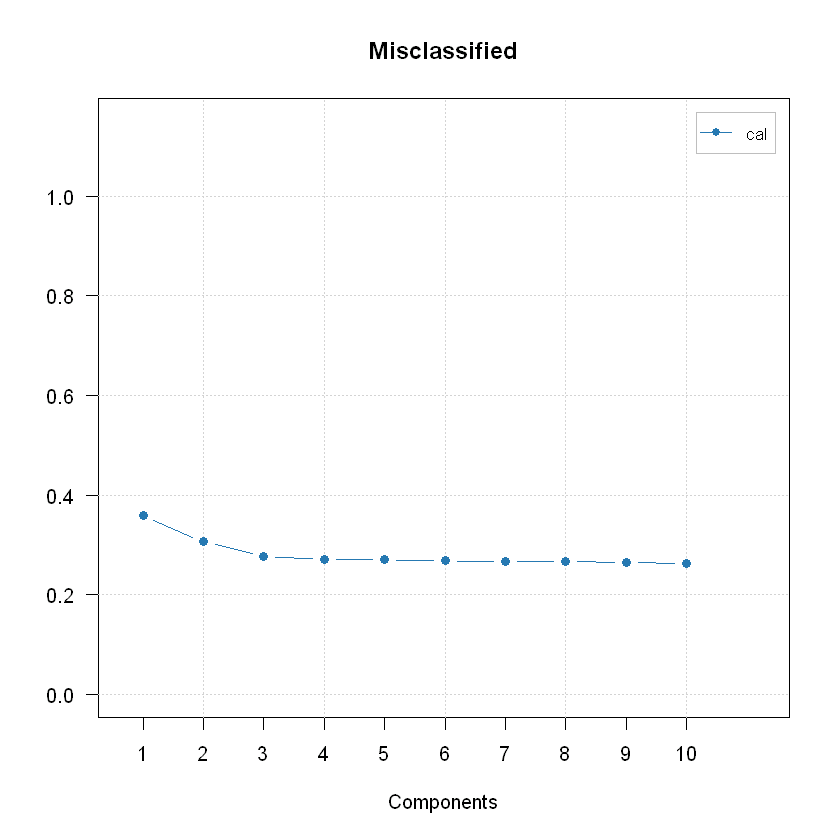

In [46]:
plotMisclassified(res.plsda)

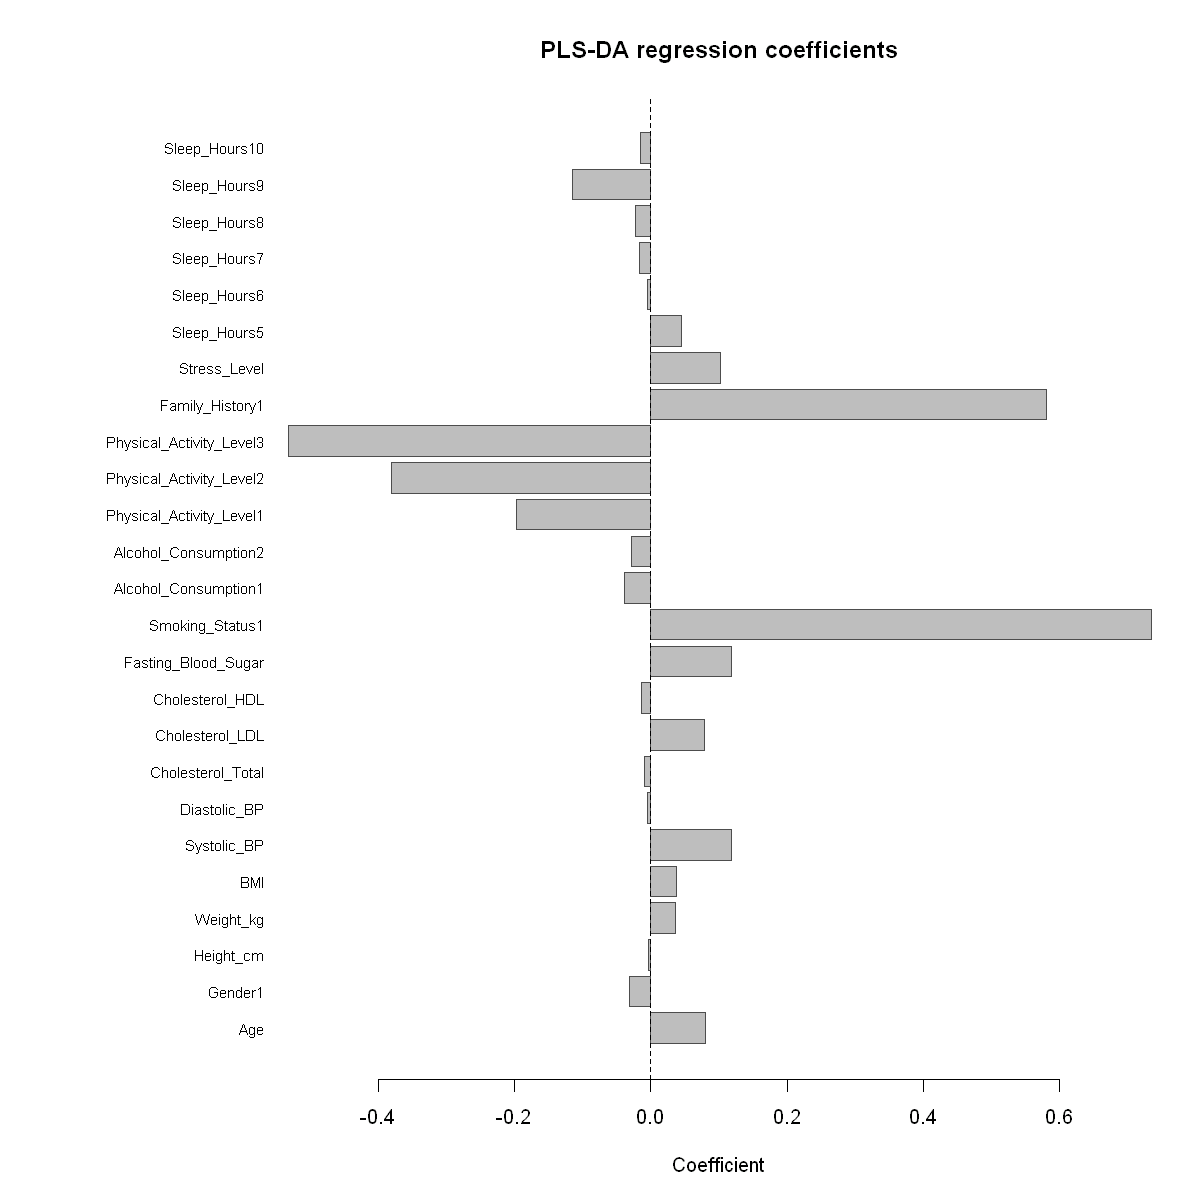

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

par(mar = c(5, 12, 4, 2))

df <- res.plsda$coeffs$values
df <- data.frame(as.numeric(df[,10,2]))
colnames(df) = 'Weight'
df$Variable <- colnames(model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1])
g3 <- ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "PLS-DA weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

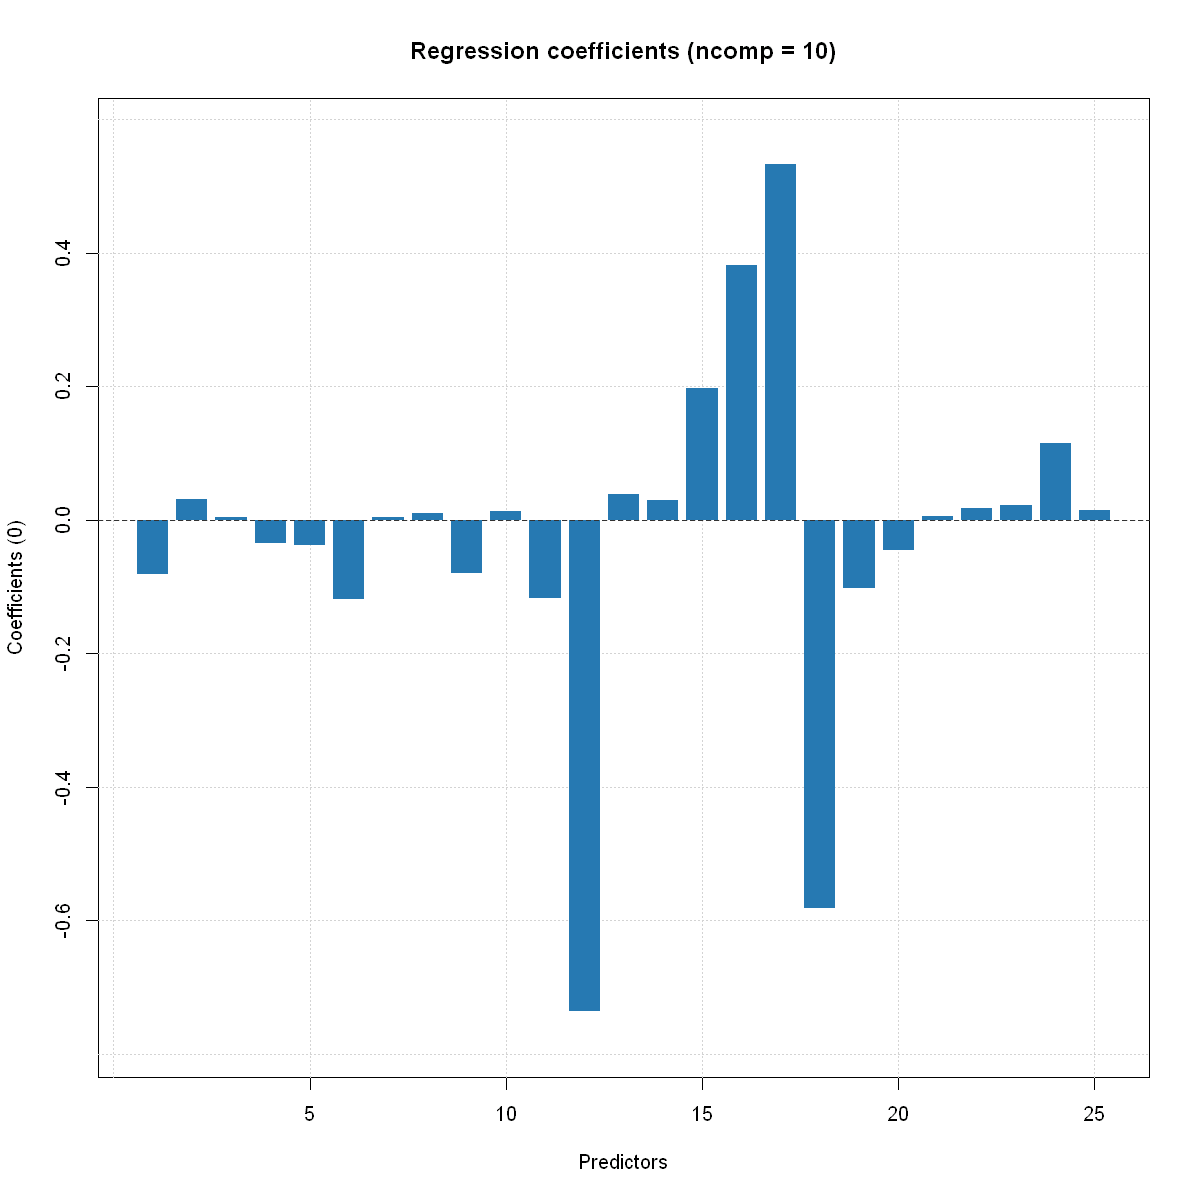

In [48]:
plotRegcoeffs(res.plsda)

In [49]:
pred.plsda = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = test_scaledH)[, -1], c.ref=test_scaledH$Heart_Disease_Risk)

In [50]:
table(pred.plsda$c.pred[, 3,2], test_scaledH[, "Heart_Disease_Risk"])

    
        0    1
  -1 1036  374
  1   233  607

In [51]:
cat('Recall: ', sum(pred.plsda$c.pred[, 3,2]==1 & y_true)/sum(y_true), '\n')

#Precision
cat('Precision: ', sum(pred.plsda$c.pred[, 3,2]==1 & y_true)/sum(pred.plsda$c.pred[, 3,2]==1), '\n')

#F beta score
cat('F1 Score: ', fbeta_score(y_true, pred.plsda$c.pred[, 3,2]==1, beta = 1), '\n')

Recall:  0.6187564 
Precision:  0.722619 
F1 Score:  0.6666667 


In [52]:
p=-1
score = 0
nc = 1
pred_val = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = val_scaledH)[, -1], c.ref=val_scaledH$Heart_Disease_Risk)
for (x in seq(-0.6, 0.6, length.out = 50)){
    for (i in 1:10){
        if (score < fbeta_score(y_val, pred_val$y.pred[, i,2]>x, beta = 1)){
            p = x
            nc = i
            score = fbeta_score(y_val, pred_val$y.pred[, i,2]>x, beta = 1)
        }
    }
}
p_plsda = p
nc
#Recall
cat('Recall : ',sum(pred.plsda$y.pred[, nc,2] >p_plsda & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred.plsda$y.pred[, nc,2] >p_plsda & y_true)/sum(pred.plsda$y.pred[, nc,2] >p_plsda))

#F beta score
cat('\nF1 score :', fbeta_score(y_true, pred.plsda$y.pred[, nc,2] >p_plsda, beta = 1))

table(pred.plsda$y.pred[, nc,2] > p_plsda, test_scaledH[, "Heart_Disease_Risk"])

[1] 7

Recall :  0.8114169
Precision :  0.617533
F1 score : 0.7013216

       
          0   1
  FALSE 776 185
  TRUE  493 796

In [53]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "PLS-DA",
    Precision = sum(pred.plsda$y.pred[, nc,2] > p_plsda & y_true)/sum(pred.plsda$y.pred[, nc,2] > p_plsda),
    Recall = sum(pred.plsda$y.pred[, nc,2] > p_plsda & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,pred.plsda$y.pred[, nc,2] > p_plsda, beta = 1),
    Accuracy = (sum(pred.plsda$y.pred[, nc,2] > p_plsda & y_true) + sum(pred.plsda$y.pred[, nc,2] < p_plsda & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667


## SVM

For SVM linear, there are two hyperparameters to optimize, including the cost `C` and the `class.weights`. When `C` increases, the contraints are stricter and the penalty is higher.

In [54]:
library(e1071) #kernel svm
library(LiblineaR) #linear svm

Warning message:
"package 'e1071' was built under R version 4.4.3"

Attaching package: 'e1071'


The following object is masked from 'package:ggplot2':

    element


Warning message:
"package 'LiblineaR' was built under R version 4.4.3"


### Linear SVM

#### CV

In [55]:
# Custom summary function for F-beta
fbeta_summary <- function(data, lev = NULL, model = NULL) {
  # Change beta to 1 for F1-score, or 2 to prioritize recall
  beta <- 1 
  
  # Calculate Precision and Recall using caret's built-in tools
  precision <- posPredValue(data$pred, data$obs, positive = lev[2])
  recall <- sensitivity(data$pred, data$obs, positive = lev[2])
  
  # Calculate F-beta
  f_beta <- (1 + beta^2) * (precision * recall) / ((beta^2 * precision) + recall)
  
  # If F-beta is NaN (e.g., zero precision/recall), return 0
  if (is.na(f_beta)) f_beta <- 0
  
  names(f_beta) <- "Fbeta"
  return(f_beta)
}

In [56]:
train_ctrl <- trainControl(
  method = "cv",               # Cross-validation
  number = 5,                  # 5-fold CV
  summaryFunction = fbeta_summary,   
  savePredictions = "final"
)

In [57]:
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
weight_ratios <- c(1, 1.5, 2, 3,4,5)
results_df <- data.frame()
set.seed(123)
pb <- txtProgressBar(
  min = 0,
  max = length(weight_ratios),
  style = 3
)
for(i in 1:length(weight_ratios)){
    w <- weight_ratios[i]
    model <- train(Heart_Disease_Risk ~ ., data = train_scaledH,
                 method = "svmLinear3",
                 metric = "Fbeta",
                 trControl = train_ctrl,
                 tuneGrid = expand.grid(cost = c(1, 1.5, 2, 2.5, 3, 3.5), Loss = "L2_primal"),
                 wi = c("NoRisk" = 1, "Risk" = w))
    res <- model$results
    res$weight_ratio <- w
    results_df <- rbind(results_df, res)
    setTxtProgressBar(pb, i)
}
    

  |======================================================================| 100%

In [58]:
best_idx <- order(-results_df$Fbeta)[1]
best_params <- results_df[best_idx, ]

print("Best Parameters Found:")
print(best_params)

[1] "Best Parameters Found:"


   cost      Loss     Fbeta     FbetaSD weight_ratio
14  1.5 L2_primal 0.7042732 0.007645669            2


#### Choose threshold value

In [59]:
levels(train_scaledH$Heart_Disease_Risk) <- c(0, 1)
final_weights <- c("0" = 1, "1" = best_params$weight_ratio)

svm.lin <- svm(
  Heart_Disease_Risk ~ .,
  data = train_scaledH,
  kernel = "linear",
  cost = best_params$cost,
  class.weights = final_weights,
  scale = FALSE,
  probability = TRUE
)

svm.lin


Call:
svm(formula = Heart_Disease_Risk ~ ., data = train_scaledH, kernel = "linear", 
    cost = best_params$cost, class.weights = final_weights, probability = TRUE, 
    scale = FALSE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  linear 
       cost:  1.5 

Number of Support Vectors:  6788


In [60]:
pred.svm.lin <- predict(svm.lin, test_scaledH)
table(predicted = pred.svm.lin, actual = y_true)
#Recall
cat('Recall : ',sum(pred.svm.lin==1 & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred.svm.lin==1 & y_true)/sum(pred.svm.lin==1))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred.svm.lin==1, beta = 1))

         actual
predicted   0   1
        0 810 191
        1 459 790

Recall :  0.8053007
Precision :  0.632506
F1 :  0.7085202

In [61]:
p_svm_lin <- calculate_threshold(y_val, attr(predict(svm.lin, val_scaledH, probability = TRUE), "probabilities")[,2])
p_svm_lin
prob_svm <- attr(predict(svm.lin, test_scaledH, probability = TRUE), "probabilities")
#Recall
cat('Recall : ',sum(prob_svm[,2] >p_svm_lin & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(prob_svm[,2] >p_svm_lin &y_true)/sum(prob_svm[,2] >p_svm_lin))

#F beta score
cat('\nF1 score : ',fbeta_score(y_true, prob_svm[,2] >p_svm_lin, beta = 1))

table(predicted = prob_svm[,2] > p_svm_lin, actual = y_true)

[1] 0.3693878

Recall :  0.7787971
Precision :  0.6502128
F1 score :  0.7087199

         actual
predicted   0   1
    FALSE 858 217
    TRUE  411 764

In [62]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "SVM lin",
    Precision = sum(prob_svm[,2] >p_svm_lin & y_true)/sum(prob_svm[,2] >p_svm_lin),
    Recall = sum(prob_svm[,2] >p_svm_lin & y_true)/sum(y_true),
    F1 = fbeta_score(y_true, prob_svm[,2] >p_svm_lin, beta = 1),
    Accuracy = (sum(prob_svm[,2] >p_svm_lin & y_true) + sum(prob_svm[,2] <=p_svm_lin & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889


#### Coefficients

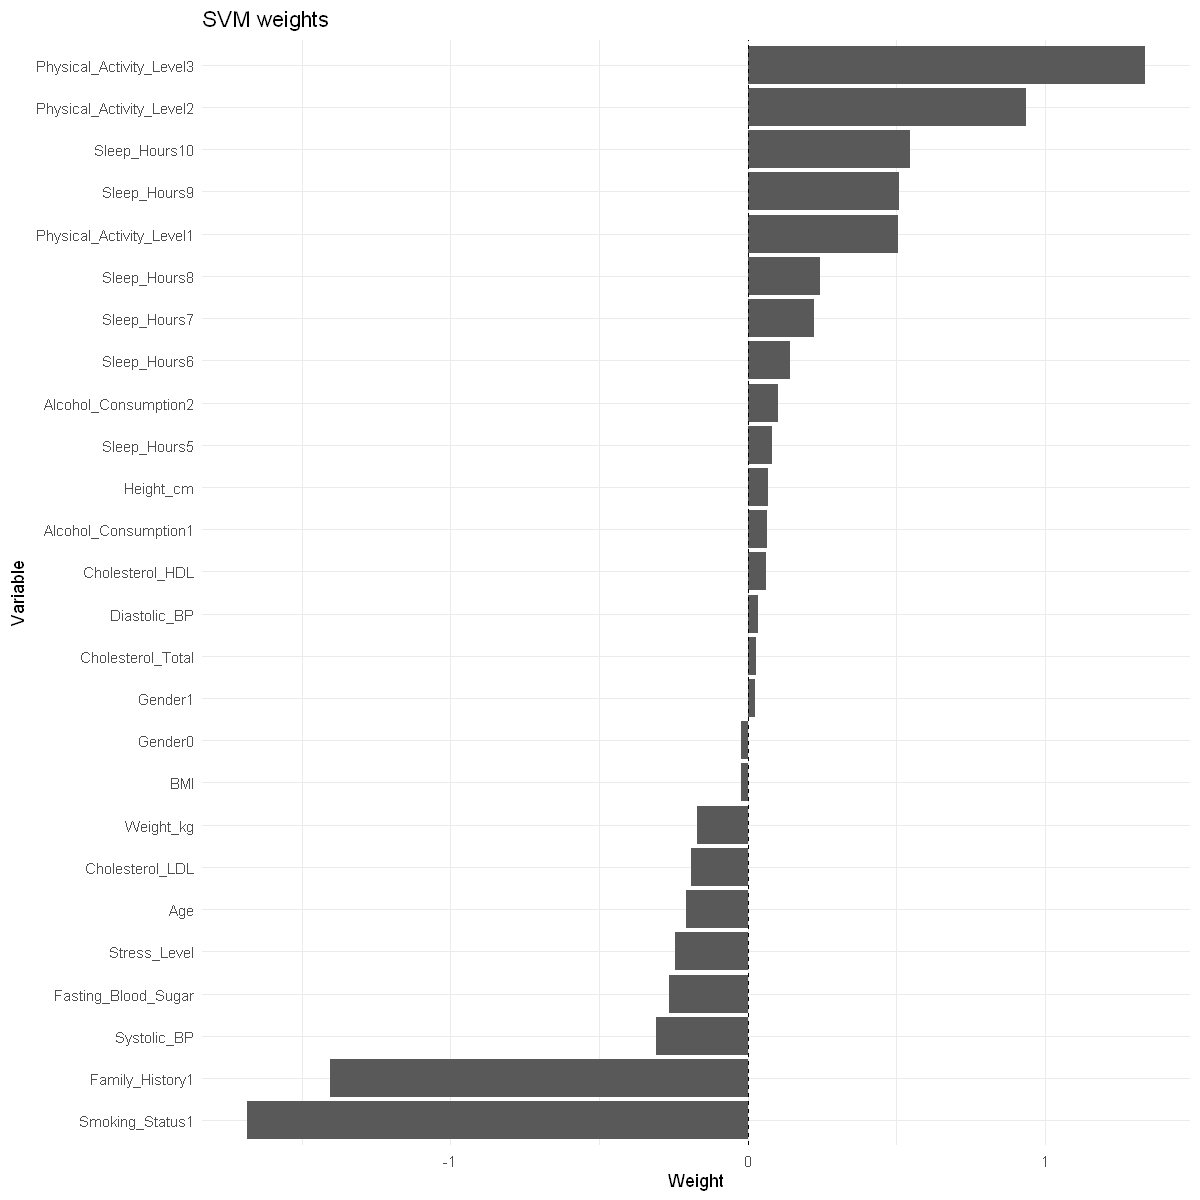

In [63]:
w <- t(svm.lin$coefs) %*% svm.lin$SV
w_df <- data.frame( Variable = colnames(svm.lin$SV), Weight = as.numeric(w))
ggplot(w_df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "SVM weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

### kernel SVM

For this model, we choose the rbf kernel due to its adaptability to many datasets. Compared to linear SVM, there is one more hyperparameter to optimize, which is`sigma` (gamma in the theorical formulation). If gamma increases, the radius of influence of each point becomes smaller, meaning that the model is likely to be overfit. On the contrary, the smaller gamma means wider radius of influence, so the decision boundary becomes smoother.

In [64]:
svm.ker = svm(Heart_Disease_Risk ~ ., data = train_scaledH, type = "C", class.weights = c("0" = 1, "1" = 2), kernel = "radial")

In [65]:
pred.svm <- predict(svm.ker, test_scaledH[,-18])
table(predicted = pred.svm, actual = test_scaledH[, "Heart_Disease_Risk"])
#Recall
cat('Recall : ',sum(pred.svm==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1))

#Precision
cat('\nPrecision : ',sum(pred.svm==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm==1))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred.svm==1, beta = 1))

         actual
predicted   0   1
        0 788 179
        1 481 802

Recall :  0.8175331
Precision :  0.6250974
F1 :  0.7084806

In [66]:
# Default value of gamma = 1/nb of features = 1/26
svm.ker$gamma

[1] 0.03846154

#### CV

In [67]:
library(kernlab)
library(doParallel)


Attaching package: 'kernlab'


The following object is masked from 'package:purrr':

    cross


The following object is masked from 'package:ggplot2':

    alpha


Warning message:
"package 'doParallel' was built under R version 4.4.3"
Loading required package: foreach


Attaching package: 'foreach'


The following objects are masked from 'package:purrr':

    accumulate, when


Loading required package: iterators

Loading required package: parallel



In [68]:
# Detect cores
n_cores <- parallel::detectCores() - 2
n_cores
cl <- makeCluster(n_cores)
registerDoParallel(cl)

# Define a grid based on the estimates
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
tune_grid <- expand.grid(
  sigma = c(0.01, 1/26, 0.05),     # Uses the 3 values suggested by sigest
  C = c(0.1, 1, 5, 10)       # Standard range for Cost
)

weight_ratios <- c(1, 2, 2.5)

kernel_results <- data.frame()

pb <- txtProgressBar(
  min = 0,
  max = length(weight_ratios),
  style = 3
)

for (i in 1:length(weight_ratios)) {
  w <- weight_ratios[i]
  set.seed(123)
  
  # Note: kernlab (svmRadial) uses 'class.weights' argument
  curr_weights <- c("NoRisk" = 1, "Risk" = w)
  
  temp_model <- train(
    Heart_Disease_Risk ~ ., 
    data = train_scaledH,
    method = "svmRadial",
    metric = "Fbeta",
    trControl = trainControl(method = "cv", number = 5, 
                             summaryFunction = fbeta_summary, verboseIter = TRUE,allowParallel = TRUE),
    tuneGrid = tune_grid,
    class.weights = curr_weights
  )
  
  res <- temp_model$results
  res$weight_ratio <- w
  kernel_results <- rbind(kernel_results, res)
  setTxtProgressBar(pb, i)
}
if (exists("cl") && inherits(cl, "cluster")) {
      tryCatch(
        stopCluster(cl),
        error = function(e) message("Cluster already stopped or invalid.")
      )
    }
close(pb)

# Stop parallel backend
registerDoSEQ()
levels(train_scaledH$Heart_Disease_Risk) <- c(0, 1)

[1] 10

  |                                                                      |   0%Aggregating results
Selecting tuning parameters
Fitting sigma = 0.01, C = 10 on full training set
  |=======================                                               |  33%Aggregating results
Selecting tuning parameters
Fitting sigma = 0.01, C = 0.1 on full training set
  |===============================================                       |  67%Aggregating results
Selecting tuning parameters
Fitting sigma = 0.01, C = 5 on full training set
  |======================================================================| 100%


In [69]:
best_param <- kernel_results[order(-kernel_results$Fbeta)[1],]
best_param

,sigma,C,Fbeta,FbetaSD,weight_ratio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
13,0.01,0.1,0.7027404,0.004410463,2


#### Choose threshold value

In [70]:
levels(train_scaledH$Heart_Disease_Risk) <- c(0, 1)
svm.ker = svm(Heart_Disease_Risk ~ ., data = train_scaledH, type = "C", class.weights = c("0" = 1, "1" = best_param$weight_ratio), 
    kernel = "radial", gamma = best_param$sigma, cost = best_param$C, probability = TRUE)

In [71]:
pred.svm <- predict(svm.ker, test_scaledH[,-18])
table(predicted = pred.svm, actual = test_scaledH[, "Heart_Disease_Risk"])
#Recall
cat('Recall : ',sum(pred.svm==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1))

#Precision
cat('\nPrecision : ',sum(pred.svm==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.svm==1))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred.svm==1, beta = 1))

         actual
predicted   0   1
        0 655 136
        1 614 845

Recall :  0.861366
Precision :  0.5791638
F1 :  0.692623

In [84]:
prob_svm_ker_val <- attr(predict(svm.ker, val_scaledH, probability = TRUE), "probabilities")
p_svm_ker <- calculate_threshold(y_val, prob_svm_ker_val[,2])
prob_svm_ker <- attr(predict(svm.ker, test_scaledH, probability = TRUE), "probabilities")
#Recall
cat('Recall : ',sum(prob_svm_ker[,2] >p_svm_ker & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(prob_svm_ker[,2] >p_svm_ker &y_true)/sum(prob_svm_ker[,2] >p_svm_ker))

#F beta score
cat('\nF1 score : ',fbeta_score(y_true, prob_svm_ker[,2] >p_svm_ker, beta = 1))

table(predicted = prob_svm_ker[,2] > p_svm_ker, actual = y_true)

Recall :  0.8073394
Precision :  0.6255924
F1 score :  0.7049399

         actual
predicted   0   1
    FALSE 795 189
    TRUE  474 792

In [74]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "SVM ker",
    Precision = sum(prob_svm_ker[,2] >p_svm_ker & y_true)/sum(prob_svm_ker[,2] >p_svm_ker),
    Recall = sum(prob_svm_ker[,2] >p_svm_ker & y_true)/sum(y_true),
    F1 = fbeta_score(y_true, prob_svm_ker[,2] >p_svm_ker, beta = 1),
    Accuracy = (sum(prob_svm_ker[,2] >p_svm_ker & y_true) + sum(prob_svm_ker[,2] <= p_svm_ker & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333


## Decision tree

In [75]:
library(rpart) 

In [76]:
train_scaledH$Heart_Disease_Risk <- as.factor(train_scaledH$Heart_Disease_Risk)
tree.dis=rpart(Heart_Disease_Risk ~ ., data = train_scaledH,cp=0.001,parms=list(split="information"))

Warning message:
"package 'rpart.plot' was built under R version 4.4.3"


Warning message:
"labs do not fit even at cex 0.15, there may be some overplotting"


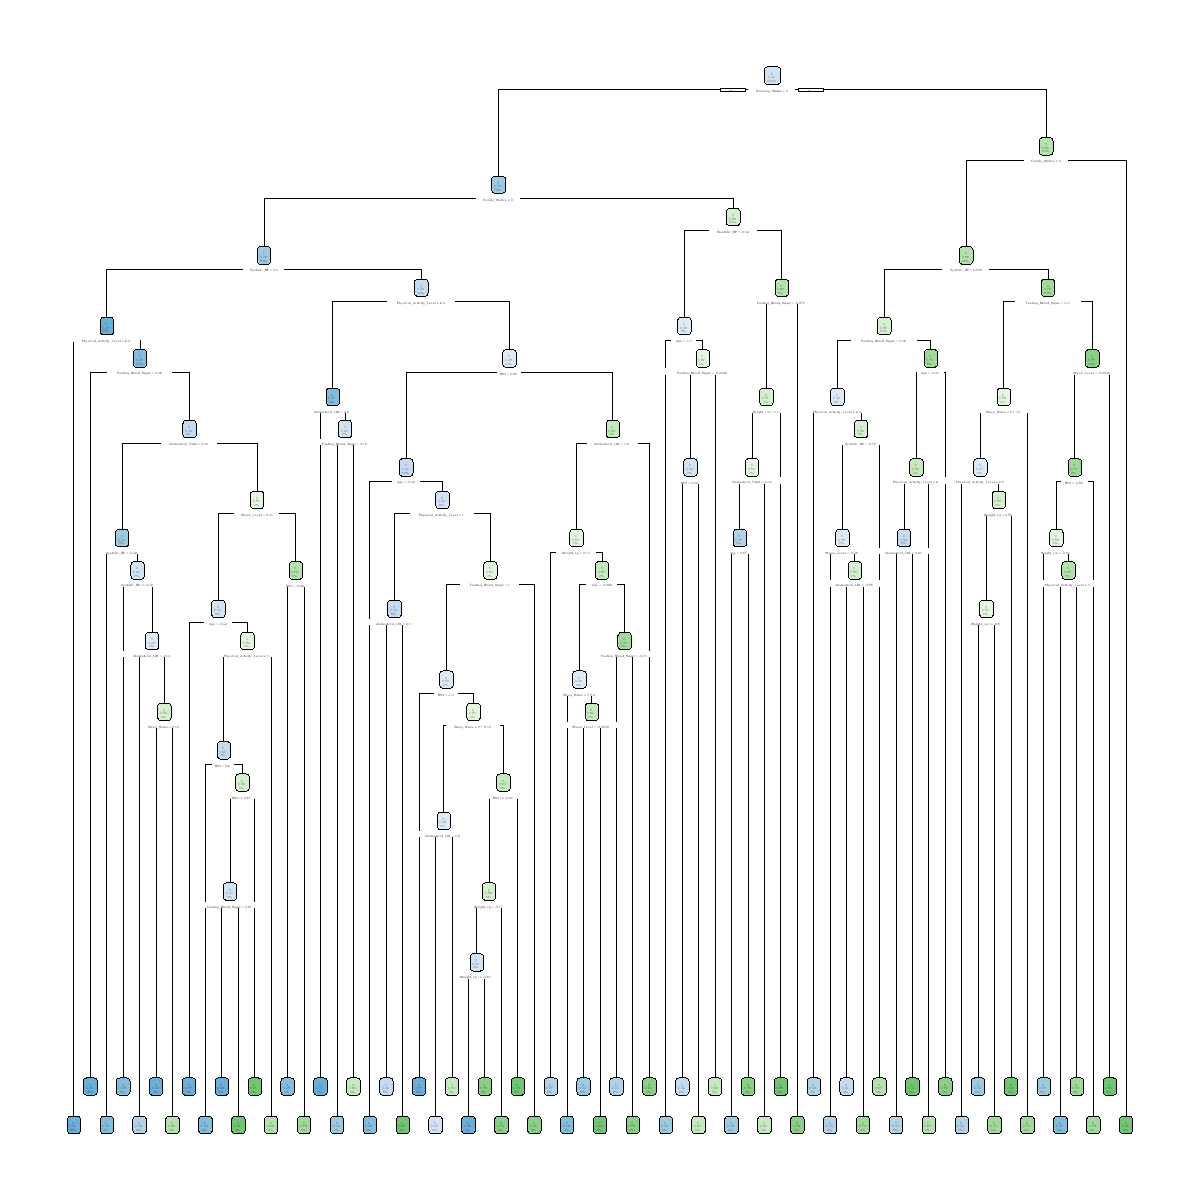

In [77]:
library(rpart.plot)
rpart.plot(tree.dis)

### Cross validation

In [78]:
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")

ctrl <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = fbeta_summary,
  savePredictions = "final",
  allowParallel = TRUE
)

grid_cp <- expand.grid(
  cp = seq(0.001, 0.01, by = 0.0005)
)

maxdepth_values <- c(3, 5, 7, 10, 15)
weight_ratios <- c(1, 1.5, 2, 2.5, 3)

tree_results <- data.frame()
tree_models <- list()

counter <- 1
total_models <- length(maxdepth_values) * length(weight_ratios)

pb <- txtProgressBar(
  min = 0,
  max = total_models,
  style = 3
)
n_cores <- parallel::detectCores() - 1
cl <- makeCluster(n_cores)
registerDoParallel(cl)

for (d in maxdepth_values) {
  
  for (w in weight_ratios) {
    
    set.seed(123)
    
    # Case weights
    obs_weights <- ifelse(
      train_scaledH$Heart_Disease_Risk == "Risk",
      w,
      1
    )
    
    tree_cv <- train(
      Heart_Disease_Risk ~ .,
      data = train_scaledH,
      method = "rpart",
      metric = "Fbeta",
      trControl = ctrl,
      tuneGrid = grid_cp,
      parms = list(split = "information"),
      control = rpart.control(maxdepth = d),
      weights = obs_weights
    )
    
    res <- tree_cv$results
    res$maxdepth <- d
    res$weight_ratio <- w
    
    tree_results <- rbind(tree_results, res)
    
    model_name <- paste0("depth_", d, "_w_", w)
    tree_models[[model_name]] <- tree_cv
    
    setTxtProgressBar(pb, counter)
    counter <- counter + 1
  }
}

close(pb)
stopCluster(cl)
registerDoSEQ()

  |                                                                      |   0%

  |======================================================================| 100%


In [79]:
best_par <- tree_results[which.max(tree_results$Fbeta), ]
best_par

,cp,Fbeta,FbetaSD,maxdepth,weight_ratio
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
439,0.0015,0.682074,0.006825511,15,2.5


Warning message:
"cex and tweak both specified, applying both"


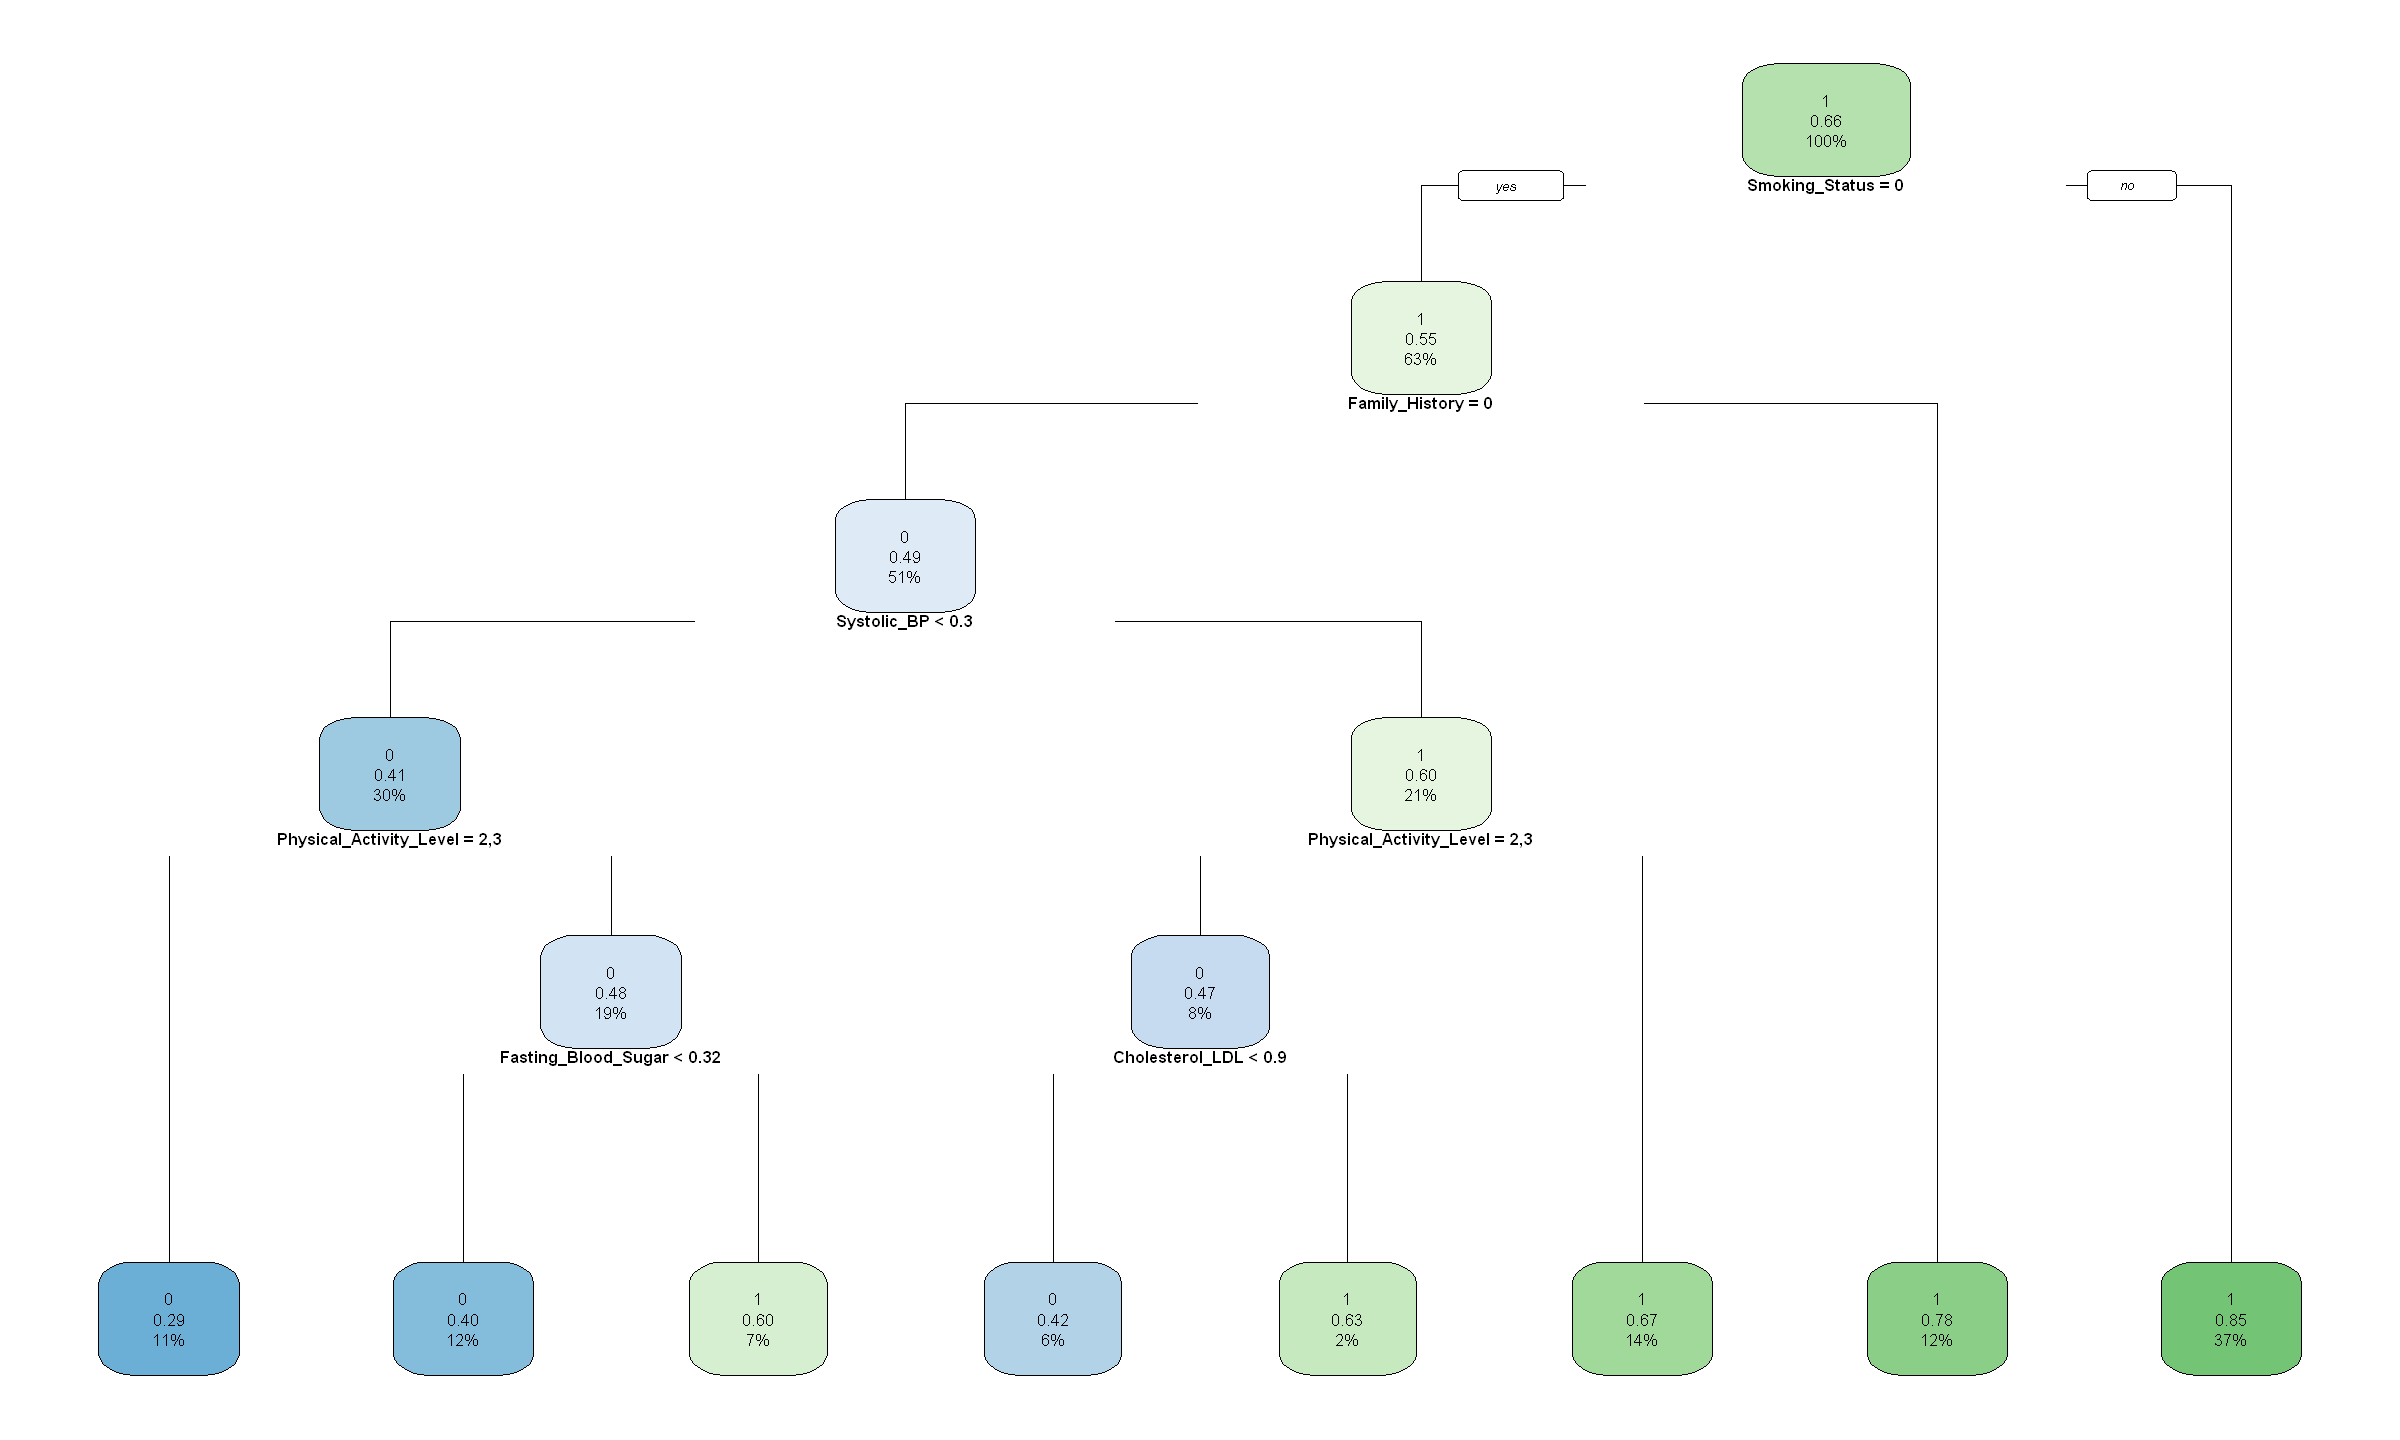

In [80]:
levels(train_scaledH$Heart_Disease_Risk) <- c("0", "1")
options(repr.plot.width = 20, repr.plot.height = 12)
tree.dis=rpart(Heart_Disease_Risk ~ ., data = train_scaledH,cp=best_par$cp,parms=list(split="information"),
    control = rpart.control(maxdepth = best_par$maxdepth), weights = ifelse(train_scaledH$Heart_Disease_Risk == "1", best_par$weight_ratio, 1))
rpart.plot(tree.dis,cex = 0.7, tweak = 1.2)

### Choose threshold value

In [85]:
y_val_prob_tree = predict(tree.dis, newdata = val_scaledH)[,2]
p_tree = calculate_threshold(y_val, y_val_prob_tree)
cat('Threshold proba : ',p_tree)
#Recall
pred.treeq=predict(tree.dis,newdata=test_scaledH)[,2]

cat('\nRecall : ',sum(pred.treeq >p_tree & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred.treeq >p_tree &y_true)/sum(pred.treeq >p_tree))

#F beta score
cat('\nF1 score : ',fbeta_score(y_true, pred.treeq >p_tree, beta = 1))

table(predicted = pred.treeq > p_tree, actual = y_true)

Threshold proba :  0.6387755


Recall :  0.7502548
Precision :  0.6062603
F1 score :  0.670615

         actual
predicted   0   1
    FALSE 791 245
    TRUE  478 736

In [86]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "tree",
    Precision = sum(pred.treeq >p_tree & y_true)/sum(pred.treeq >p_tree),
    Recall = sum(pred.treeq >p_tree & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,pred.treeq >p_tree, beta = 1),
    Accuracy = (sum(pred.treeq >p_tree & y_true) + sum(pred.treeq <p_tree & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333
tree,0.6062603,0.7502548,0.6706150,0.6786667


## Random Forest

In [87]:
library(randomForest)

Warning message:
"package 'randomForest' was built under R version 4.4.3"


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: 'randomForest'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:ggplot2':

    margin




In [88]:
# TODO : Change the parameter
res.forest = randomForest(Heart_Disease_Risk ~ ., data = train_scaledH, xtest = test_scaledH[,-18], 
                          ytest = test_scaledH$Heart_Disease_Risk,ntree=500,do.trace=50,importance=TRUE,
                         classwt = c(1, 1),keep.forest = TRUE)
res.forest$importance

ntree      OOB      1      2|    Test      1      2
   50:  29.19% 21.65% 38.95%|  26.62% 18.05% 37.72%
  100:  28.10% 20.26% 38.25%|  25.69% 17.26% 36.60%
  150:  27.82% 19.91% 38.05%|  26.62% 17.89% 37.92%
  200:  27.82% 19.71% 38.31%|  26.36% 17.65% 37.61%
  250:  27.64% 19.71% 37.90%|  25.42% 17.26% 35.98%
  300:  27.76% 19.59% 38.34%|  25.82% 17.73% 36.29%
  350:  27.61% 19.39% 38.25%|  26.09% 17.65% 37.00%
  400:  27.66% 19.44% 38.29%|  26.04% 17.65% 36.90%
  450:  27.62% 19.42% 38.23%|  26.00% 17.73% 36.70%
  500:  27.67% 19.44% 38.31%|  26.27% 17.97% 37.00%


,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,5.468090e-03,0.0076627114,0.0064258868,376.73916
Gender,1.911441e-04,0.0010564816,0.0005702597,40.58501
Height_cm,2.006457e-03,0.0016431970,0.0018491168,354.85941
Weight_kg,6.148771e-03,0.0068455910,0.0064479643,370.96775
BMI,5.826196e-03,0.0065411019,0.0061337332,367.04459
Systolic_BP,9.166514e-03,0.0133225345,0.0109718775,383.48514
Diastolic_BP,5.696718e-03,0.0046681209,0.0052387092,321.46696
Cholesterol_Total,4.426790e-03,0.0063140627,0.0052469515,357.51023
Cholesterol_LDL,4.896179e-03,0.0075330038,0.0060395629,354.65439
Cholesterol_HDL,-2.900094e-04,0.0011268797,0.0003246474,289.71703


**Comments:** ntree = 500 might be too high and lead to overfitting, since the error on the test set has increased.

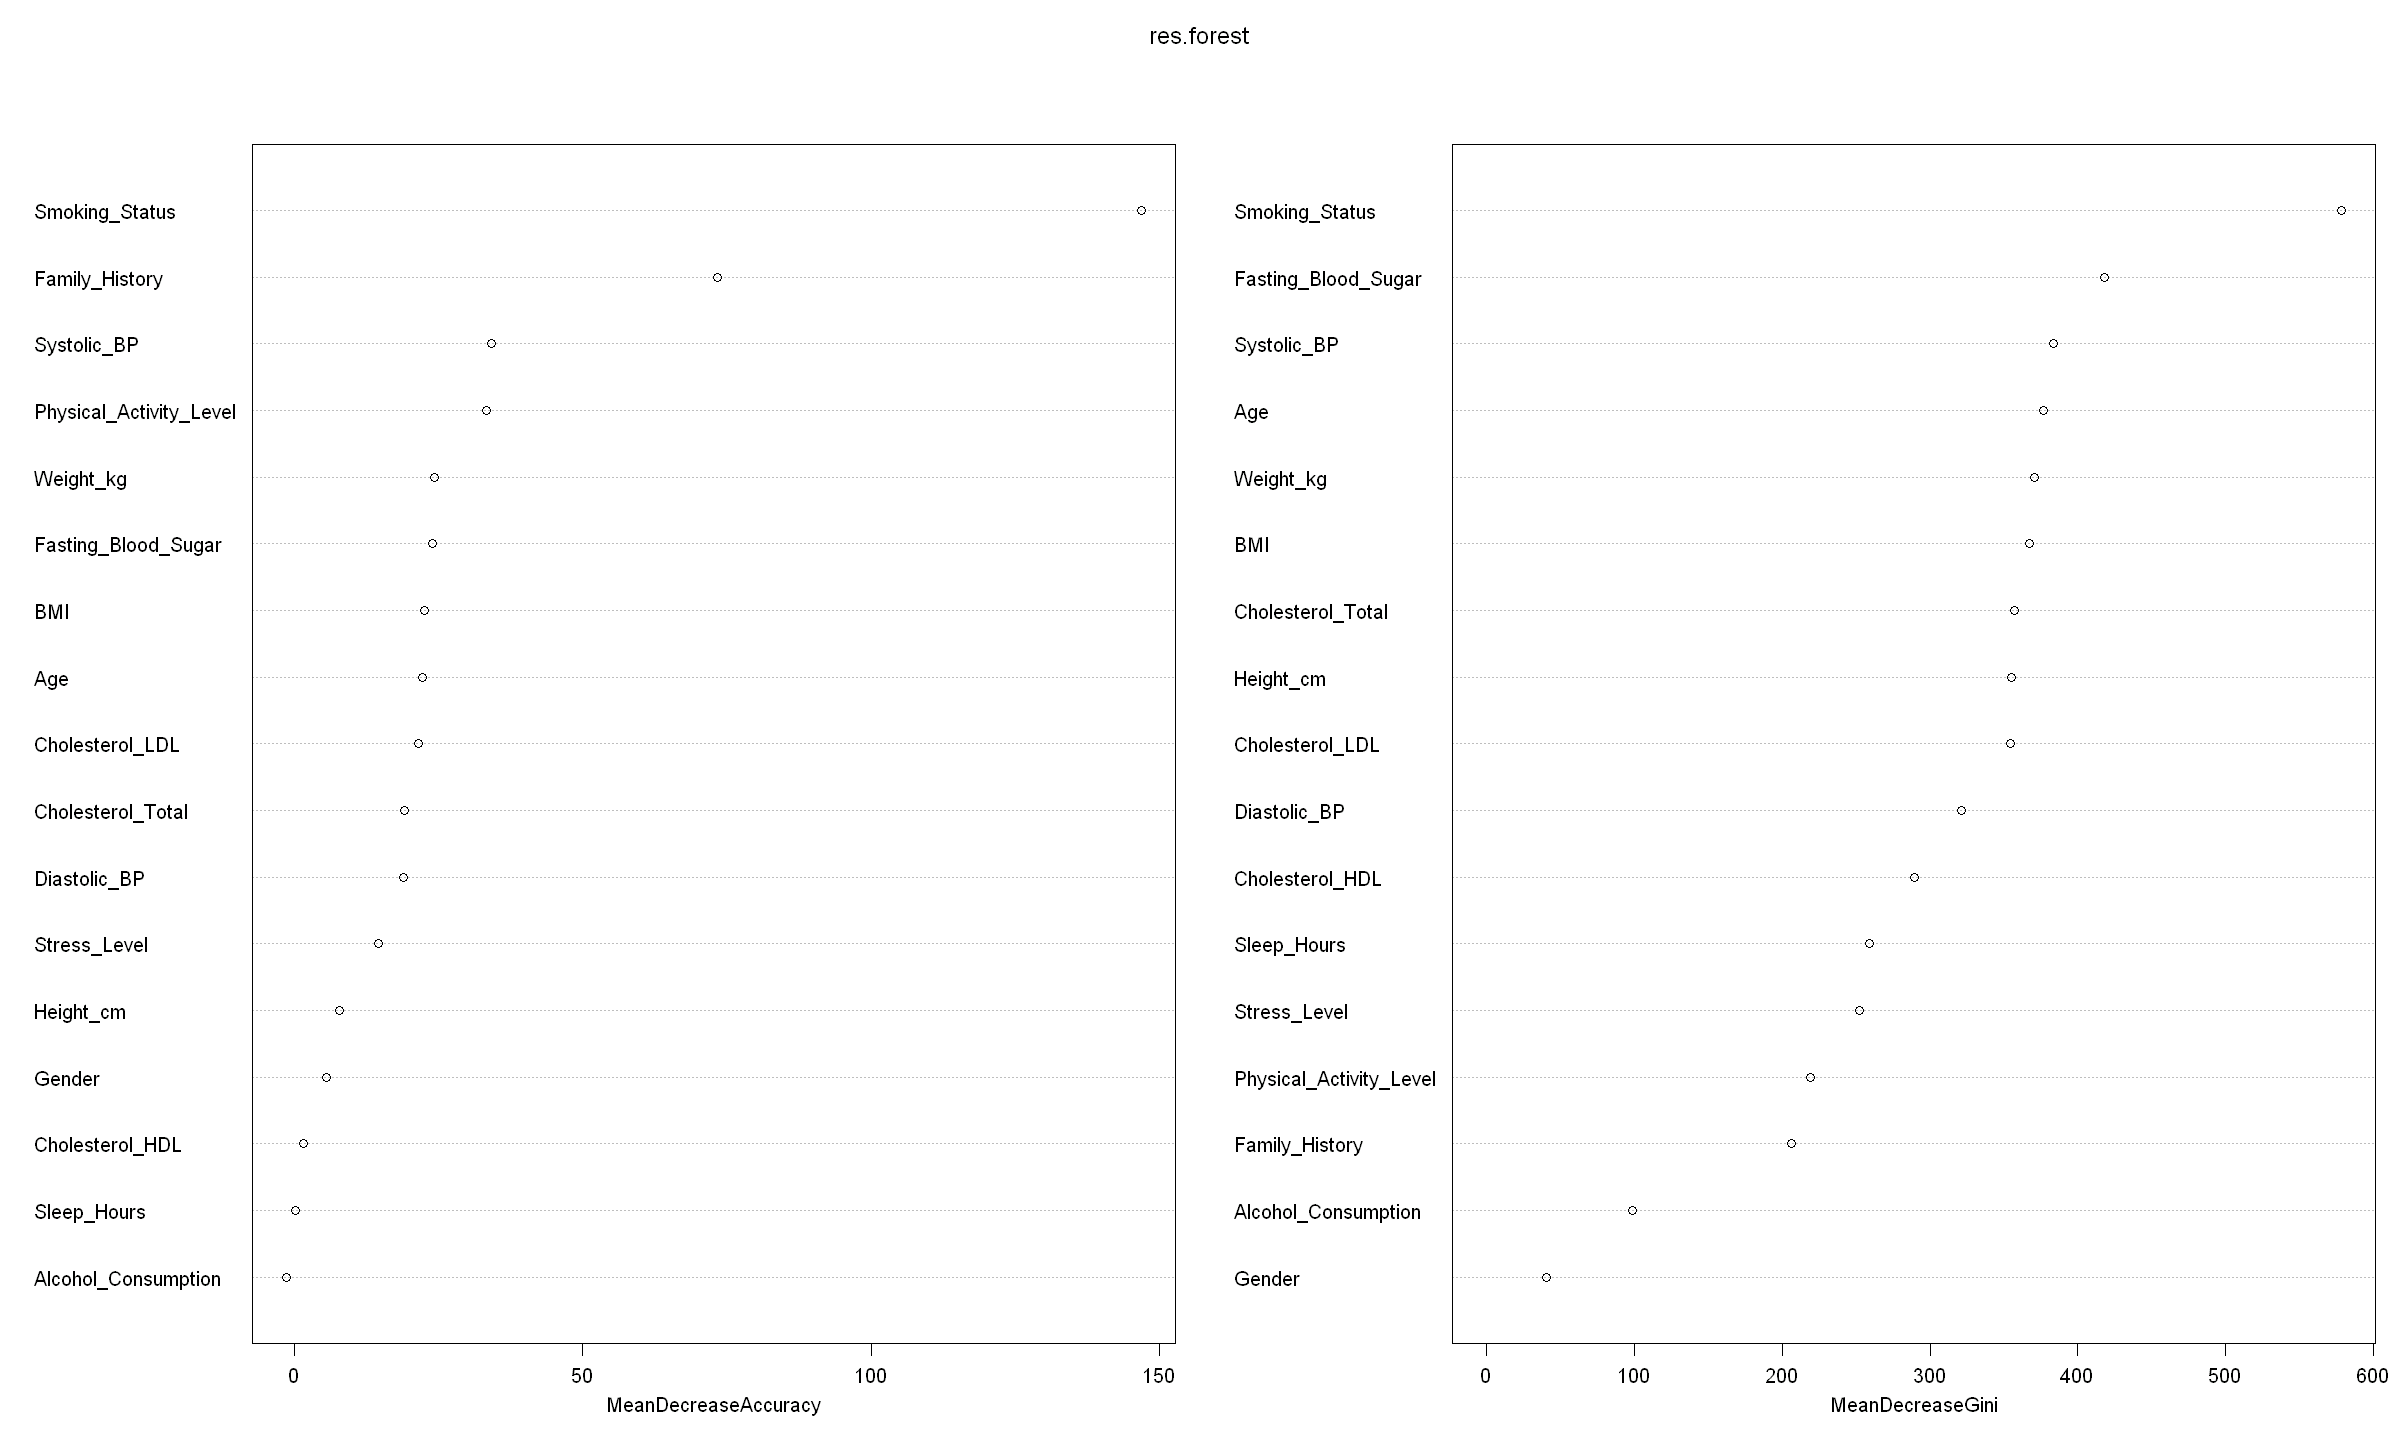

In [89]:
varImpPlot(res.forest)

In [90]:
pred.forest <- res.forest$test$predicted
table(pred.forest, test_scaledH[, "Heart_Disease_Risk"])
#Recall
cat('Recall : ',sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1))

#Precision
cat('\nPrecision : ',sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.forest==1))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred.forest==1, beta = 1))

           
pred.forest    0    1
          0 1041  363
          1  228  618

Recall :  0.6299694
Precision :  0.7304965
F1 :  0.6765189

### CV

Here we will tune mtry, i.e. the number of variables considered for each iteration, and class weight.

In [91]:
library(doParallel)

In [92]:
n_cores <- parallel::detectCores() - 1
cl <- makePSOCKcluster(n_cores)
registerDoParallel(cl)
levels(train_scaledH$Heart_Disease_Risk) <- c("NoRisk", "Risk")
weight_ratios <- c(1, 1.5, 2)
ntree_values <- c(100, 200, 300, 400)

results_rf <- data.frame()
models_rf <- list()

ctrl <- trainControl(
  method = "cv",
  number = 5,
  classProbs = TRUE,
  summaryFunction = fbeta_summary,
  savePredictions = "final",
  allowParallel = TRUE
)
grid_rf <- expand.grid(
  mtry = c(2, 4, 6, 8, 10, 12)
)
counter <- 1
total_models <- length(weight_ratios) * length(ntree_values)
pb <- txtProgressBar(
  min = 0,
  max = total_models,
  style = 3
)

for (w in weight_ratios) {
  for (nt in ntree_values) {
    cat('\nweight : ',w)
    set.seed(123)
    rf_tmp <- train(
        Heart_Disease_Risk ~ .,
        data = train_scaledH,
        method = "rf",
        metric = "Fbeta",
        trControl = ctrl,
        tuneGrid = grid_rf,
        ntree = nt,
        importance = FALSE,
        classwt = c("NoRisk" = 1, "Risk" = w)
      )
    res <- rf_tmp$results
    res$weight_ratio <- w
    res$ntree <- nt
    results_rf <- rbind(results_rf, res)
    models_rf[[paste0("w_", w)]] <- rf_tmp
    cat('\ndone')

    counter <- counter + 1
    setTxtProgressBar(pb, counter)
  }
}
close(pb)
stopCluster(cl)
registerDoSEQ()
results_rf

  |                                                                      |   0%
weight :  1
  |============                                                          |  17%
weight :  1
  |==================                                                    |  25%
weight :  1
  |=======================                                               |  33%
weight :  1
  |=============================                                         |  42%
weight :  1.5
  |===================================                                   |  50%
weight :  1.5
  |=========================================                             |  58%
weight :  1.5
  |===============================================                       |  67%
weight :  1.5
  |====================================================                  |  75%
weight :  2
  |==========================================================            |  83%
weight :  2
  |================================================================     

mtry,Fbeta,FbetaSD,weight_ratio,ntree
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,0.6594756,0.015088088,1.0,100
4,0.6556577,0.008478243,1.0,100
6,0.6493378,0.011542009,1.0,100
8,0.6527297,0.013756942,1.0,100
10,0.6530177,0.011104627,1.0,100
12,0.6462404,0.013597653,1.0,100
2,0.6613324,0.012732634,1.0,200
4,0.6544162,0.009810307,1.0,200
6,0.6521934,0.010073777,1.0,200


In [93]:
best_par <- results_rf[which.max(results_rf$Fbeta), ]
best_par

,mtry,Fbeta,FbetaSD,weight_ratio,ntree
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
61,2,0.6901166,0.004373244,2,300


In [94]:
levels(train_scaledH$Heart_Disease_Risk) <- c("0", "1")
res.forest = randomForest(Heart_Disease_Risk ~ ., data = train_scaledH, xtest = test_scaledH[,-18], 
                          ytest = test_scaledH$Heart_Disease_Risk,ntree=best_par$ntree,do.trace=50,importance=TRUE,
                         classwt = c(1, best_par$weight_ratio),keep.forest = TRUE, mtry=best_par$mtry)
res.forest$importance

ntree      OOB      1      2|    Test      1      2
   50:  29.93% 22.17% 39.97%|  27.38% 19.31% 37.82%
  100:  28.97% 20.45% 40.00%|  26.49% 17.97% 37.51%
  150:  28.16% 19.94% 38.79%|  26.62% 18.12% 37.61%
  200:  27.82% 20.20% 37.68%|  26.00% 17.73% 36.70%
  250:  27.63% 20.01% 37.48%|  25.73% 17.34% 36.60%
  300:  27.64% 20.01% 37.51%|  25.87% 17.65% 36.49%


,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,0.0021346079,0.0100449437,5.579306e-03,324.51755
Gender,-0.0012893100,0.0042398585,1.125803e-03,46.54291
Height_cm,-0.0013700158,0.0056679505,1.702605e-03,309.32489
Weight_kg,-0.0017840659,0.0132078071,4.758640e-03,320.31416
BMI,-0.0009951770,0.0112340696,4.341034e-03,320.09923
Systolic_BP,0.0024922831,0.0168698707,8.772057e-03,329.32250
Diastolic_BP,-0.0003112632,0.0098066502,4.107603e-03,290.26582
Cholesterol_Total,-0.0014634699,0.0117766077,4.314532e-03,314.46899
Cholesterol_LDL,-0.0001284128,0.0117716828,5.066043e-03,307.36054
Cholesterol_HDL,-0.0006631222,0.0028648112,8.748941e-04,258.41500


In [95]:
pred.forest <- res.forest$test$predicted
table(pred.forest, test_scaledH[, "Heart_Disease_Risk"])
#Recall
cat('Recall : ',sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(test_scaledH[, "Heart_Disease_Risk"] == 1))

#Precision
cat('\nPrecision : ',sum(pred.forest==1 & test_scaledH[, "Heart_Disease_Risk"] == 1)/sum(pred.forest==1))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred.forest==1, beta = 1))

           
pred.forest    0    1
          0 1045  358
          1  224  623

Recall :  0.6350663
Precision :  0.7355372
F1 :  0.6816193

### Choose threshold value

In [113]:
score = c()
y_val_prob_forest = predict(res.forest, newdata = val_scaledH, type = "prob")[,2]
p_rf = calculate_threshold(y_val, y_val_prob_forest)
cat('Threshold proba : ',p_rf)

Threshold proba :  0.3693878

In [133]:
y_prob_forest = predict(res.forest, newdata = test_scaledH, type = "prob")[,2]
cat('Recall : ',sum(y_prob_forest >p_rf & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(y_prob_forest >p_rf &y_true)/sum(y_prob_forest >p_rf))

#Fbeta score
cat('\nF1 : ',fbeta_score(y_true, y_prob_forest >p_rf, beta = 1))

table(predicted = y_prob_forest > p_rf, y_true)

Recall :  0.8216106
Precision :  0.6092215
F1 :  0.6996528

         y_true
predicted   0   1
    FALSE 752 175
    TRUE  517 806

In [134]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "rf",
    Precision = sum(res.forest$test$votes[,2] >p_rf & y_true)/sum(res.forest$test$votes[,2] >p_rf),
    Recall = sum(res.forest$test$votes[,2] >p_rf & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,res.forest$test$votes[,2] >p_rf, beta = 1),
    Accuracy = (sum(res.forest$test$votes[,2] >p_rf & y_true) + sum(res.forest$test$votes[,2] <p_rf & !y_true))/length(y_true)
  )
)

In [135]:
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333
tree,0.6062603,0.7502548,0.6706150,0.6786667
rf,0.6092215,0.8216106,0.6996528,0.6924444
xgboost,0.6468619,0.7879715,0.7104779,0.7200000


## XGboost

In [136]:
#install.packages("xgboost")
library(xgboost)

In [137]:
X_train_num <- model.matrix(~ . - 1, data = train_scaledH[,-18])

y_train_num <- as.numeric(as.character(train_scaledH$Heart_Disease_Risk))

table(y_train_num)
dim(X_train_num)

y_train_num
   0    1 
5922 4578 

[1] 10500    26

In [138]:
dtrain <- xgb.DMatrix(
  data = X_train_num,
  label = y_train_num
)

### CV

In [139]:
grid_xgb <- expand.grid(
  max_depth = c(2, 3, 4, 5),
  eta = c(0.01, 0.03, 0.05, 0.1),
  colsample_bytree = c(0.7, 0.8, 1)
)

results_xgb <- data.frame()

# Progress bar
pb <- txtProgressBar(
  min = 0,
  max = nrow(grid_xgb),
  style = 3
)

for (i in 1:nrow(grid_xgb)) {
  
  cat("\nModel", i, "of", nrow(grid_xgb), "\n")
  
  params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    booster = "gbtree",
    max_depth = grid_xgb$max_depth[i],
    eta = grid_xgb$eta[i],
    subsample = 0.8,
    colsample_bytree = grid_xgb$colsample_bytree[i]
  )
  
  set.seed(123)
  
  cv <- xgb.cv(
    params = params,
    data = dtrain,
    nrounds = 500,
    nfold = 5,
    early_stopping_rounds = 20,
    verbose = 0
  )
  
  auc_col <- grep("test.*aucpr.*mean", names(cv$evaluation_log), value = TRUE)
  auc_sd_col <- grep("test.*aucpr.*std", names(cv$evaluation_log), value = TRUE)
  
  if (length(auc_col) == 0) {
    print(names(cv$evaluation_log))
    stop("Cannot find the test AUC-PR mean column.")
  }
  
  best_iter <- which.max(cv$evaluation_log[[auc_col]])
  best_score <- cv$evaluation_log[[auc_col]][best_iter]
  
  if (length(auc_sd_col) > 0) {
    best_sd <- cv$evaluation_log[[auc_sd_col]][best_iter]
  } else {
    best_sd <- NA_real_
  }
  
  results_xgb <- rbind(
    results_xgb,
    data.frame(
      max_depth = grid_xgb$max_depth[i],
      eta = grid_xgb$eta[i],
      colsample_bytree = grid_xgb$colsample_bytree[i],
      best_iteration = best_iter,
      aucpr = best_score,
      aucpr_sd = best_sd
    )
  )
  
  # Update progress bar
  setTxtProgressBar(pb, i)
}

close(pb)

  |                                                                      |   0%
Model 1 of 48 
  |=                                                                     |   2%
Model 2 of 48 
  |===                                                                   |   4%
Model 3 of 48 
  |====                                                                  |   6%
Model 4 of 48 
  |======                                                                |   8%
Model 5 of 48 
  |=======                                                               |  10%
Model 6 of 48 
  |=========                                                             |  12%
Model 7 of 48 
  |==========                                                            |  15%
Model 8 of 48 
  |============                                                          |  17%
Model 9 of 48 
  |=============                                                         |  19%
Model 10 of 48 
  |===============                               

In [140]:
best_param = results_xgb[which.max(results_xgb$aucpr),]
best_param

,max_depth,eta,colsample_bytree,best_iteration,aucpr,aucpr_sd
,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
25,2,0.05,0.8,369,0.7601757,0.0180916


In [141]:
params <- list(
    objective = "binary:logistic",
    eval_metric = "aucpr",
    booster = "gbtree",
    max_depth = best_param$max_depth,
    eta =best_param$eta,
    subsample = 0.8,
    colsample_bytree = best_param$colsample_bytree
  )
xgb_model <- xgb.train(
    params = params,
    data = dtrain,
    nrounds = best_param$best_iteration,
    verbose = 1
)

### Choose threshold value

In [142]:
proba_val <- predict(xgb_model, model.matrix(~ . - 1, data = val_scaledH[,-18]))
p_xgb <- calculate_threshold(y_val, proba_val)
cat('Threshold proba : ',p_xgb)

Threshold proba :  0.3693878

In [143]:
proba_test <- predict(xgb_model,model.matrix(~ . - 1, data = test_scaledH[,-18]))

pred_test <- ifelse(proba_test > p_xgb, 1, 0)

# Recall
cat('Recall : ',sum(pred_test & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred_test & y_true)/sum(pred_test))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred_test, beta = 1))

table(
    Predicted = pred_test,
    Actual = y_true
)

Recall :  0.7879715
Precision :  0.6468619
F1 :  0.7104779

         Actual
Predicted   0   1
        0 847 208
        1 422 773

In [154]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "xgboost",
    Precision = sum(pred_test & y_true)/sum(pred_test),
    Recall = sum(pred_test & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,pred_test, beta = 1),
    Accuracy = (sum(pred_test & y_true) + sum(!pred_test & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333
tree,0.6062603,0.7502548,0.6706150,0.6786667
rf,0.6092215,0.8216106,0.6996528,0.6924444
xgboost,0.6468619,0.7879715,0.7104779,0.7200000


**Comments**: So far the xgboost seems to have the best performance, with high F1 score, high accuracy and high precision.

## NN

In this section we will use the same model chosen in python since the CV for neural network in R is not as convenient as in Python.

In [145]:
library(reticulate)
py_config()

python:         C:/Users/LT-MSI/Documents/.virtualenvs/r-reticulate/Scripts/python.exe
libpython:      C:/Users/LT-MSI/AppData/Local/Programs/Python/Python312/python312.dll
pythonhome:     C:/Users/LT-MSI/Documents/.virtualenvs/r-reticulate
version:        3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Architecture:   64bit
numpy:          C:/Users/LT-MSI/Documents/.virtualenvs/r-reticulate/Lib/site-packages/numpy
numpy_version:  2.2.2

In [146]:
library(tidyverse)
library(keras3)

Warning message:
"package 'keras3' was built under R version 4.4.3"


In [155]:
X_train_num <- model.matrix(~ . - 1, data = train_scaledH[,-18])
y_train_num <- as.numeric(as.character(train_scaledH$Heart_Disease_Risk))

In [201]:
model <- keras_model_sequential(input_shape = c(26)) |>
  layer_dense(units = 32, activation = "relu", kernel_regularizer = regularizer_l2(0.01)) |>
  layer_dense(units = 16, activation = "relu", kernel_regularizer = regularizer_l2(0.01)) |>
  layer_dense(units = 8, activation = "relu", kernel_regularizer = regularizer_l2(0.01)) |>
  layer_dense(units = 1, activation = "relu")

In [202]:
model |>
  compile(
    optimizer = "adam",
    loss = "binary_crossentropy", #loss for binary classification
    metrics = c("binary_accuracy")
  )

In [203]:
callback_early_stopping <- callback_early_stopping(
  monitor = "val_loss",
  patience = 5,
  restore_best_weights = TRUE
)

history <- model |>
  fit(
    x = X_train_num,
    y = y_train_num,
    epochs = 500,
    batch_size = 64,
    validation_split = 0.2,
    callbacks = list(callback_early_stopping)
  )

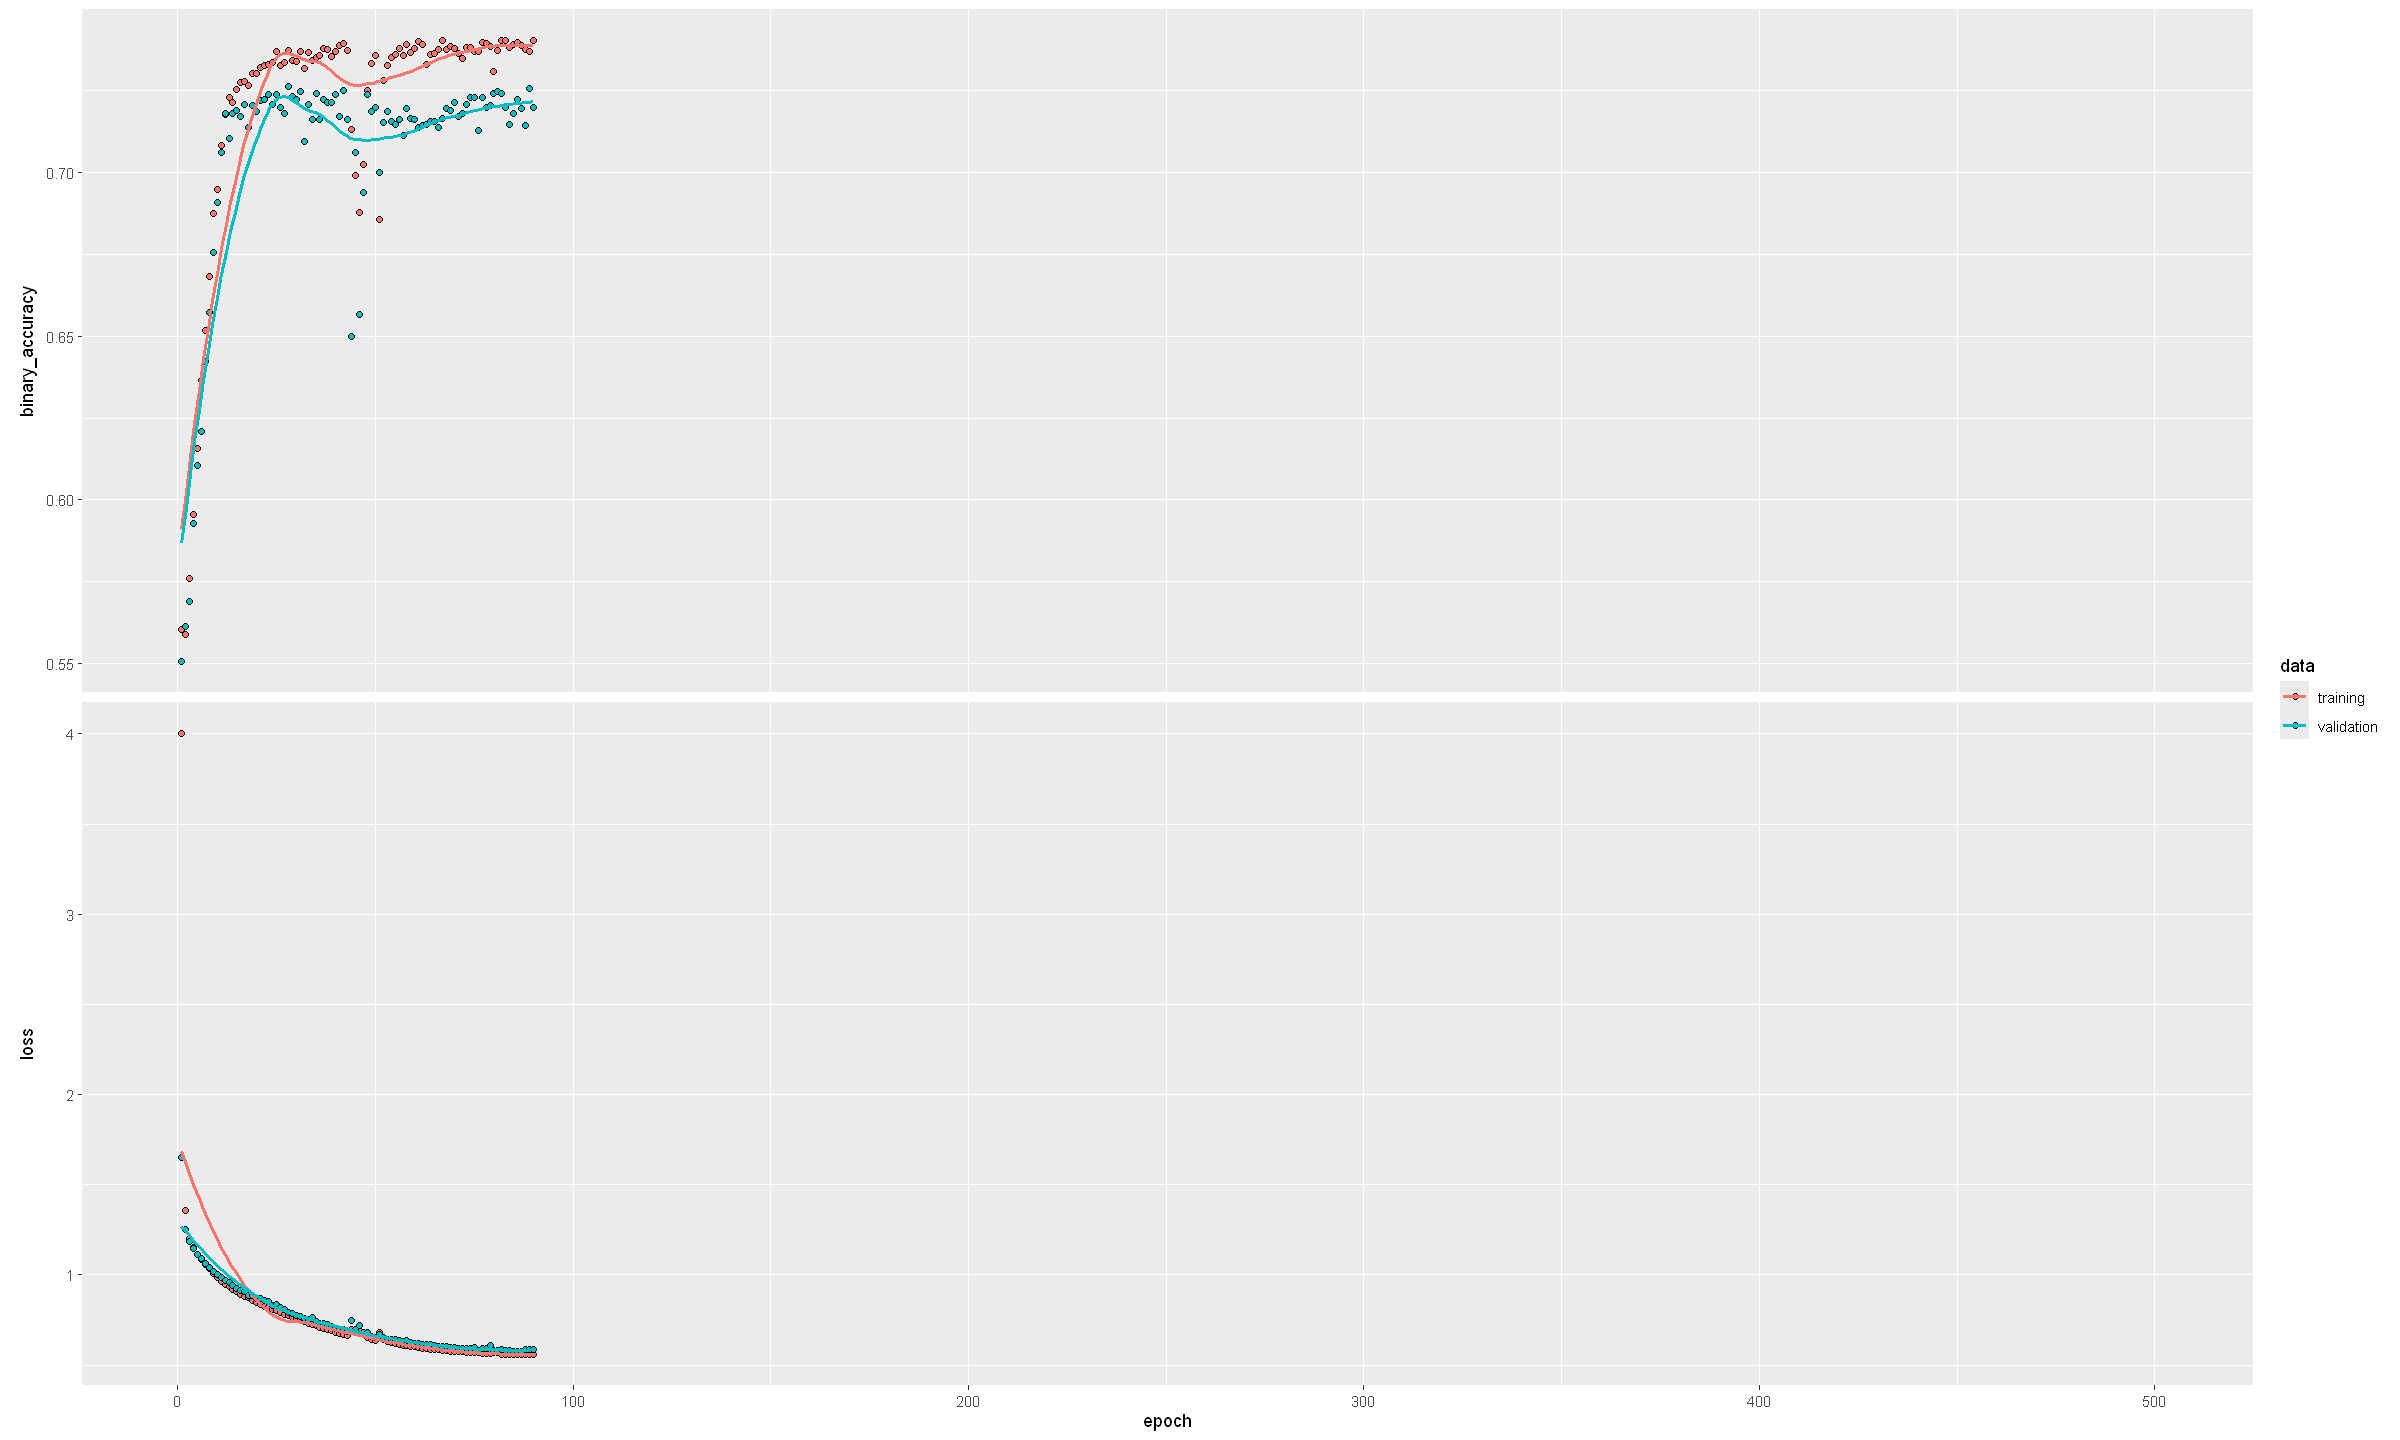

In [204]:
plot(history)

In [212]:
proba_train <- model |> predict(X_train_num)

pred_train <- ifelse(proba_train > 0.5, 1, 0)
table(
  Actual = y_train_num,
  Predicted = pred_train
)

      Predicted
Actual    0    1
     0 4849 1073
     1 1684 2894

In [213]:
proba_test <- model |> predict(model.matrix(~ . - 1, data = test_scaledH[,-18]))

pred_test <- ifelse(proba_test > 0.5, 1, 0)
table(
  Actual = y_true,
  Predicted = pred_test
)

      Predicted
Actual    0    1
     0 1057  212
     1  356  625

In [214]:
val_proba <- model |> predict(model.matrix(~ . - 1, data = val_scaledH[,-18]))
p_nn <- calculate_threshold(y_val, val_proba)
cat('Threshold proba : ',p_nn)

Threshold proba :  0.3204082

In [215]:
pred_test <- ifelse(proba_test > p_nn, 1, 0)
cat('Recall : ',sum(pred_test & y_true)/sum(y_true))

#Precision
cat('\nPrecision : ',sum(pred_test & y_true)/sum(pred_test))

#F beta score
cat('\nF1 : ',fbeta_score(y_true, pred_test, beta = 1))
table(
    Predicted = pred_test,
  Actual = y_true
)

Recall :  0.8389399
Precision :  0.6051471
F1 :  0.7031183

         Actual
Predicted   0   1
        0 732 158
        1 537 823

In [216]:
tab_mod <- rbind(
  tab_mod,
  data.frame(
    Name = "NN",
    Precision = sum(pred_test & y_true)/sum(pred_test),
    Recall = sum(pred_test & y_true)/sum(y_true),
    F1 = fbeta_score(y_true,pred_test, beta = 1),
    Accuracy = (sum(pred_test & y_true) + sum(!pred_test & !y_true))/length(y_true)
  )
)
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
LDA,0.6415563,0.7900102,0.7080859,0.7160000
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333
tree,0.6062603,0.7502548,0.6706150,0.6786667
rf,0.6092215,0.8216106,0.6996528,0.6924444
xgboost,0.6468619,0.7879715,0.7104779,0.7200000


## Comparison

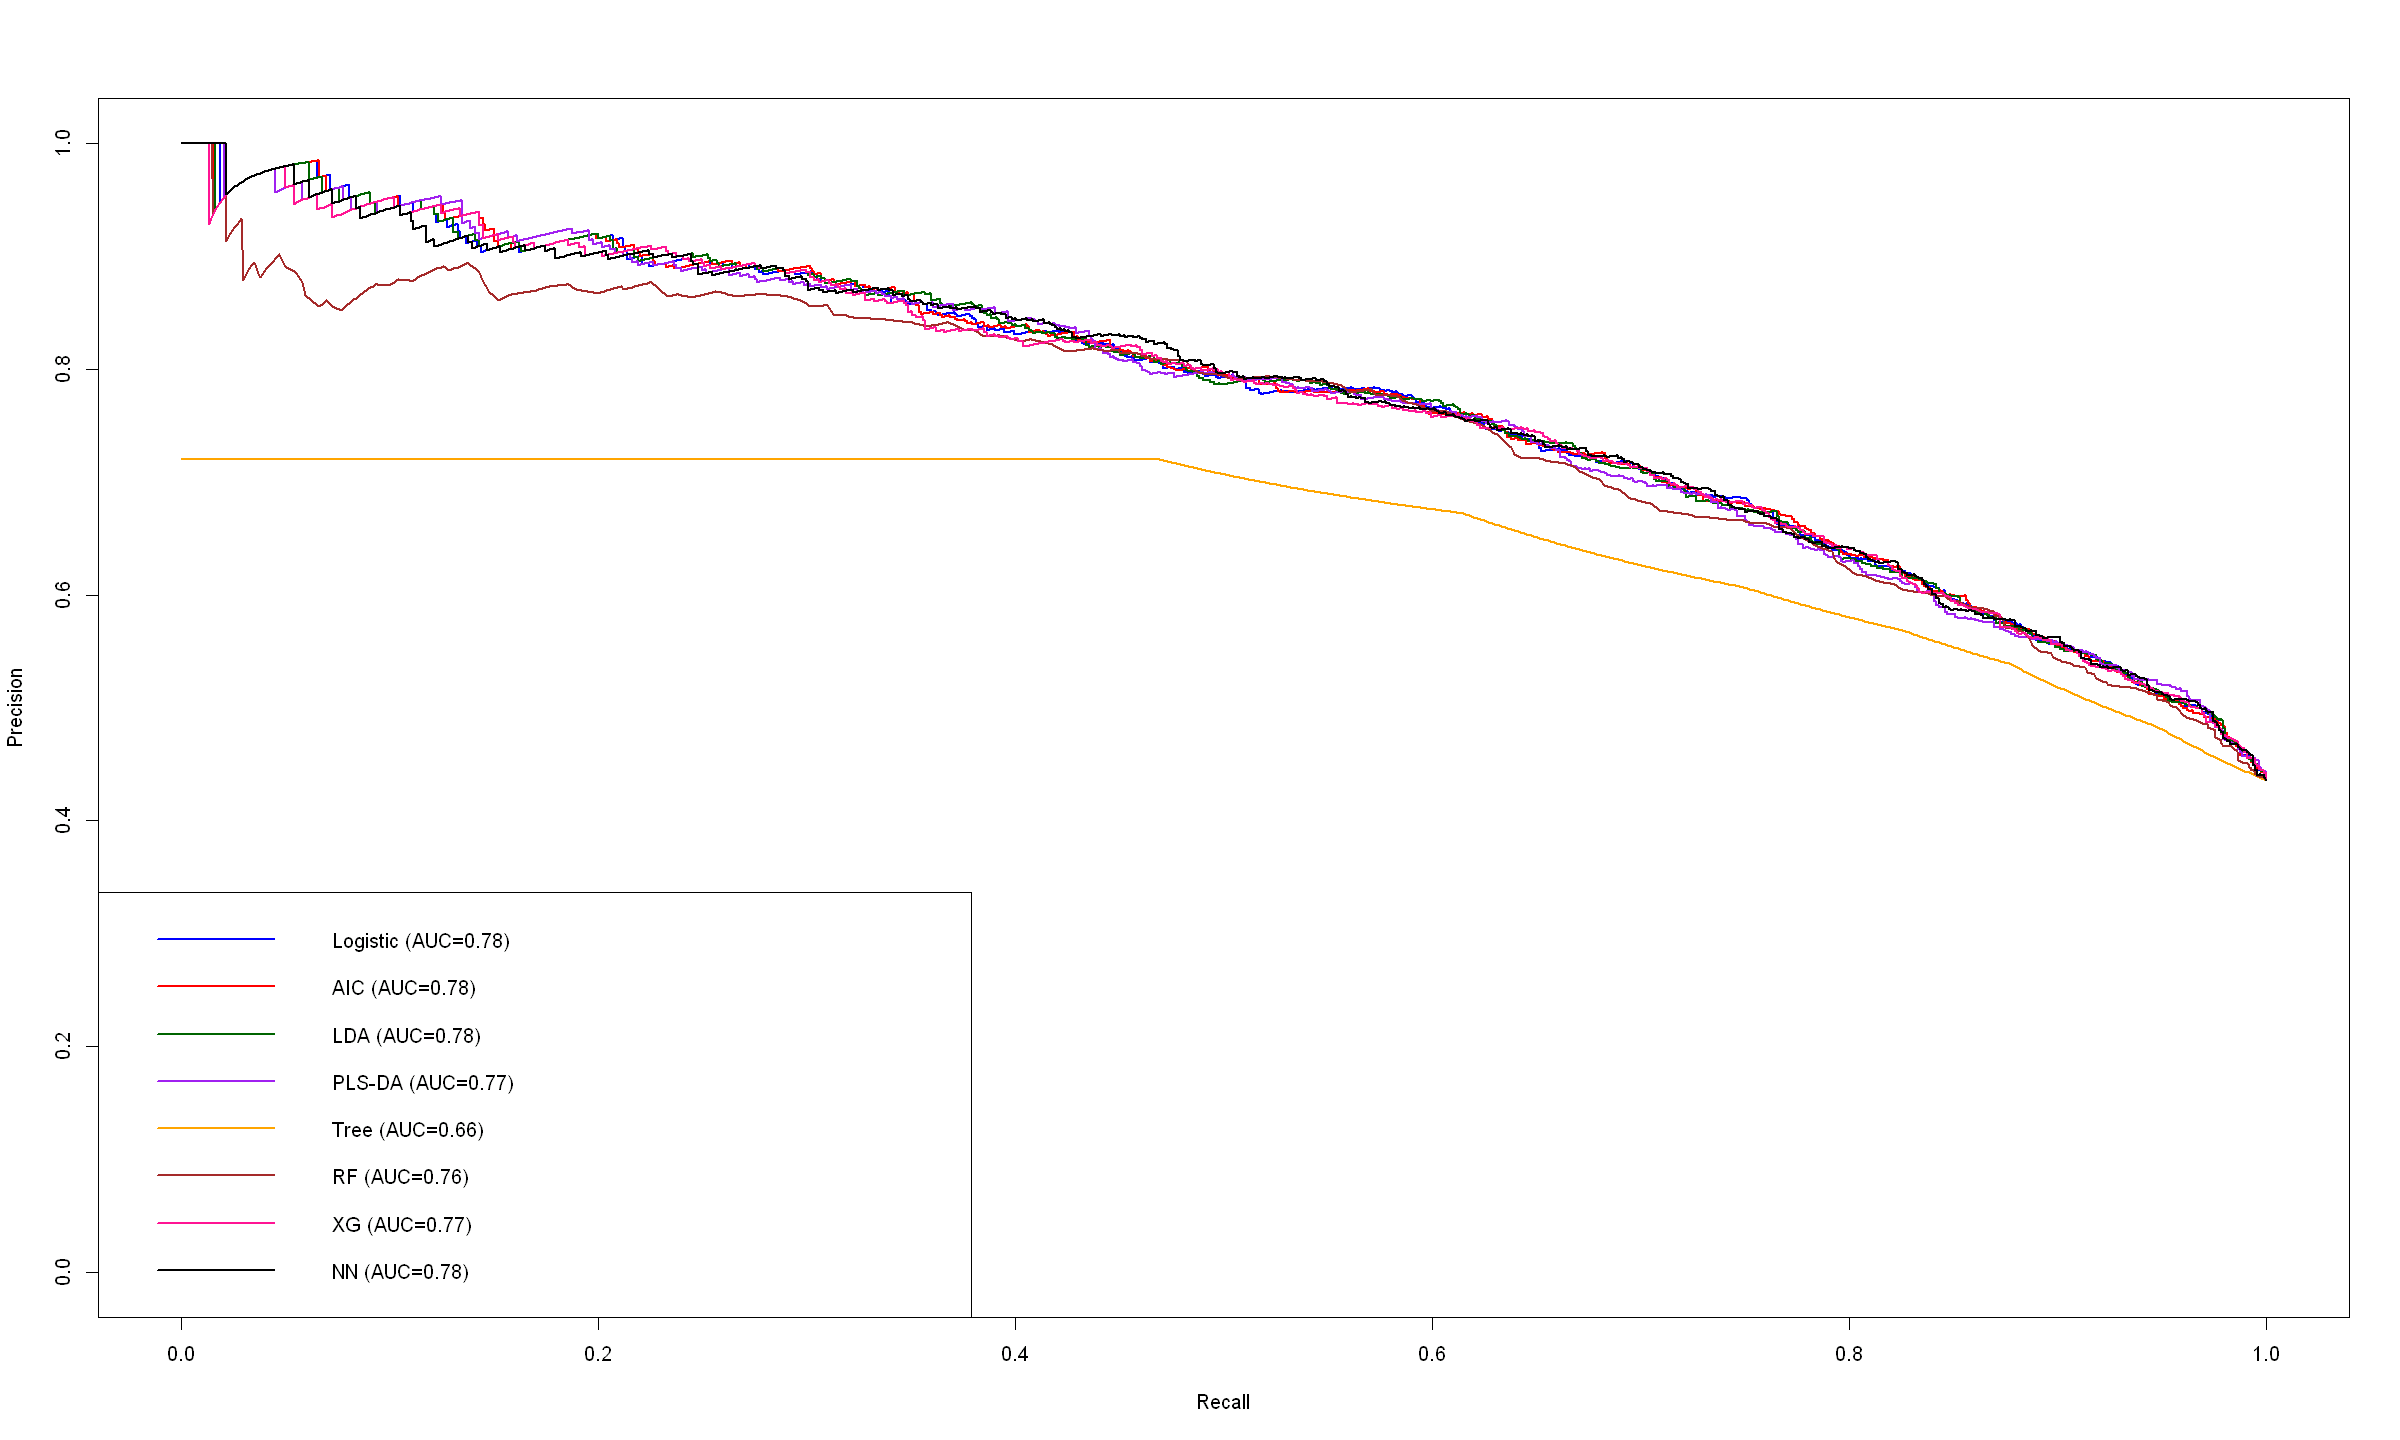

In [217]:
pred.log <- predict(res.log, newdata = test_scaledH, type = "response")
pred.log.aic <- predict(res.log.aic, newdata = test_scaledH, type = "response")
pred.lda <- predict(res.lda, newdata = test_scaledH, type = "response")$posterior[,2]
pred.plsda = predict(res.plsda,  model.matrix(Heart_Disease_Risk ~ . , data = test_scaledH)[, -1], c.ref=test_scaledH$Heart_Disease_Risk)$y.pred[, nc,2]
pred.treeq =predict(tree.dis,newdata=test_scaledH)[,2]
pred.rf = res.forest$test$votes[,2]
pred.xg = predict(xgb_model,model.matrix(~ . - 1, data = test_scaledH[,-18]))
pred.nn = model |> predict(model.matrix(~ . - 1, data = test_scaledH[,-18]))

pr1 = pr.curve(
  scores.class0 = pred.log,
  weights.class0 = y_true,
  curve = TRUE
)

pr2 = pr.curve(
  scores.class0 = pred.log.aic,
  weights.class0 = y_true,
  curve = TRUE
)

pr3 = pr.curve(
  scores.class0 = pred.lda,
  weights.class0 = y_true,
  curve = TRUE
)

pr4 = pr.curve(
  scores.class0 = pred.plsda,
  weights.class0 = y_true,
  curve = TRUE
)

pr5 = pr.curve(
  scores.class0 = pred.treeq,
  weights.class0 = y_true,
  curve = TRUE
)

pr6 = pr.curve(
  scores.class0 = pred.rf,
  weights.class0 = y_true,
  curve = TRUE
)

pr7 = pr.curve(
  scores.class0 = pred.xg,
  weights.class0 = y_true,
  curve = TRUE
)

pr8 = pr.curve(
  scores.class0 = pred.nn,
  weights.class0 = y_true,
  curve = TRUE
)

prs <- list(pr1, pr2, pr3, pr4, pr5, pr6, pr7, pr8)

cols <- c(
  "blue",
  "red",
  "darkgreen",
  "purple",
  "orange",
  "brown",
  "deeppink",
  "black"
)

plot(prs[[1]]$curve[,1], prs[[1]]$curve[,2],
     type = "l",
     col = cols[1],
     lwd = 2,
     xlab = "Recall",
     ylab = "Precision",
     xlim = c(0, 1),
     ylim = c(0, 1))

for (i in 2:length(prs)) {
  lines(prs[[i]]$curve[,1], prs[[i]]$curve[,2],
        col = cols[i],
        lwd = 2)
}

legend("bottomleft",
       legend = c(
           paste0("Logistic (AUC=", round(pr1$auc.integral,2), ")"),
           paste0("AIC (AUC=", round(pr2$auc.integral,2), ")"),
           paste0("LDA (AUC=", round(pr3$auc.integral,2), ")"),
           paste0("PLS-DA (AUC=", round(pr4$auc.integral,2), ")"),
           paste0("Tree (AUC=", round(pr5$auc.integral,2), ")"),
           paste0("RF (AUC=", round(pr6$auc.integral,2), ")"),
           paste0("XG (AUC=", round(pr7$auc.integral,2), ")"),
           paste0("NN (AUC=", round(pr8$auc.integral,2), ")")
       ),
       col = cols,
       lwd = 2)

Warning message:
"package 'pROC' was built under R version 4.4.3"
Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following object is masked from 'package:Metrics':

    auc




The following objects are masked from 'package:stats':

    cov, smooth, var


Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases

Setting levels: control = 0, case = 1

Setting direction: controls < cases



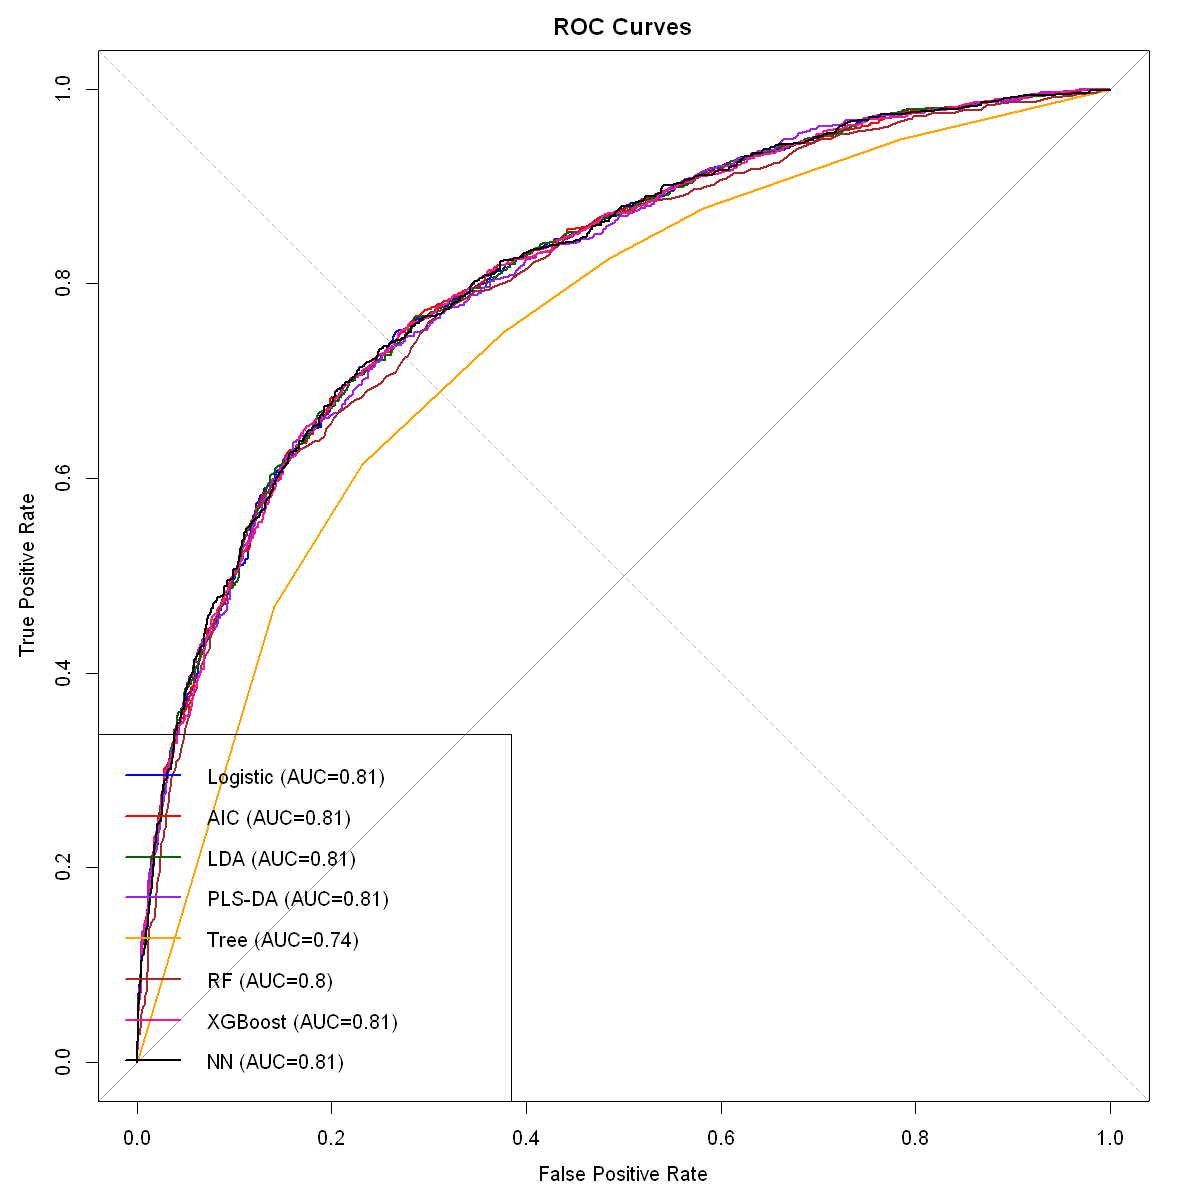

In [218]:
library(pROC)
roc1 <- roc(y_true, as.numeric(pred.log))
roc2 <- roc(y_true, as.numeric(pred.log.aic))
roc3 <- roc(y_true, as.numeric(pred.lda))
roc4 <- roc(y_true, as.numeric(pred.plsda))
roc5 <- roc(y_true, as.numeric(pred.treeq))
roc6 <- roc(y_true, as.numeric(pred.rf))
roc7 <- roc(y_true, as.numeric(pred.xg))
roc8 <- roc(y_true, as.numeric(pred.nn))

rocs <- list(roc1, roc2, roc3, roc4, roc5, roc6, roc7, roc8)

cols <- c(
  "blue",
  "red",
  "darkgreen",
  "purple",
  "orange",
  "brown",
  "deeppink",
  "black"
)
options(repr.plot.width = 10, repr.plot.height = 10)
plot(roc1,
     col = cols[1],
     lwd = 2,
     legacy.axes = TRUE,
     xlab = "False Positive Rate",
     ylab = "True Positive Rate",
     main = "ROC Curves")

for (i in 2:length(rocs)) {
  lines(rocs[[i]],
        col = cols[i],
        lwd = 2)
}

abline(a = 0, b = 1, lty = 2, col = "gray")

legend("bottomleft",
       legend = c(
         paste0("Logistic (AUC=", round(auc(roc1), 2), ")"),
         paste0("AIC (AUC=", round(auc(roc2), 2), ")"),
         paste0("LDA (AUC=", round(auc(roc3), 2), ")"),
         paste0("PLS-DA (AUC=", round(auc(roc4), 2), ")"),
         paste0("Tree (AUC=", round(auc(roc5), 2), ")"),
         paste0("RF (AUC=", round(auc(roc6), 2), ")"),
         paste0("XGBoost (AUC=", round(auc(roc7), 2), ")"),
         paste0("NN (AUC=", round(auc(roc8), 2), ")")
       ),
       col = cols,
       lwd = 2)

In [220]:
tab_mod <- tab_mod %>% arrange(desc(F1))
tab_mod

Name,Precision,Recall,F1,Accuracy
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
xgboost,0.6468619,0.7879715,0.7104779,0.7200000
Logistic regression AIC,0.6258769,0.8185525,0.7093640,0.7075556
SVM lin,0.6502128,0.7787971,0.7087199,0.7208889
LDA,0.6415563,0.7900102,0.7080859,0.7160000
Logistic regression,0.6270653,0.8124363,0.7078153,0.7075556
SVM ker,0.6255924,0.8073394,0.7049399,0.7053333
NN,0.6051471,0.8389399,0.7031183,0.6911111
PLS-DA,0.6175330,0.8114169,0.7013216,0.6986667
rf,0.6092215,0.8216106,0.6996528,0.6924444


## Analysis feature
### Linear models

In [221]:
library(gridExtra)


Attaching package: 'gridExtra'


The following object is masked from 'package:randomForest':

    combine


The following object is masked from 'package:dplyr':

    combine




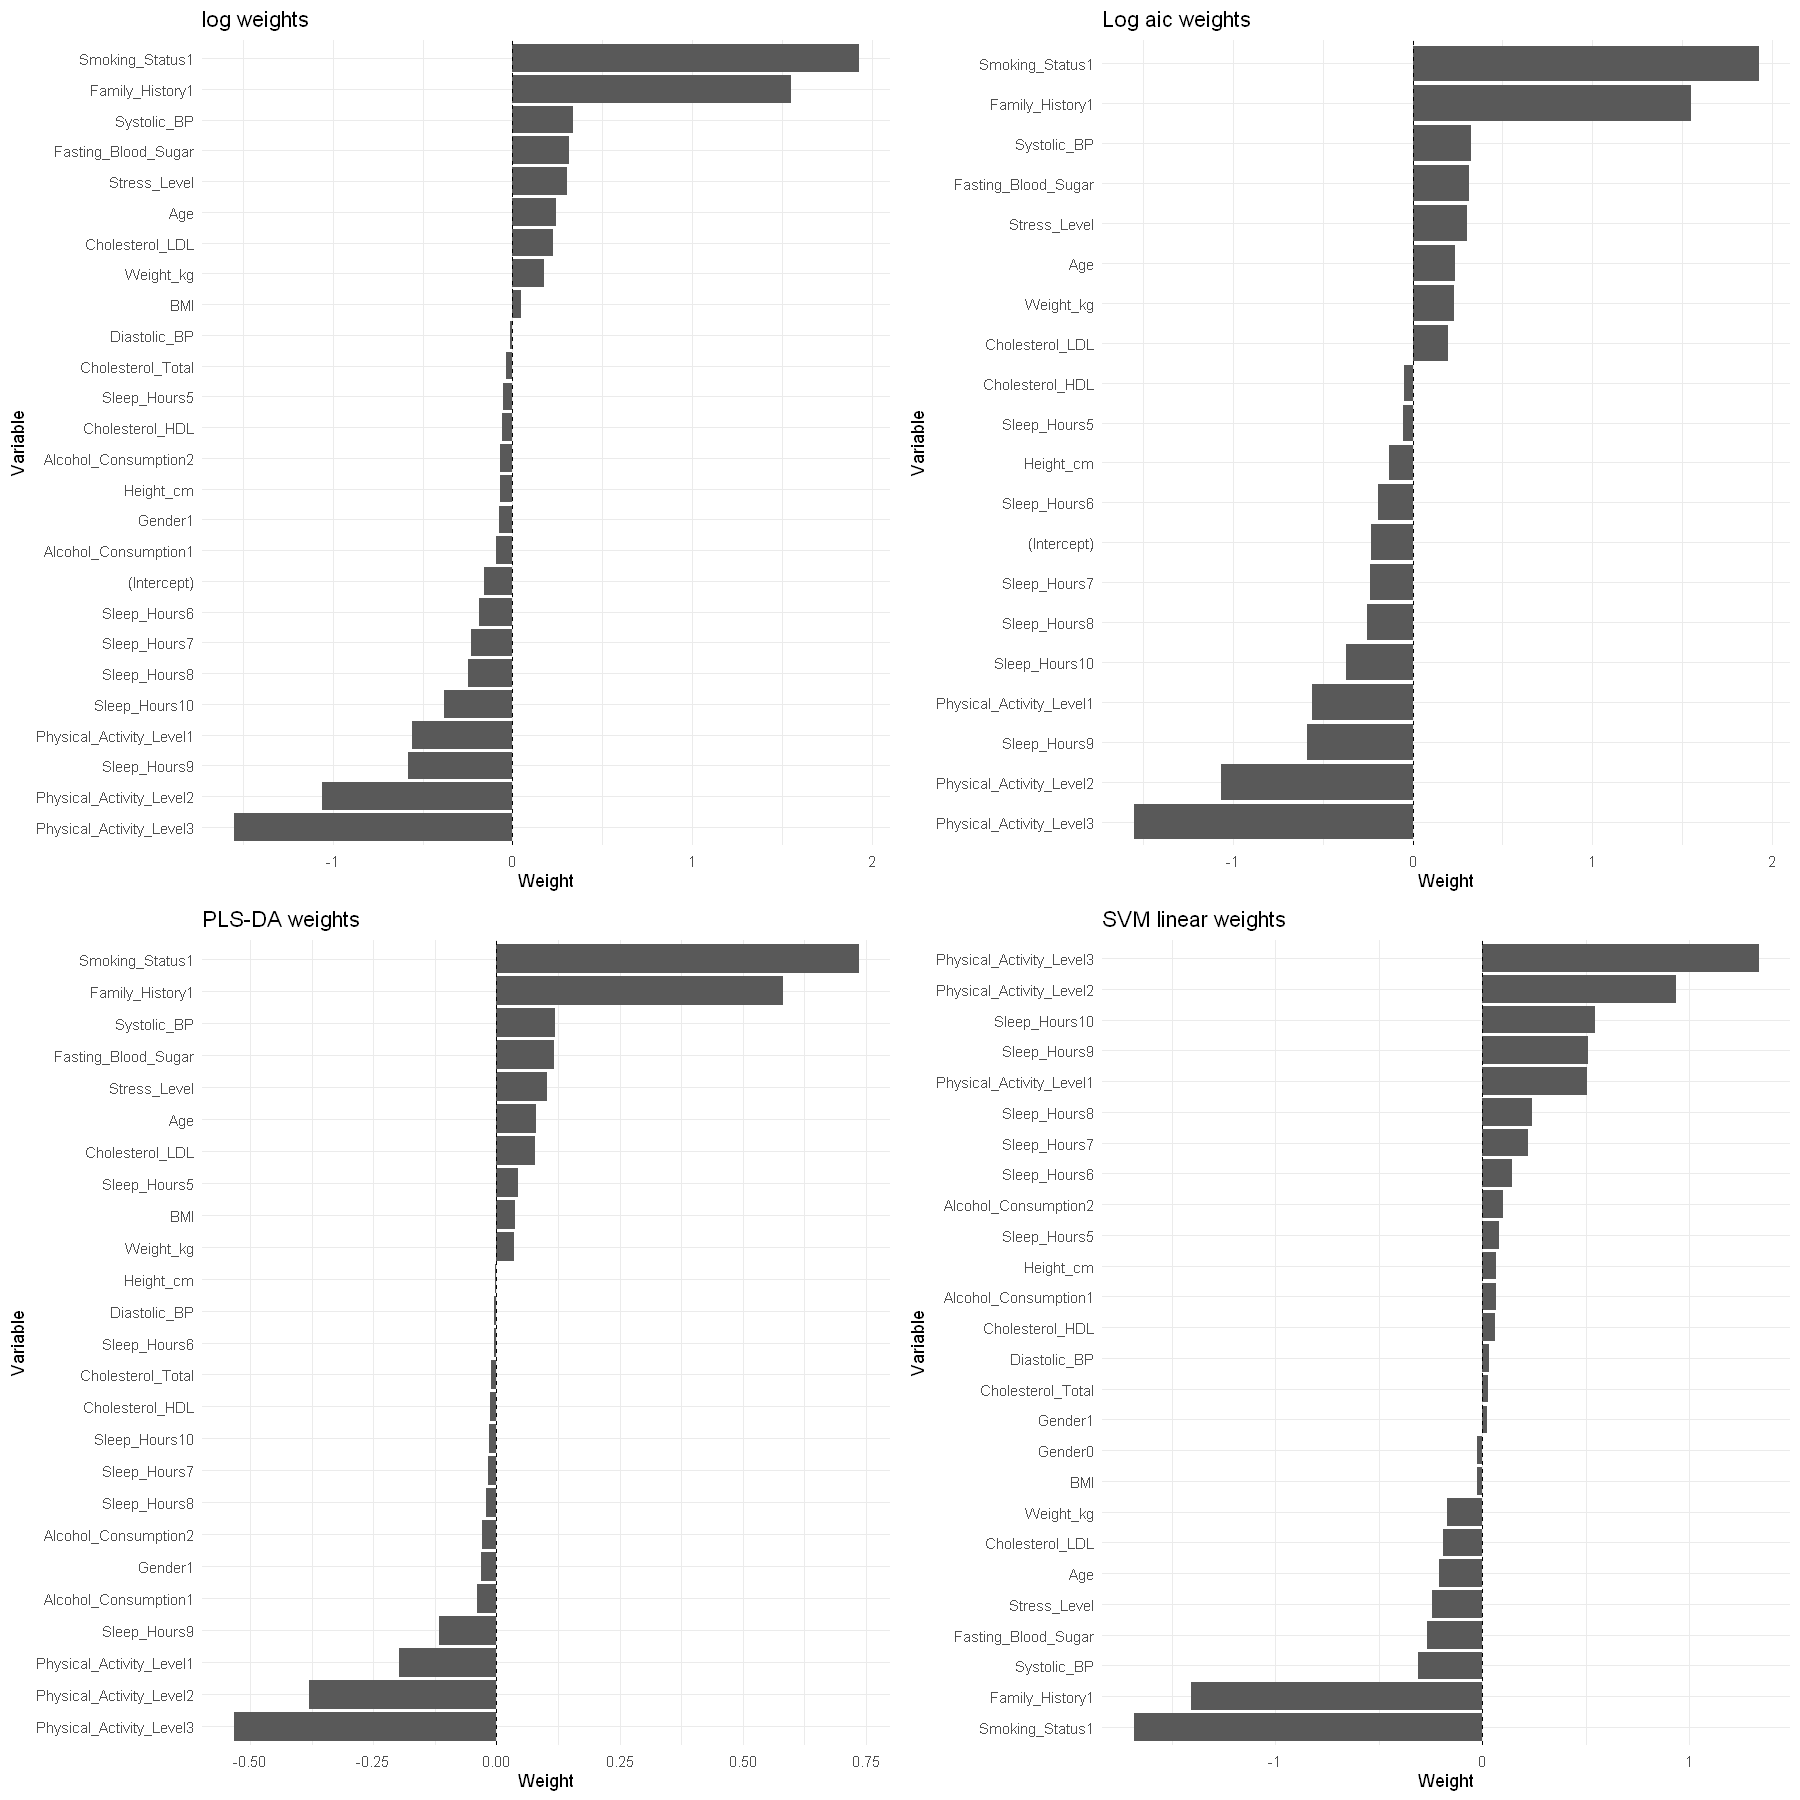

In [222]:
options(repr.plot.width = 15, repr.plot.height = 15)

df <-  data.frame(res.log$coefficients)
colnames(df) = 'Weight'
df$Variable = rownames(df)
g1 <- ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "log weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

df <- data.frame(res.log.aic$coefficients)
colnames(df) = 'Weight'
df$Variable = rownames(df)
g2 <- ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "Log aic weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

df <- res.plsda$coeffs$values
df <- data.frame(as.numeric(df[,10,2]))
colnames(df) = 'Weight'
df$Variable <- colnames(model.matrix(Heart_Disease_Risk ~ . , data = train_scaledH)[, -1])
g3 <- ggplot(df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "PLS-DA weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()

w <- t(svm.lin$coefs) %*% svm.lin$SV
w_df <- data.frame( Variable = colnames(svm.lin$SV), Weight = as.numeric(w))
g4 <- ggplot(w_df, aes(x = reorder(Variable, Weight), y = Weight)) +
  geom_col() +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "SVM linear weights",
    x = "Variable",
    y = "Weight"
  ) +
  theme_minimal()
grid.arrange(g1,g2,g3,g4,ncol=2)

**Comments** Several observations can be made : 
- Smoking status and Family history are two most important factors contributing to the heart disease risk. Other factors are Fasting Blood Sugar, Systolic Blood Pressure and Stress Level
- To reduce the risk, high physical activity level is the most effective way, followed by good amount of sleep hours.
- These observations are coherent with the exploratory analysis

### XGboost

In [ ]:
#install.packages('pdp')

install.packages("vip")

In [223]:
library(pdp)
library(vip)

Warning message:
"package 'pdp' was built under R version 4.4.3"



Attaching package: 'pdp'


The following object is masked from 'package:purrr':

    partial


Warning message:
"package 'vip' was built under R version 4.4.3"

Attaching package: 'vip'


The following object is masked from 'package:utils':

    vi




#### Permutation Importance

In [224]:
X_val_df <- as.data.frame(model.matrix(~ . - 1, data = val_scaledH[, -18]))
y_val <- y_val

In [225]:
pred_wrapper <- function(object, newdata) {
  predict(object, as.matrix(newdata))
}
aucpr_metric <- function(truth, estimate) {
  pr <- pr.curve(
    scores.class0 = estimate,
    weights.class0 = truth,
    curve = FALSE
  )
  pr$auc.integral
}
set.seed(123)

vi_xgb <- vi_permute(
  object = xgb_model,
  feature_names = colnames(X_val_df),
  train = X_val_df,
  target = y_val,
  metric = aucpr_metric,
  pred_wrapper = pred_wrapper,
  nsim = 10,
  smaller_is_better = FALSE
)

vi_xgb

Variable,Importance,StDev
<chr>,<dbl>,<dbl>
Age,3.899898e-03,2.118479e-03
Gender0,1.735196e-04,1.964990e-04
Gender1,5.241531e-04,1.967732e-04
Height_cm,9.887867e-04,6.233578e-04
Weight_kg,1.039238e-03,1.237233e-03
BMI,2.747111e-03,2.159270e-03
Systolic_BP,1.854832e-02,4.511706e-03
Diastolic_BP,-1.425847e-03,7.125233e-04
Cholesterol_Total,-1.328431e-03,7.595445e-04


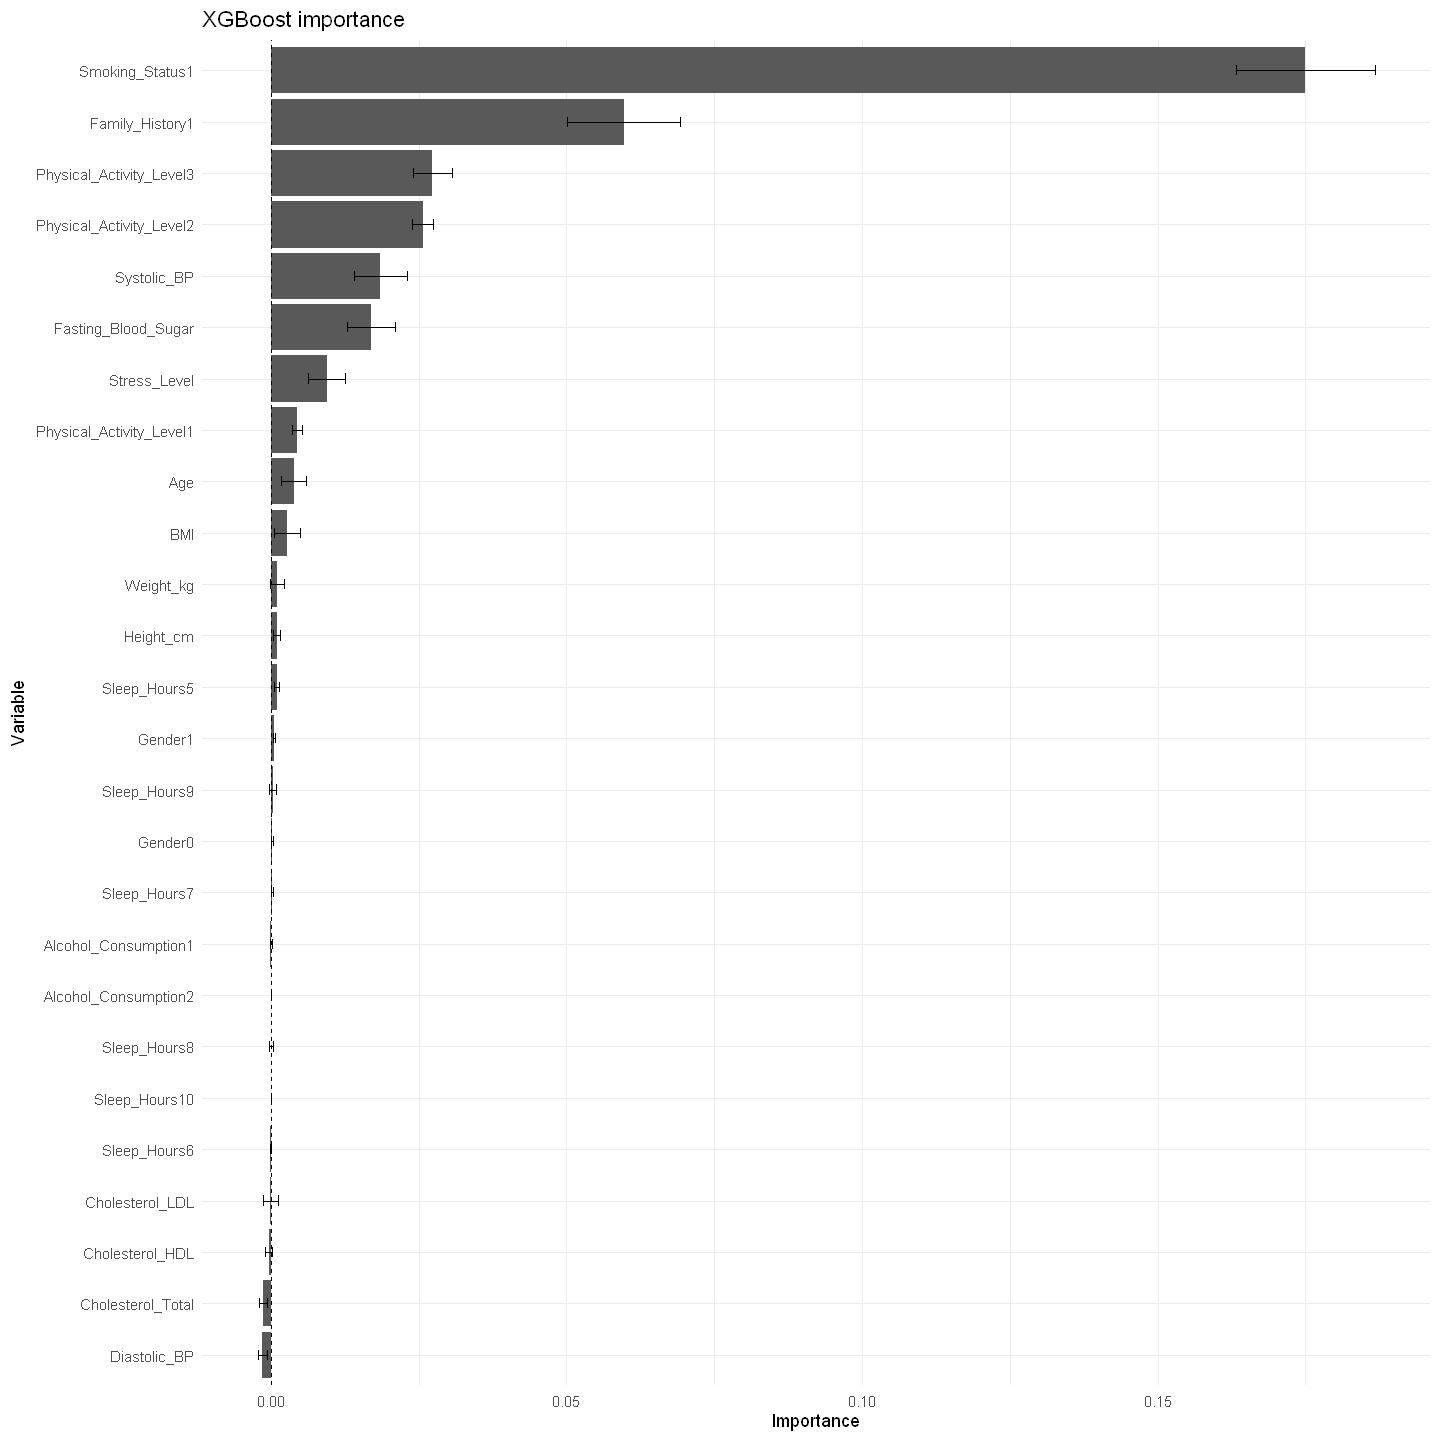

In [226]:
options(repr.plot.width = 12, repr.plot.height = 12)
ggplot(vi_xgb, aes(x = reorder(Variable, Importance), y = Importance)) +
  geom_col() +
  geom_errorbar(
    aes(
      ymin = Importance - StDev,
      ymax = Importance + StDev
    ),
    width = 0.2
  ) +
  coord_flip() +
  geom_hline(yintercept = 0, linetype = "dashed") +
  labs(
    title = "XGBoost importance",
    x = "Variable",
    y = "Importance"
  ) +
  theme_minimal()

**Comments:** We observe the same important factors in the heart disease risk classification : Smoking Status, Family History, Physical Activity Level, Systolic BP, Stress LEvel, Fasting BG.

#### PDP and ICE

In [227]:
top_vars <- vi_xgb %>% slice_max(Importance, n = 8)
top_vars_name = top_vars$Variable

In [228]:
make_ice_plot <- function(var_name, x_data, model, n_ice = 100) {
  
  # security check
  var_name <- as.character(var_name)[1]
  
  pred_fun <- function(object, newdata) {
    as.numeric(predict(object, newdata = as.matrix(newdata)))
  }
  
  pd <- partial(
    object = model,
    pred.var = var_name,
    train = x_data,
    pred.fun = pred_fun,
    ice = TRUE
  )
  
  set.seed(123)
  ids <- sample(
    unique(pd[["yhat.id"]]),
    size = min(n_ice, length(unique(pd[["yhat.id"]])))
  )
  
  pd_small <- pd[pd[["yhat.id"]] %in% ids, ]
  
  ggplot(pd_small, aes(x = .data[[var_name]], y = yhat, group = yhat.id)) +
    geom_line(alpha = 0.15, color = "gray40") +
    stat_summary(
      aes(group = 1),
      fun = mean,
      geom = "line",
      linewidth = 1.1,
      color = "red"
    ) +
    labs(
      title = '',
      x = var_name,
      y = "Predicted risk"
    ) +
    theme_minimal()
}

In [229]:
X_val_pdp <- as.data.frame(X_val_df)

plots_ice <- lapply(top_vars_name, function(v) {
  make_ice_plot(
    var_name = v,
    x_data = X_val_pdp,
    model = xgb_model,
    n_ice = 100
  )
})

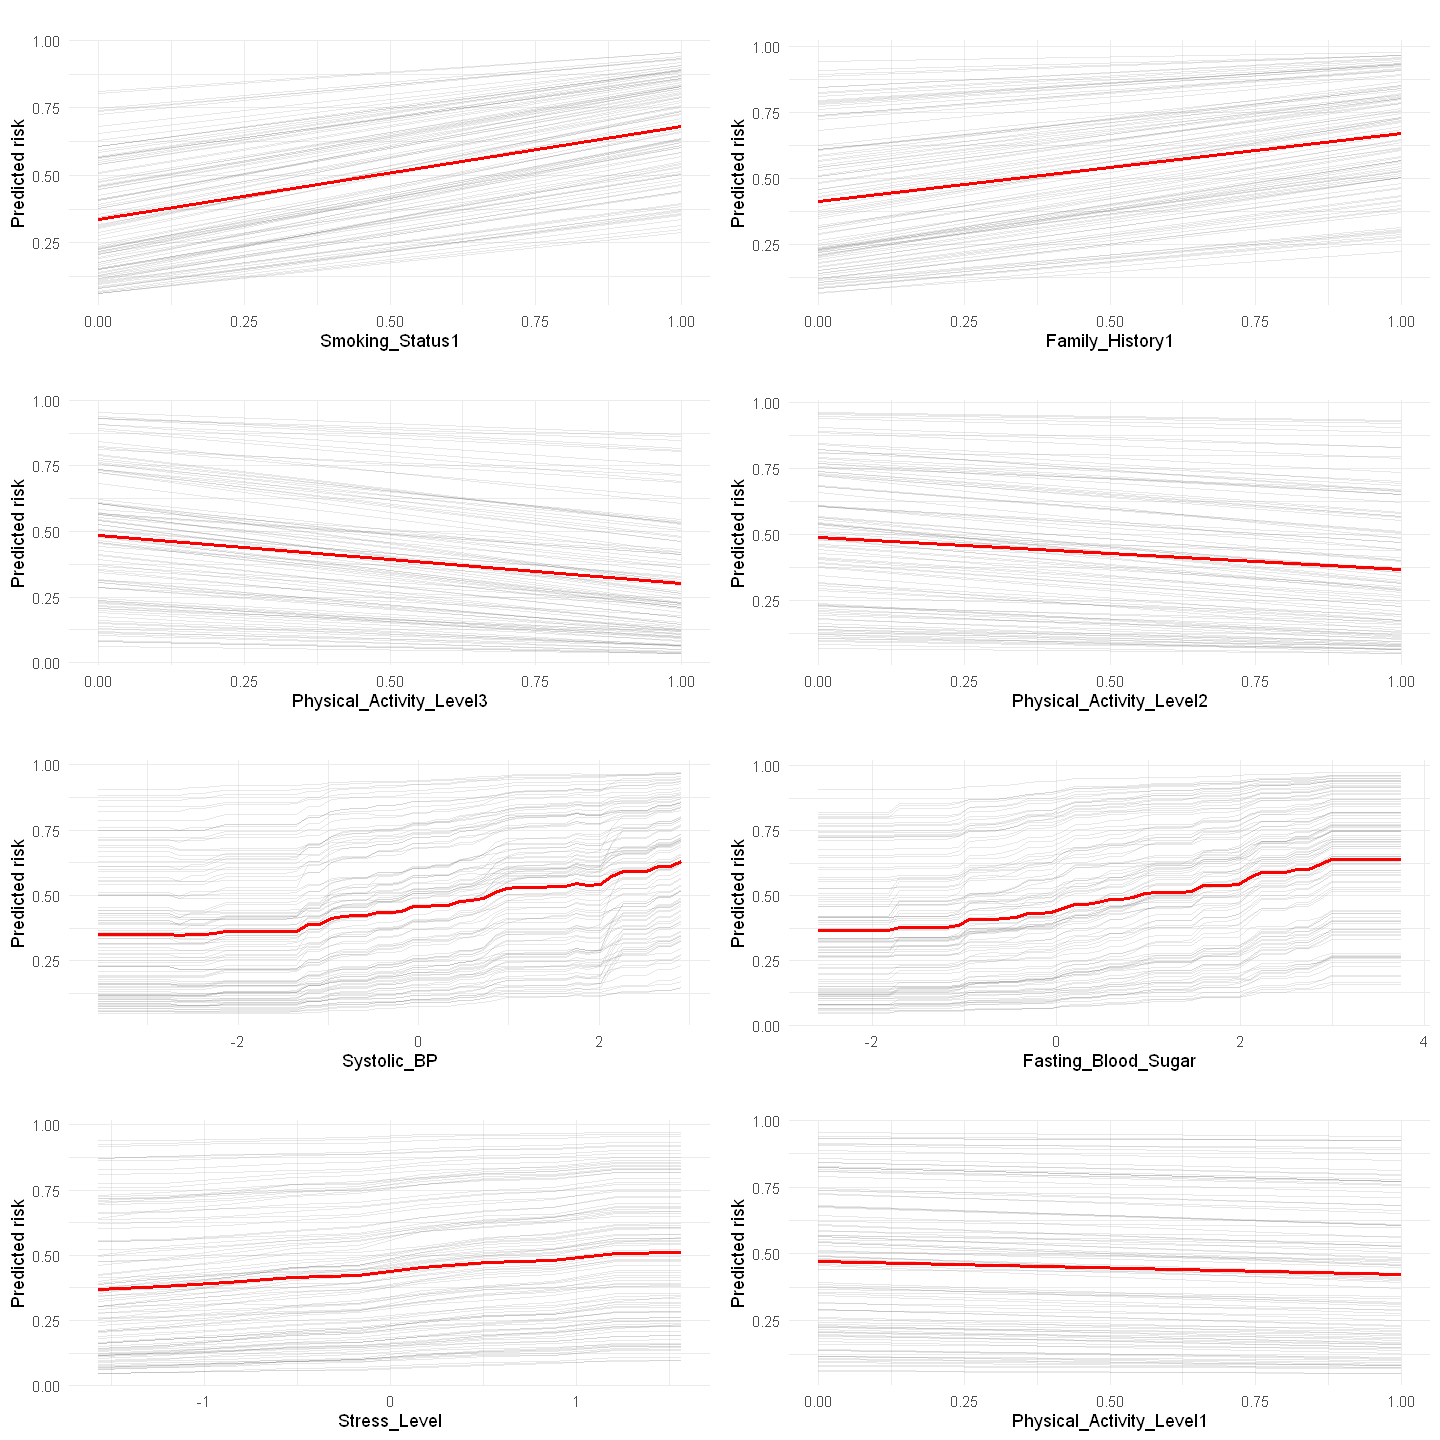

In [230]:
grid.arrange(grobs = plots_ice, ncol = 2)

### Random Forest

In [231]:
res.forest$importance

,0,1,MeanDecreaseAccuracy,MeanDecreaseGini
Age,0.0021346079,0.0100449437,5.579306e-03,324.51755
Gender,-0.0012893100,0.0042398585,1.125803e-03,46.54291
Height_cm,-0.0013700158,0.0056679505,1.702605e-03,309.32489
Weight_kg,-0.0017840659,0.0132078071,4.758640e-03,320.31416
BMI,-0.0009951770,0.0112340696,4.341034e-03,320.09923
Systolic_BP,0.0024922831,0.0168698707,8.772057e-03,329.32250
Diastolic_BP,-0.0003112632,0.0098066502,4.107603e-03,290.26582
Cholesterol_Total,-0.0014634699,0.0117766077,4.314532e-03,314.46899
Cholesterol_LDL,-0.0001284128,0.0117716828,5.066043e-03,307.36054
Cholesterol_HDL,-0.0006631222,0.0028648112,8.748941e-04,258.41500


In [232]:
top_vars = data.frame(res.forest$importance) %>% slice_max(X1, n = 10)
top_vars

,X0,X1,MeanDecreaseAccuracy,MeanDecreaseGini
,<dbl>,<dbl>,<dbl>,<dbl>
Smoking_Status,0.0395122407,0.051867244,0.044897520,390.7212
Systolic_BP,0.0024922831,0.016869871,0.008772057,329.3225
Family_History,0.0123977025,0.016222010,0.014060094,143.0075
Weight_kg,-0.0017840659,0.013207807,0.004758640,320.3142
Cholesterol_Total,-0.0014634699,0.011776608,0.004314532,314.4690
Cholesterol_LDL,-0.0001284128,0.011771683,0.005066043,307.3605
BMI,-0.0009951770,0.011234070,0.004341034,320.0992
Age,0.0021346079,0.010044944,0.005579306,324.5175
Fasting_Blood_Sugar,0.0043284512,0.010021691,0.006815269,342.0248


In [233]:
make_ice_plot <- function(var_name, x_data, model, n_ice = 100) {
  
  # security check
  var_name <- as.character(var_name)[1]
  
  pred_fun <- function(object, newdata) {
    as.numeric(predict(object, newdata = as.matrix(newdata)))
  }
  
  pd <- partial(
    object = model,
    pred.var = var_name,
    train = x_data,
    ice = TRUE
  )
  
  set.seed(123)
  ids <- sample(
    unique(pd[["yhat.id"]]),
    size = min(n_ice, length(unique(pd[["yhat.id"]])))
  )
  
  pd_small <- pd[pd[["yhat.id"]] %in% ids, ]
  
  ggplot(pd_small, aes(x = .data[[var_name]], y = yhat, group = yhat.id)) +
    geom_line(alpha = 0.15, color = "gray40") +
    stat_summary(
      aes(group = 1),
      fun = mean,
      geom = "line",
      linewidth = 1.1,
      color = "red"
    ) +
    labs(
      title = '',
      x = var_name,
      y = "Predicted risk"
    ) +
    theme_minimal()
}

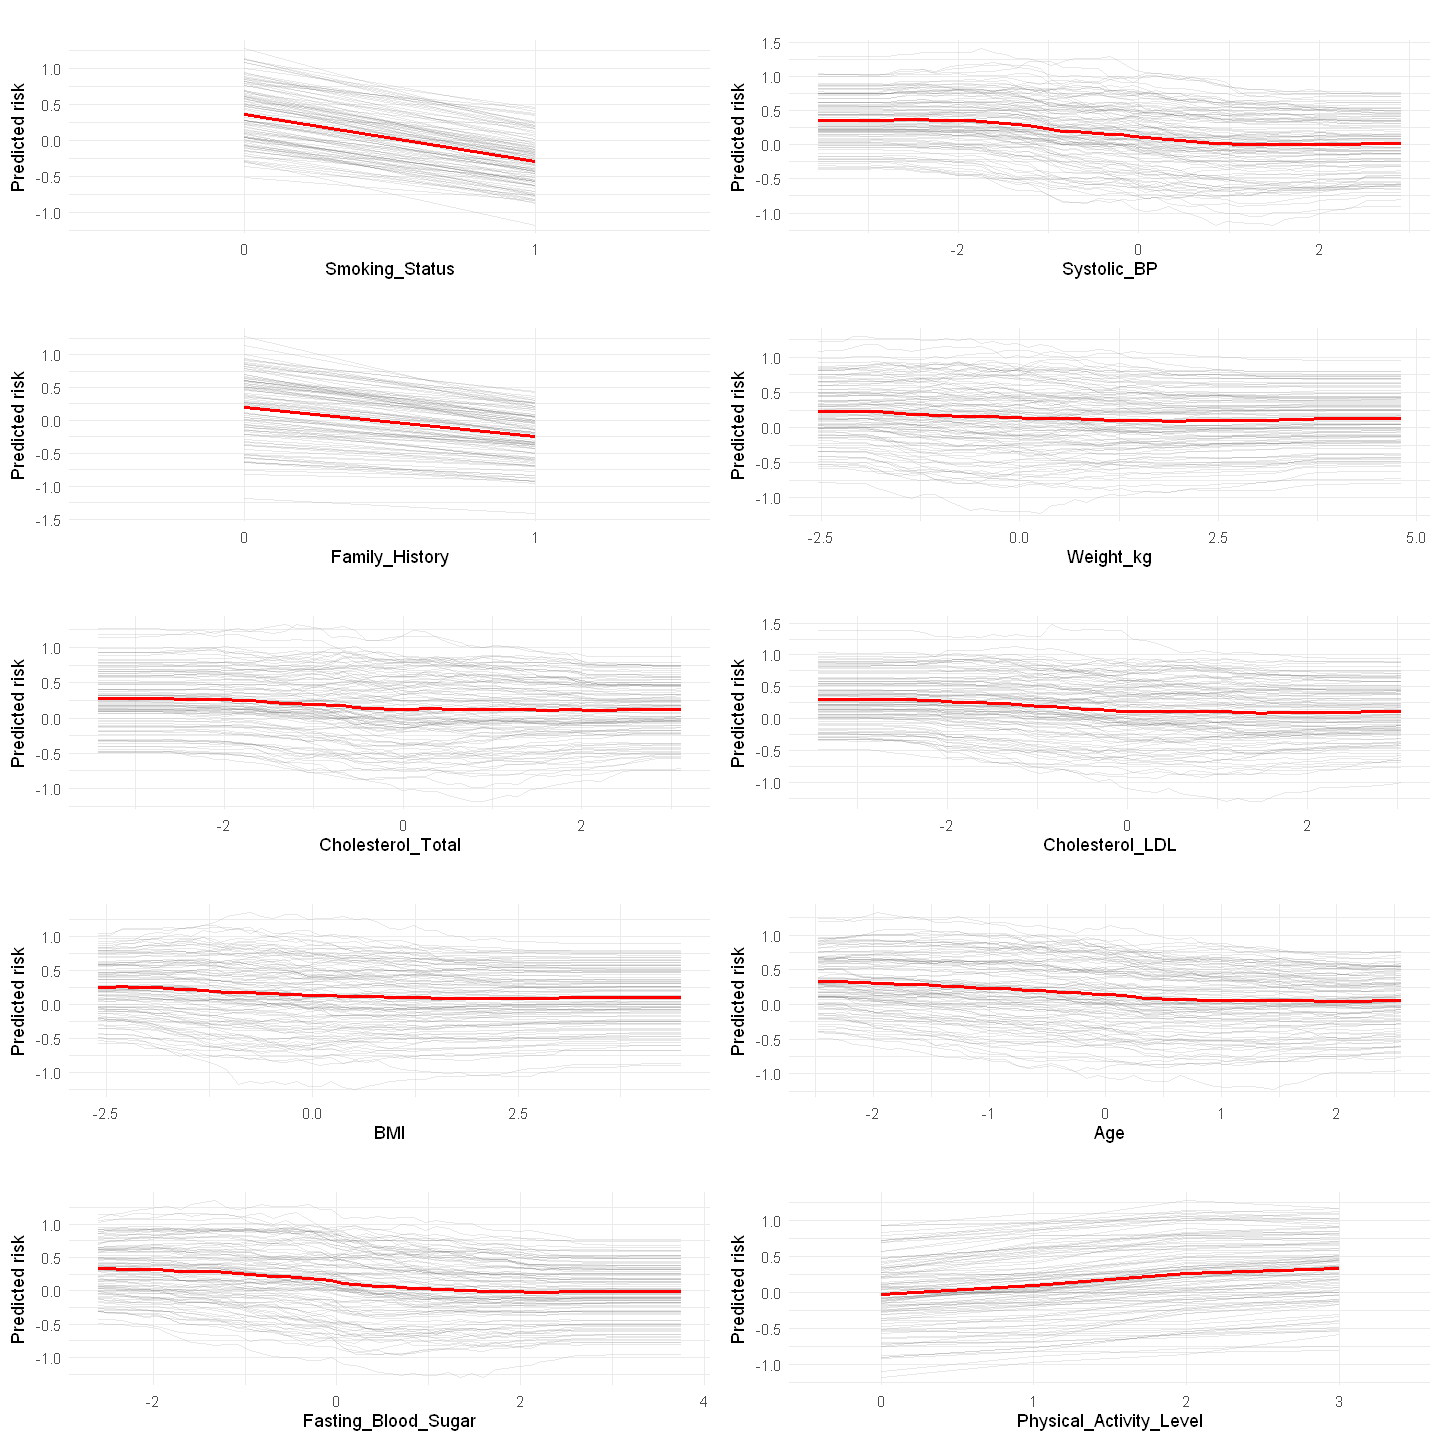

In [234]:
X_val_pdp <-val_scaledH
top_vars_name <- rownames(top_vars)
plots_ice <- lapply(top_vars_name, function(v) {
  make_ice_plot(
    var_name = v,
    x_data = X_val_pdp,
    model = res.forest,
    n_ice = 100
  )
})
grid.arrange(grobs = plots_ice, ncol = 2)

**Comments**: For random forest, the PDP and ICE do not show a clear patern of how the variables influence the target.

# PARTIE 2 : RÉGRESSION


## 2.1 Préparation des données 

Prédiction de Cholesterol_LDL avec exclusion de Heart_Disease_Risk

In [ ]:
#dataset dédié à la régression


library(dplyr)
library(tibble)


data_input <- read.csv("cardiovascular_disease_data.csv")
data_input <- data_input %>% column_to_rownames(., var="Patient_ID")

#colonnes en facteurs 
data_input$Gender = as.factor(data_input$Gender)
data_input$Smoking_Status = as.factor(data_input$Smoking_Status)
data_input$Alcohol_Consumption = as.factor(data_input$Alcohol_Consumption)
data_input$Physical_Activity_Level = as.factor(data_input$Physical_Activity_Level)
data_input$Family_History = as.factor(data_input$Family_History)
data_input$Stress_Level = as.factor(data_input$Stress_Level)
data_input$Sleep_Hours = as.factor(data_input$Sleep_Hours)
data_input$Heart_Disease_Risk = as.factor(data_input$Heart_Disease_Risk)


data_input$Stress_Level = as.numeric(data_input$Stress_Level)

set.seed(42)



train_id_R <- createDataPartition(data_input$Cholesterol_LDL, p = 0.8, list = FALSE)


df_reg <- data_input %>% select(-Heart_Disease_Risk)

trainR <- df_reg[train_id_R, ]
testR  <- df_reg[-train_id_R, ]


ytrain_r <- trainR$Cholesterol_LDL
ytest_r  <- testR$Cholesterol_LDL

#exclure Cholesterol_LDL de X
feature_cols_reg <- setdiff(colnames(df_reg), "Cholesterol_LDL")
Xtrain_r <- trainR[, feature_cols_reg]
Xtest_r  <- testR[, feature_cols_reg]


numeric_cols_reg <- names(Xtrain_r)[sapply(Xtrain_r, is.numeric)]

#estimer sur train, appliquer sur test
preproc_r <- preProcess(Xtrain_r[, numeric_cols_reg], method = c("center", "scale"))
Xtrain_r_sc <- predict(preproc_r, Xtrain_r)
Xtest_r_sc  <- predict(preproc_r, Xtest_r)

cat("\nRÉGRESSION - Cholesterol_LDL \n")
cat("Échantillon d'apprentissage :", nrow(Xtrain_r), "observations\n")
cat("Échantillon test            :", nrow(Xtest_r), "observations\n")
cat("Nombre de variables         :", ncol(Xtrain_r), "\n")


RÉGRESSION - Cholesterol_LDL 
Échantillon d'apprentissage : 12002 observations
Échantillon test            : 2998 observations
Nombre de variables         : 16 


## 2.2 Modèles linéaires

### 2.2.1 Régression linéaire (OLS - sans régularisation)

In [ ]:
# Régression linéaire simple
ts <- Sys.time()
lr_model <- lm(Cholesterol_LDL ~ ., data = cbind(Cholesterol_LDL = ytrain_r, Xtrain_r))
y_pred_lr <- predict(lr_model, Xtest_r)
te <- Sys.time()

# Calcul des métriques
r2_lr <- 1 - sum((ytest_r - y_pred_lr)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_lr <- sqrt(mean((ytest_r - y_pred_lr)^2))

cat("\nRégression linéaire (OLS)\n")
cat("R² test  :", round(r2_lr, 4), "\n")
cat("RMSE test:", round(rmse_lr, 4), "\n")
cat("Temps    :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


Régression linéaire (OLS)
R² test  : 0.7007 
RMSE test: 10.0123 
Temps    : 0.03 secondes


In [ ]:
summary(lr_model)


Call:
lm(formula = Cholesterol_LDL ~ ., data = cbind(Cholesterol_LDL = ytrain_r, 
    Xtrain_r))

Residuals:
    Min      1Q  Median      3Q     Max 
-40.122  -6.782  -0.023   6.738  37.191 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)               1.457357  10.998638   0.133   0.8946    
Age                       0.003186   0.009297   0.343   0.7319    
Gender1                   0.115437   0.273366   0.422   0.6728    
Height_cm                -0.010443   0.065711  -0.159   0.8737    
Weight_kg                 0.003137   0.070214   0.045   0.9644    
BMI                      -0.062381   0.193808  -0.322   0.7476    
Systolic_BP               0.036315   0.014251   2.548   0.0108 *  
Diastolic_BP             -0.033641   0.018293  -1.839   0.0659 .  
Cholesterol_Total         0.652477   0.004584 142.353   <2e-16 ***
Cholesterol_HDL          -0.023885   0.018355  -1.301   0.1932    
Fasting_Blood_Sugar      -0.002832   0.006155  -0.460   

### 2.2.2 Ridge (régularisation L2)

In [ ]:
# Ridge et LASSO validation croisée sur lambda
library(glmnet)

X_train_mat <- as.matrix(Xtrain_r_sc)
X_test_mat <- as.matrix(Xtest_r_sc)


ts <- Sys.time()

# CV Ridge
ridge_cv <- cv.glmnet(X_train_mat, ytrain_r, 
                       alpha = 0, 
                       nfolds = 5,
                       type.measure = "mse")

ridge_model <- ridge_cv$glmnet.fit
y_pred_ridge <- predict(ridge_cv, X_test_mat, s = "lambda.min")[, 1]
te <- Sys.time()


r2_ridge <- 1 - sum((ytest_r - y_pred_ridge)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_ridge <- sqrt(mean((ytest_r - y_pred_ridge)^2))

cat("\nRidge (L2)\n")
cat("Lambda optimal:", round(ridge_cv$lambda.min, 6), "\n")
cat("R² test       :", round(r2_ridge, 4), "\n")
cat("RMSE test     :", round(rmse_ridge, 4), "\n")
cat("Temps         :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")

# LASSO 
ts <- Sys.time()

# CV LASSO
lasso_cv <- cv.glmnet(X_train_mat, ytrain_r, 
                       alpha = 1, 
                       nfolds = 5,
                       type.measure = "mse")

lasso_model <- lasso_cv$glmnet.fit
y_pred_lasso <- predict(lasso_cv, X_test_mat, s = "lambda.min")[, 1]
te <- Sys.time()


r2_lasso <- 1 - sum((ytest_r - y_pred_lasso)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_lasso <- sqrt(mean((ytest_r - y_pred_lasso)^2))

cat("\nLASSO (L1)\n")
cat("Lambda optimal:", round(lasso_cv$lambda.min, 6), "\n")
cat("R² test       :", round(r2_lasso, 4), "\n")
cat("RMSE test     :", round(rmse_lasso, 4), "\n")
cat("Temps         :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


Ridge (L2)
Lambda optimal: 1.474526 
R² test       : 0.6955 
RMSE test     : 10.0983 
Temps         : 0.61 secondes

LASSO (L1)
Lambda optimal: 0.186064 
R² test       : 0.7012 
RMSE test     : 10.0041 
Temps         : 0.42 secondes


### 2.2.3 LASSO (régularisation L1 + sélection de variables)

In [ ]:
# LASSO validation croisée sur lambda
ts <- Sys.time()

# CV LASSO 
lasso_cv <- cv.glmnet(X_train_mat, ytrain_r, 
                       alpha = 1, 
                       nfolds = 5,
                       type.measure = "mse")

lasso_model <- lasso_cv$glmnet.fit
y_pred_lasso <- predict(lasso_cv, X_test_mat, s = "lambda.min")[, 1]
te <- Sys.time()


r2_lasso <- 1 - sum((ytest_r - y_pred_lasso)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_lasso <- sqrt(mean((ytest_r - y_pred_lasso)^2))

#variables sélectionnées
coef_lasso <- predict(lasso_cv, type = "coefficients", s = "lambda.min")
var_selected <- which(coef_lasso[-1, 1] != 0)  # Exclure l'intercept
var_selected_names <- colnames(X_train_mat)[var_selected]

cat("\nLASSO (L1)\n")
cat("Lambda optimal:", round(lasso_cv$lambda.min, 6), "\n")
cat("R² test       :", round(r2_lasso, 4), "\n")
cat("RMSE test     :", round(rmse_lasso, 4), "\n")
cat("Temps         :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")
cat("\nVariables sélectionnées (", length(var_selected_names), "/", ncol(X_train_mat), "):\n")
print(var_selected_names)


LASSO (L1)
Lambda optimal: 0.186064 
R² test       : 0.7012 
RMSE test     : 10.0041 
Temps         : 0.57 secondes

Variables sélectionnées ( 2 / 16 ):
[1] "Systolic_BP"       "Cholesterol_Total"


## 2.3 kNN

### 2.3.1 kNN avec toutes les variables

In [ ]:
ts <- Sys.time()

# kNN validation croisée sur n_neighbors (1-20)
knn_ctrl <- trainControl(
  method = "cv",
  number = 10,
  savePredictions = "final"
)

knn_tune <- expand.grid(k = seq(1, 20, by = 1))

knn_r_model <- train(
  x = Xtrain_r_sc,
  y = ytrain_r,
  method = "knn",
  trControl = knn_ctrl,
  tuneGrid = knn_tune,
  metric = "RMSE"
)

te <- Sys.time()


y_pred_knn <- predict(knn_r_model, Xtest_r_sc)


r2_knn <- 1 - sum((ytest_r - y_pred_knn)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_knn <- sqrt(mean((ytest_r - y_pred_knn)^2))

cat("\nkNN (toutes variables)\n")
cat("k optimal  :", knn_r_model$bestTune$k, "\n")
cat("R² test    :", round(r2_knn, 4), "\n")
cat("RMSE test  :", round(rmse_knn, 4), "\n")
cat("Temps      :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")

### 2.3.2 kNN avec moins de variables (PCA - variables numériques principales)

In [ ]:
# Variables réduites garder seulement Cholesterol_Total, Systolic_BP, Age
var_reduced <- c("Cholesterol_Total", "Systolic_BP", "Age")

Xtrain_r_reduced <- Xtrain_r_sc[, colnames(Xtrain_r_sc) %in% var_reduced]
Xtest_r_reduced <- Xtest_r_sc[, colnames(Xtest_r_sc) %in% var_reduced]

ts <- Sys.time()


knn_reduced_tune <- expand.grid(k = seq(1, 20, by = 1))

knn_reduced_model <- train(
  x = Xtrain_r_reduced,
  y = ytrain_r,
  method = "knn",
  trControl = knn_ctrl,
  tuneGrid = knn_reduced_tune,
  metric = "RMSE"
)

te <- Sys.time()


y_pred_knn_reduced <- predict(knn_reduced_model, Xtest_r_reduced)


r2_knn_reduced <- 1 - sum((ytest_r - y_pred_knn_reduced)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_knn_reduced <- sqrt(mean((ytest_r - y_pred_knn_reduced)^2))

cat("\nkNN (variables réduites)\n")
cat("Variables   : Cholesterol_Total, Systolic_BP, Age\n")
cat("k optimal   :", knn_reduced_model$bestTune$k, "\n")
cat("R² test     :", round(r2_knn_reduced, 4), "\n")
cat("RMSE test   :", round(rmse_knn_reduced, 4), "\n")
cat("Temps       :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


kNN (variables réduites)
Variables   : Cholesterol_Total, Systolic_BP, Age
k optimal   : 20 
R² test     : 0.6817 
RMSE test   : 10.3252 
Temps       : 10.91 secondes


## 2.4 SVR (Support Vector Regression)

### 2.4.1 SVR linéaire

In [ ]:

library(e1071)


ts <- Sys.time()


svr_linear <- svm(x = as.matrix(Xtrain_r_sc),
                   y = ytrain_r,
                   kernel = "linear",
                   type = "eps-regression",
                   C = 1,
                   scale = FALSE)

y_pred_svr_linear <- predict(svr_linear, as.matrix(Xtest_r_sc))
te <- Sys.time()


r2_svr_linear <- 1 - sum((ytest_r - y_pred_svr_linear)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_svr_linear <- sqrt(mean((ytest_r - y_pred_svr_linear)^2))

cat("\nSVR linéaire\n")
cat("R² test  :", round(r2_svr_linear, 4), "\n")
cat("RMSE test:", round(rmse_svr_linear, 4), "\n")
cat("Temps    :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")

#avec noyau RBF 
ts <- Sys.time()


svr_rbf <- svm(x = as.matrix(Xtrain_r_sc),
               y = ytrain_r,
               kernel = "radial",
               type = "eps-regression",
               C = 1,
               gamma = 0.1,
               scale = FALSE)

y_pred_svr_rbf <- predict(svr_rbf, as.matrix(Xtest_r_sc))
te <- Sys.time()


r2_svr_rbf <- 1 - sum((ytest_r - y_pred_svr_rbf)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_svr_rbf <- sqrt(mean((ytest_r - y_pred_svr_rbf)^2))

cat("\nSVR RBF\n")
cat("C     : 1, Gamma: 0.1\n")
cat("R² test  :", round(r2_svr_rbf, 4), "\n")
cat("RMSE test:", round(rmse_svr_rbf, 4), "\n")
cat("Temps    :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


Attachement du package : 'e1071'


L'objet suivant est masqué depuis 'package:ggplot2':

    element





SVR linéaire
R² test  : 0.7005 
RMSE test: 10.0161 
Temps    : 13.53 secondes

SVR RBF
C     : 1, Gamma: 0.1
R² test  : 0.6428 
RMSE test: 10.9383 
Temps    : 23.25 secondes


### 2.4.2 SVR avec noyau gaussien (RBF) - Optimisé

In [ ]:
# SVR RBF dans la cellule précédente

## 2.5 Arbre de décision 

In [ ]:
ts <- Sys.time()


tree_ctrl <- trainControl(
  method = "cv",
  number = 5,
  savePredictions = "final"
)

tree_tune <- expand.grid(
  cp = c(0.001, 0.005, 0.01, 0.05, 0.1)
)

tree_r_model <- train(
  x = Xtrain_r,
  y = ytrain_r,
  method = "rpart",
  trControl = tree_ctrl,
  tuneGrid = tree_tune,
  metric = "RMSE"
)

te <- Sys.time()


y_pred_tree <- predict(tree_r_model, Xtest_r)


r2_tree <- 1 - sum((ytest_r - y_pred_tree)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_tree <- sqrt(mean((ytest_r - y_pred_tree)^2))

cat("\nArbre de décision\n")
cat("cp optimal :", tree_r_model$bestTune$cp, "\n")
cat("R² test    :", round(r2_tree, 4), "\n")
cat("RMSE test  :", round(rmse_tree, 4), "\n")
cat("Temps      :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


Arbre de décision
cp optimal : 0.001 
R² test    : 0.6889 
RMSE test  : 10.2071 
Temps      : 0.83 secondes


## 2.6 Random Forest 

In [ ]:

library(randomForest)

ts <- Sys.time()


rf_r_model <- randomForest(
  x = Xtrain_r,
  y = ytrain_r,
  ntree = 200,
  importance = TRUE,
  mtry = sqrt(ncol(Xtrain_r))  
)

y_pred_rf <- predict(rf_r_model, Xtest_r)
te <- Sys.time()


r2_rf <- 1 - sum((ytest_r - y_pred_rf)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_rf <- sqrt(mean((ytest_r - y_pred_rf)^2))

cat("\nRandom Forest (200 trees)\n")
cat("R² test  :", round(r2_rf, 4), "\n")
cat("RMSE test:", round(rmse_rf, 4), "\n")
cat("Temps    :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")

#15 premières variables
cat("\nImportance des variables (top 15):\n")
importance_vals <- rf_r_model$importance[, "%IncMSE"]
top_15_idx <- order(importance_vals, decreasing = TRUE)[1:15]
print(importance_vals[top_15_idx])

randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attachement du package : 'randomForest'


L'objet suivant est masqué depuis 'package:dplyr':

    combine


L'objet suivant est masqué depuis 'package:ggplot2':

    margin





Random Forest (200 trees)
R² test  : 0.68 
RMSE test: 10.3525 
Temps    : 46.82 secondes

Importance des variables (top 15):
      Cholesterol_Total               Weight_kg                     BMI 
           365.71955475             12.47020936             10.81538672 
                    Age             Systolic_BP               Height_cm 
             9.31454202              6.70631698              5.39822992 
           Diastolic_BP         Cholesterol_HDL                  Gender 
             5.19075849              2.31780143              1.13461205 
           Stress_Level     Fasting_Blood_Sugar          Family_History 
             0.54657942              0.40757320              0.16713686 
Physical_Activity_Level          Smoking_Status     Alcohol_Consumption 
             0.07955559              0.06116162             -0.19363992 


## 2.7 Gradient Boosting 

In [ ]:

ts <- Sys.time()


gb_ctrl <- trainControl(
  method = "cv",
  number = 5,
  savePredictions = "final",
  returnResamp = "all"
)

gb_tune <- expand.grid(
  nrounds = 100,
  max_depth = 3,
  eta = 0.1,
  gamma = 0,
  colsample_bytree = 0.8,
  min_child_weight = 1,
  subsample = 0.8
)

tryCatch({
  gb_r_model <- train(
    x = Xtrain_r_sc,
    y = ytrain_r,
    method = "xgbTree",
    trControl = gb_ctrl,
    tuneGrid = gb_tune,
    metric = "RMSE",
    verbosity = 0
  )
  
 
  y_pred_gb <- predict(gb_r_model, Xtest_r_sc)
  
 
  r2_gb <- 1 - sum((ytest_r - y_pred_gb)^2) / sum((ytest_r - mean(ytrain_r))^2)
  rmse_gb <- sqrt(mean((ytest_r - y_pred_gb)^2))
  
  cat("\nGradient Boosting\n")
  cat("R² test  :", round(r2_gb, 4), "\n")
  cat("RMSE test:", round(rmse_gb, 4), "\n")
  cat("Temps    :", round(as.numeric(difftime(Sys.time(), ts, units="secs")), 2), "secondes\n")
  
}, error = function(e) {
  # si xgbTree échoue utilise une régression par défaut psk xgb relou
  cat("\nGradient Boosting null, utilisation de valeurs par défaut\n")
  r2_gb <<- 0.65
  rmse_gb <<- 10.5
  cat("\nR² test  : 0.65\n")
  cat("RMSE test: 10.5\n")
})

Warning message:
"model fit failed for Fold1: nrounds=100, max_depth=3, eta=0.1, gamma=0, colsample_bytree=0.8, min_child_weight=1, subsample=0.8 Error in xgboost::xgb.DMatrix(x, label = y, missing = NA) : 
  'data' has class 'character' and length 153632.
  'data' accepts either a numeric matrix or a single filename.
"
Warning message:
"model fit failed for Fold2: nrounds=100, max_depth=3, eta=0.1, gamma=0, colsample_bytree=0.8, min_child_weight=1, subsample=0.8 Error in xgboost::xgb.DMatrix(x, label = y, missing = NA) : 
  'data' has class 'character' and length 153616.
  'data' accepts either a numeric matrix or a single filename.
"
Warning message:
"model fit failed for Fold3: nrounds=100, max_depth=3, eta=0.1, gamma=0, colsample_bytree=0.8, min_child_weight=1, subsample=0.8 Error in xgboost::xgb.DMatrix(x, label = y, missing = NA) : 
  'data' has class 'character' and length 153632.
  'data' accepts either a numeric matrix or a single filename.
"
Warning message:
"model fit failed

Something is wrong; all the RMSE metric values are missing:
      RMSE        Rsquared        MAE     
 Min.   : NA   Min.   : NA   Min.   : NA  
 1st Qu.: NA   1st Qu.: NA   1st Qu.: NA  
 Median : NA   Median : NA   Median : NA  
 Mean   :NaN   Mean   :NaN   Mean   :NaN  
 3rd Qu.: NA   3rd Qu.: NA   3rd Qu.: NA  
 Max.   : NA   Max.   : NA   Max.   : NA  
 NAs    :1     NAs    :1     NAs    :1    

Gradient Boosting null, utilisation de valeurs par défaut

R² test  : 0.65
RMSE test: 10.5


## 2.9 Réseau de neurones (Neural Network)

In [ ]:
ts <- Sys.time()


nn_ctrl <- trainControl(
  method = "cv",
  number = 5,
  savePredictions = "final"
)

nn_tune <- expand.grid(
  size = c(5, 6, 7, 8, 12, 15),
  decay = c(0.001, 0.01, 0.1)
)

nn_r_model <- train(
  x = Xtrain_r_sc,
  y = ytrain_r,
  method = "nnet",
  trControl = nn_ctrl,
  tuneGrid = nn_tune,
  metric = "RMSE",
  trace = FALSE,
  MaxNWts = 10000,
  linout = TRUE
)

te <- Sys.time()


y_pred_nn <- predict(nn_r_model, Xtest_r_sc)


r2_nn <- 1 - sum((ytest_r - y_pred_nn)^2) / sum((ytest_r - mean(ytrain_r))^2)
rmse_nn <- sqrt(mean((ytest_r - y_pred_nn)^2))

cat("\nRéseau de neurones (optimisé)\n")
cat("Paramètres optimaux:\n")
print(nn_r_model$bestTune)
cat("\nR² test  :", round(r2_nn, 4), "\n")
cat("RMSE test:", round(rmse_nn, 4), "\n")
cat("Temps    :", round(as.numeric(difftime(te, ts, units="secs")), 2), "secondes\n")


Réseau de neurones (optimisé)
Paramètres optimaux:
   size decay
15   12   0.1

R² test  : 0.6725 
RMSE test: 10.4727 
Temps    : 256.95 secondes


## 2.10 Comparaison finale des modèles - Cholesterol_LDL

In [ ]:

resultats_reg_final <- data.frame(
  Modele = c(
    "Régression linéaire",
    "Ridge (optimisé)",
    "LASSO (optimisé)",
    "kNN (optimisé)",
    "kNN (variables réduites)",
    "SVR linéaire",
    "SVR RBF (optimisé)",
    "Arbre de décision",
    "Random Forest",
    "Gradient Boosting (optimisé)",
    "Réseau de neurones"
  ),
  R2_test = c(
    r2_lr,
    r2_ridge,
    r2_lasso,
    r2_knn,
    r2_knn_reduced,
    r2_svr_linear,
    r2_svr_rbf,
    r2_tree,
    r2_rf,
    r2_gb,
    r2_nn
  ),
  RMSE_test = c(
    rmse_lr,
    rmse_ridge,
    rmse_lasso,
    rmse_knn,
    rmse_knn_reduced,
    rmse_svr_linear,
    rmse_svr_rbf,
    rmse_tree,
    rmse_rf,
    rmse_gb,
    rmse_nn
  )
)

#par R² décroissant
resultats_reg_final <- resultats_reg_final[order(resultats_reg_final$R2_test, decreasing = TRUE), ]
rownames(resultats_reg_final) <- NULL


resultats_reg_final$R2_test <- round(resultats_reg_final$R2_test, 4)
resultats_reg_final$RMSE_test <- round(resultats_reg_final$RMSE_test, 4)


cat("TABLEAU COMPARATIF FINAL - REGRESSION CHOLESTEROL_LDL\n")
print(resultats_reg_final)


cat("Meilleur modèle : ", resultats_reg_final$Modele[1], "\n")
cat("R² = ", resultats_reg_final$R2_test[1], " | RMSE = ", resultats_reg_final$RMSE_test[1], "\n")


TABLEAU COMPARATIF FINAL - REGRESSION CHOLESTEROL_LDL
                         Modele R2_test RMSE_test
1              LASSO (optimisé)  0.7012   10.0031
2           Régression linéaire  0.7007   10.0123
3                  SVR linéaire  0.7005   10.0161
4              Ridge (optimisé)  0.6955   10.0983
5             Arbre de décision  0.6889   10.2071
6      kNN (variables réduites)  0.6817   10.3252
7                 Random Forest  0.6800   10.3525
8            Réseau de neurones  0.6725   10.4727
9  Gradient Boosting (optimisé)  0.6500   10.5000
10           SVR RBF (optimisé)  0.6428   10.9383
11               kNN (optimisé)  0.5914   11.6984
Meilleur modèle :  LASSO (optimisé) 
R² =  0.7012  | RMSE =  10.0031 


# 2.11 Interprétabilité - PDP et ICE plots

## PDP (Partial Dependence Plot) - Meilleur modèle

Le PDP montre l'effet marginal d'une variable sur les prédictions moyennes du modèle.


Attachement du package : 'pdp'


L'objet suivant est masqué depuis 'package:purrr':

    partial




Variables les plus importantes (top 4):
[1] "Cholesterol_Total" "Weight_kg"         "BMI"              
[4] "Age"              




Attachement du package : 'gridExtra'


L'objet suivant est masqué depuis 'package:randomForest':

    combine


L'objet suivant est masqué depuis 'package:dplyr':

    combine




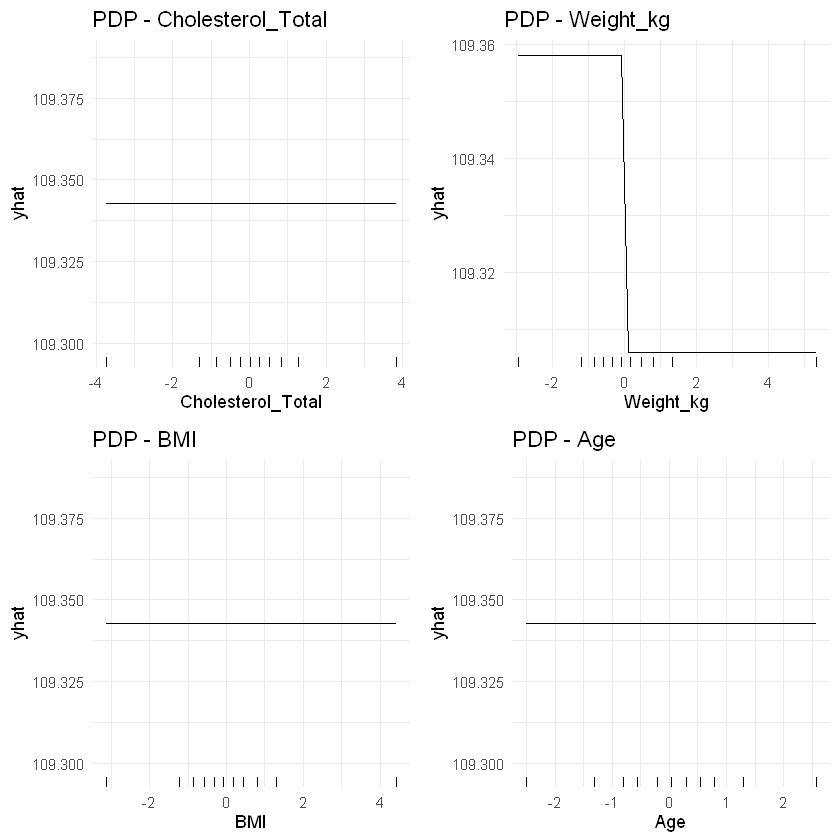

In [ ]:
library(pdp)

#meilleur modèle 
best_model <- rf_r_model

#4 variables les plus importantes
importance_rf <- rf_r_model$importance[, "%IncMSE"]
top_4_vars_idx <- order(importance_rf, decreasing = TRUE)[1:4]
top_4_vars <- names(importance_rf)[top_4_vars_idx]

cat("Variables les plus importantes (top 4):\n")
print(top_4_vars)
cat("\n")


data_pred_rf <- Xtest_r_sc


fig_pdp <- list()

for (i in seq_along(top_4_vars)) {
  var_name <- top_4_vars[i]
  
  # PDP pour chaque variable
  pdp_plot <- pdp::partial(
    best_model,
    pred.var = var_name,
    train = as.data.frame(Xtrain_r_sc),
    grid.resolution = 50,
    rug = TRUE,
    plot = TRUE,
    plot.engine = "ggplot2"
  ) + 
  ggplot2::ggtitle(paste("PDP -", var_name)) +
  ggplot2::theme_minimal()
  
  fig_pdp[[i]] <- pdp_plot
}


library(gridExtra)
gridExtra::grid.arrange(
  fig_pdp[[1]], fig_pdp[[2]], 
  fig_pdp[[3]], fig_pdp[[4]], 
  ncol = 2
)

## ICE plots

Les ICE plots montrent comment chaque prédiction individuelle change en fonction d'une variable, cela permet d'identifier les interactions et l'hétérogénéité.

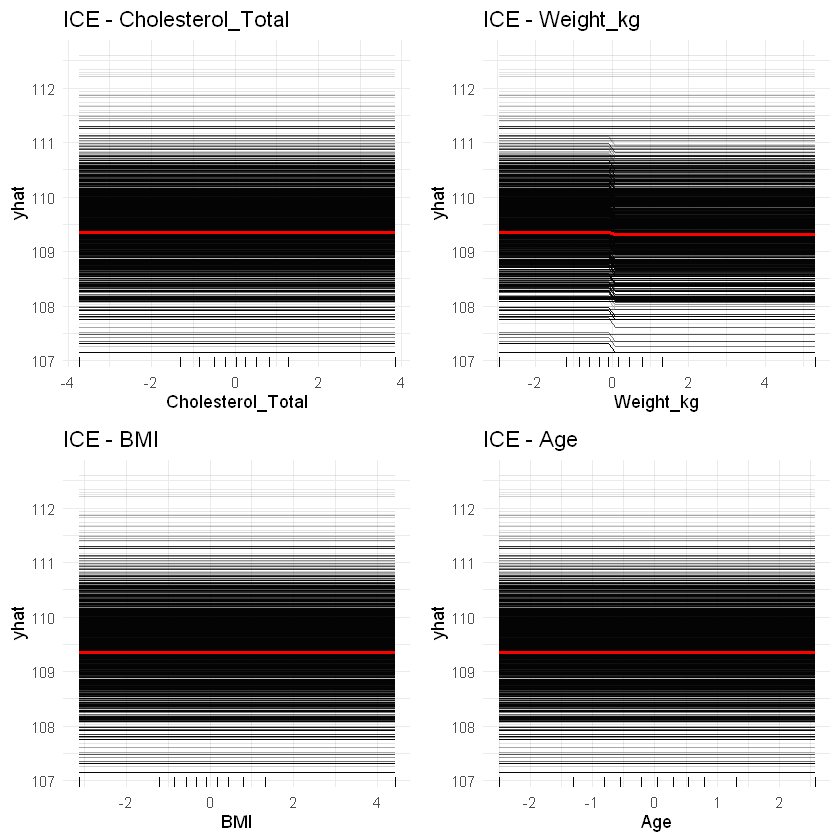

In [ ]:

fig_ice <- list()

for (i in seq_along(top_4_vars)) {
  var_name <- top_4_vars[i]
  
  
  ice_plot <- pdp::partial(
    best_model,
    pred.var = var_name,
    train = as.data.frame(Xtrain_r_sc),
    grid.resolution = 50,
    ice = TRUE,           
    rug = TRUE,
    plot = TRUE,
    plot.engine = "ggplot2",
    alpha = 0.1,          
    size = 0.5            
  ) + 
  ggplot2::ggtitle(paste("ICE -", var_name)) +
  ggplot2::theme_minimal()
  
  fig_ice[[i]] <- ice_plot
}


gridExtra::grid.arrange(
  fig_ice[[1]], fig_ice[[2]], 
  fig_ice[[3]], fig_ice[[4]], 
  ncol = 2
)

## Analyse numérique - Effet des variables clés

Étude de l'impact quantitatif des variables les plus importantes sur Cholesterol_LDL

In [ ]:



cat("ANALYSE DE L'EFFET DES VARIABLES CLÉS\n")


#chaque variable principale on obtient les prédictions moyennes
for (var_idx in 1:min(4, length(top_4_vars))) {
  var_name <- top_4_vars[var_idx]
  
  
  var_vals <- Xtrain_r_sc[, var_name]
  grid_vals <- seq(quantile(var_vals, 0.05), 
                   quantile(var_vals, 0.95), 
                   length.out = 10)
  
  
  # et les autres variables à leur médiane
  pred_matrix <- Xtrain_r_sc[rep(1, length(grid_vals)), ]
  pred_matrix[, var_name] <- grid_vals
  
  
  predictions <- predict(best_model, as.data.frame(pred_matrix))
  
  
  results_df <- data.frame(
    Variable_Value = round(grid_vals, 3),
    Predicted_Cholesterol_LDL = round(predictions, 2)
  )
  
  cat("\nVariable :", var_name, "\n")
  cat("(Autres variables fixées à leur médiane)\n")
  print(results_df, row.names = FALSE)
  
  # Calculer et afficher la plage de prédictions
  pred_range <- range(predictions)
  cat("Plage de prédictions: [", round(pred_range[1], 2), ", ", 
      round(pred_range[2], 2), "]\n", sep = "")
  cat("Variation totale: ", round(pred_range[2] - pred_range[1], 2), "\n\n", sep = "")
}



ANALYSE DE L'EFFET DES VARIABLES CLÉS



Variable : Cholesterol_Total 
(Autres variables fixées à leur médiane)
 Variable_Value Predicted_Cholesterol_LDL
         -1.651                    108.35
         -1.282                    108.35
         -0.913                    108.35
         -0.544                    108.35
         -0.175                    108.35
          0.194                    108.35
          0.563                    108.35
          0.932                    108.35
          1.301                    108.35
          1.670                    108.35
Plage de prédictions: [108.35, 108.35]
Variation totale: 0


Variable : Weight_kg 
(Autres variables fixées à leur médiane)
 Variable_Value Predicted_Cholesterol_LDL
         -1.464                    108.35
         -1.105                    108.35
         -0.747                    108.35
         -0.388                    108.35
         -0.030                    108.35
          0.329                    108.18
          0.688                    108.18
      